In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os


bigtable_path = "../rsidis_bigtable_pass0.csv"

fit_files = {
    "H.cer": "H.cer.npeSum_fit_results_all.csv",
    "P.hgcer": "P.hgcer.npeSum_fit_results_all.csv",
    "P.aero": "P.aero.npeSum_fit_results_all.csv",
}

target_colors = {
    "LH2": cm.get_cmap("tab20")(0),
    "LD2": cm.get_cmap("tab20")(2),
    "Dummy": cm.get_cmap("tab20")(4),
    "C": cm.get_cmap("tab20")(6),
    "Cu": cm.get_cmap("tab20")(8),
}

output_dir = "fit_plots"
os.makedirs(output_dir, exist_ok=True)

bigtable = pd.read_csv(bigtable_path)
bigtable["run"] = bigtable["run"].astype(int)

fit_data = {}
for name, path in fit_files.items():
    df = pd.read_csv(path)
    df["run"] = df["run"].astype(int)

    # Compute mean_err if needed
    df["mean_err"] = (df["std_dev"] / np.sqrt(df.get("nevents", len(df))))
    df["mean_err"] = df["mean_err"].clip(lower=0).fillna(0)
    # Compute chi2/ndf safely
    if "chi2" in df.columns and "ndf" in df.columns:
        df["chi2_ndf"] = df["chi2"] / df["ndf"]
    else:
        print(f"WARNING: {name} file has no chi2 or ndf column — all runs will be classified as BAD.")
        df["chi2_ndf"] = np.inf  # forces classification as bad

    fit_data[name] = df



/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_1008/1059042113.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "LH2": cm.get_cmap("tab20")(0),
/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_1008/1059042113.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "LD2": cm.get_cmap("tab20")(2),
/var/folders/j6/9gzqgwz92nzg7mgfgbs2rxjm0000gn/T/ipykernel_1008/1059042113.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "Dummy": cm.get_cm

## 4-pass:

### $\pi^-$ Setting 1:

H.cer Weighted Mean = 9.183 ± 0.726
P.hgcer Weighted Mean = 7.427 ± 1.337
P.aero Weighted Mean = 5.993 ± 2.148


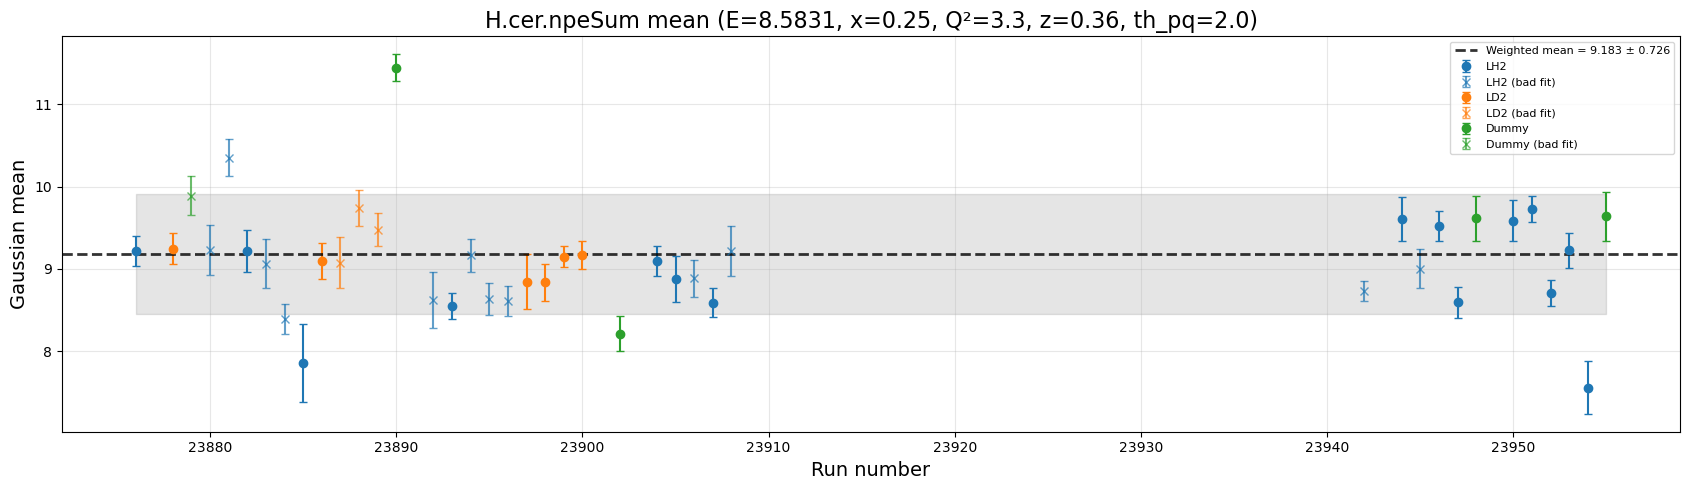

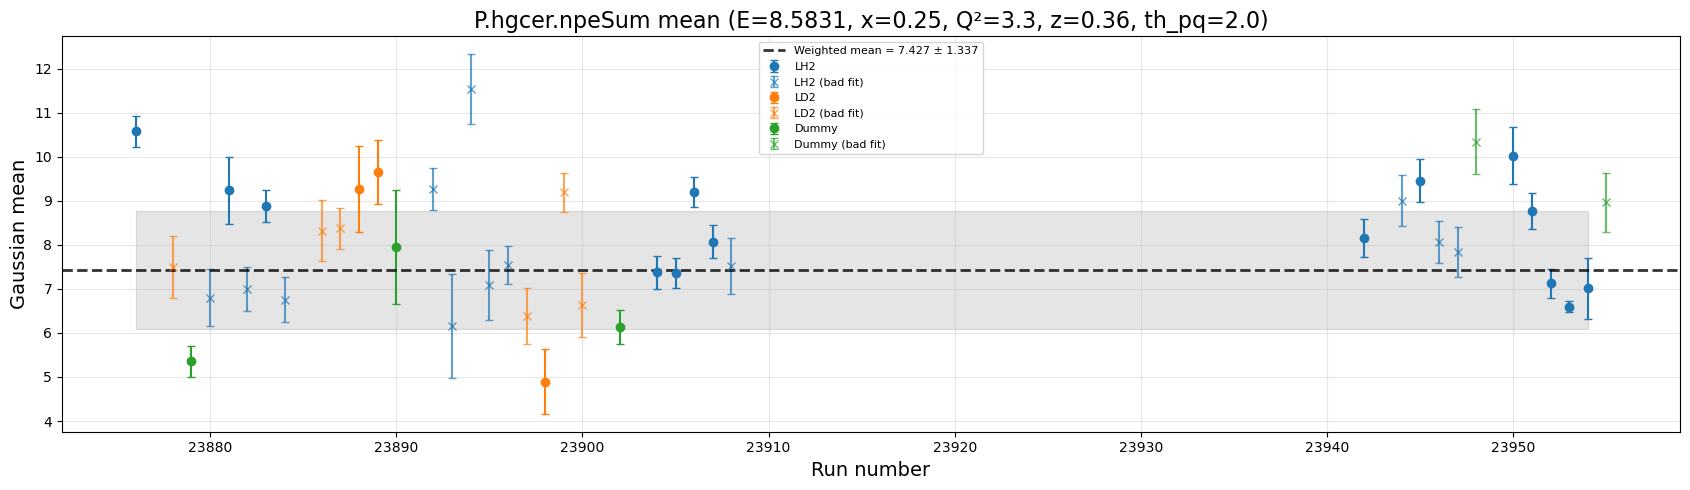

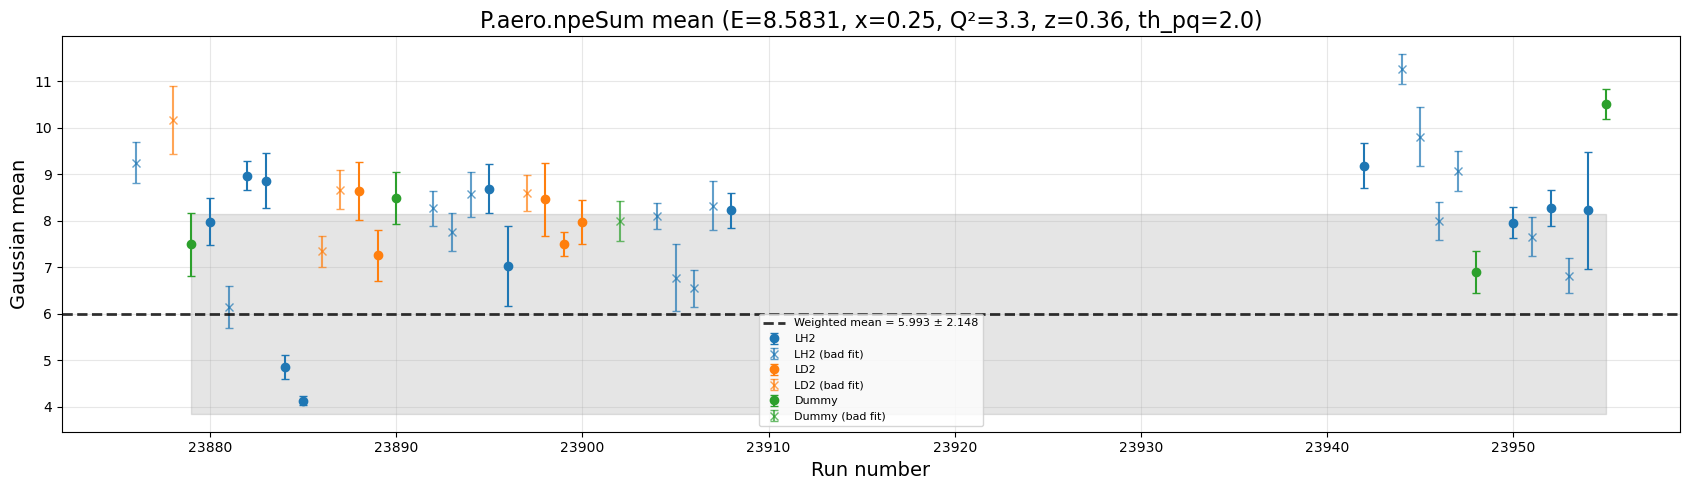

In [2]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.36
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 2:

H.cer Weighted Mean = 8.874 ± 0.162
P.hgcer Weighted Mean = 13.087 ± 0.957
P.aero Weighted Mean = 8.262 ± 0.361


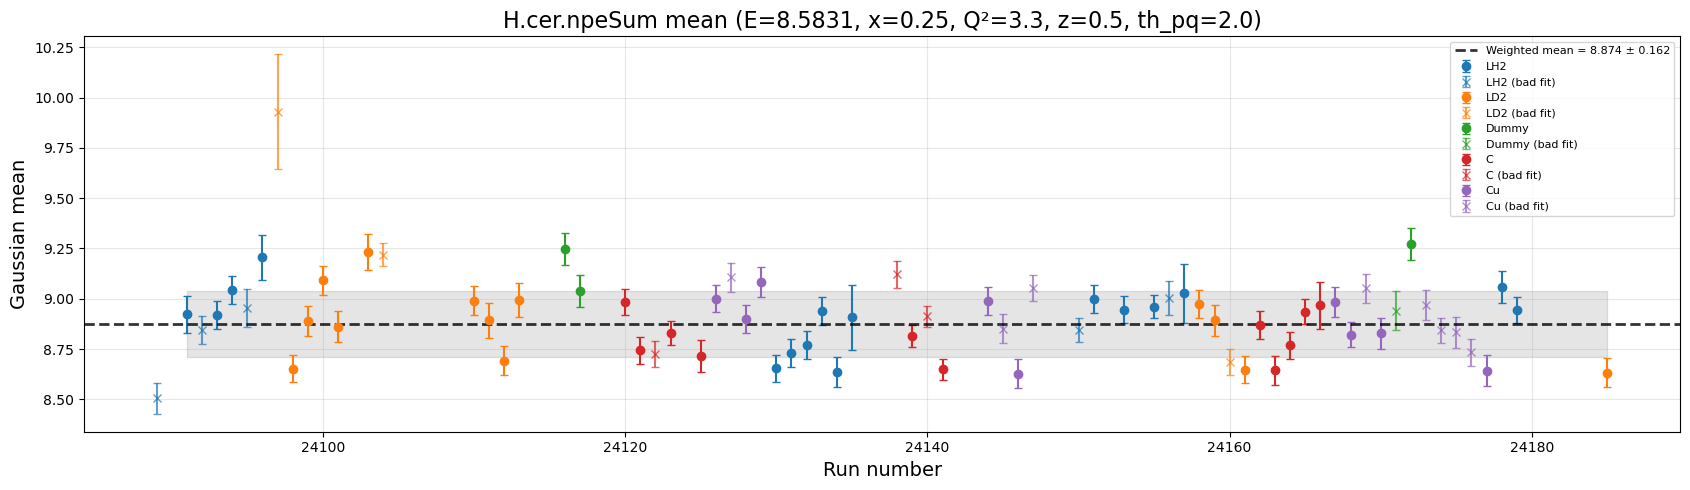

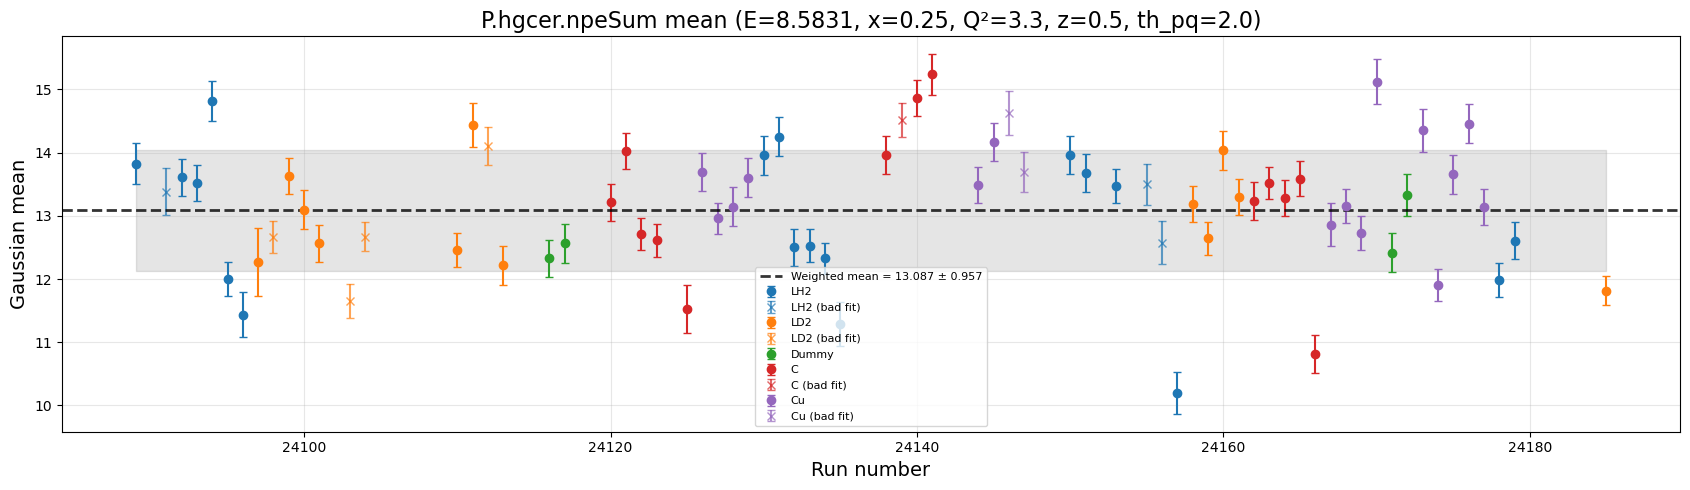

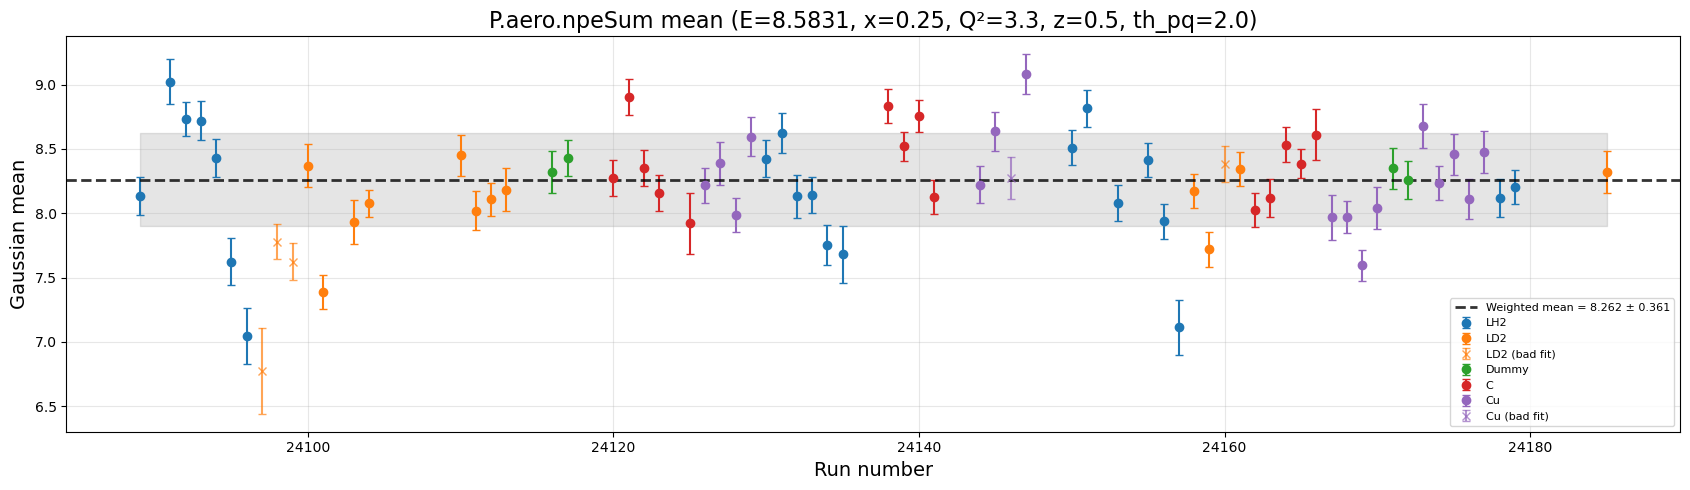

In [3]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 2.0
run_type = "PI-SIDIS"


mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 3

H.cer Weighted Mean = 8.899 ± 0.167
P.hgcer Weighted Mean = 23.077 ± 1.717
P.aero Weighted Mean = 8.811 ± 0.388


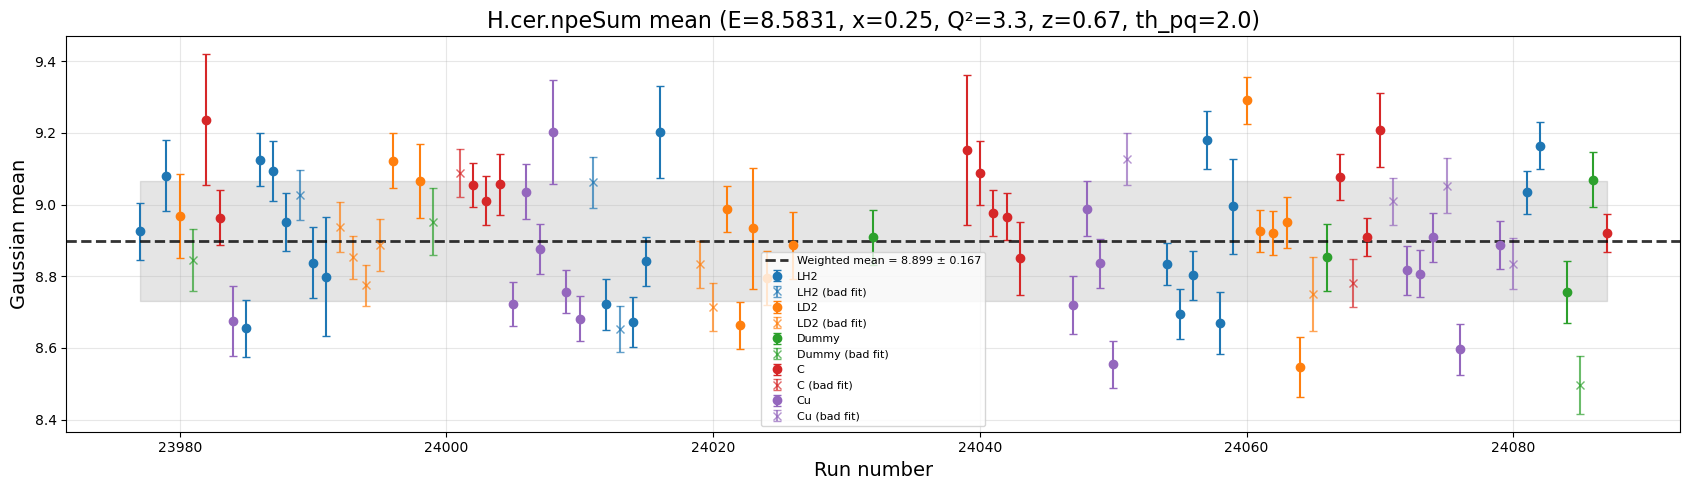

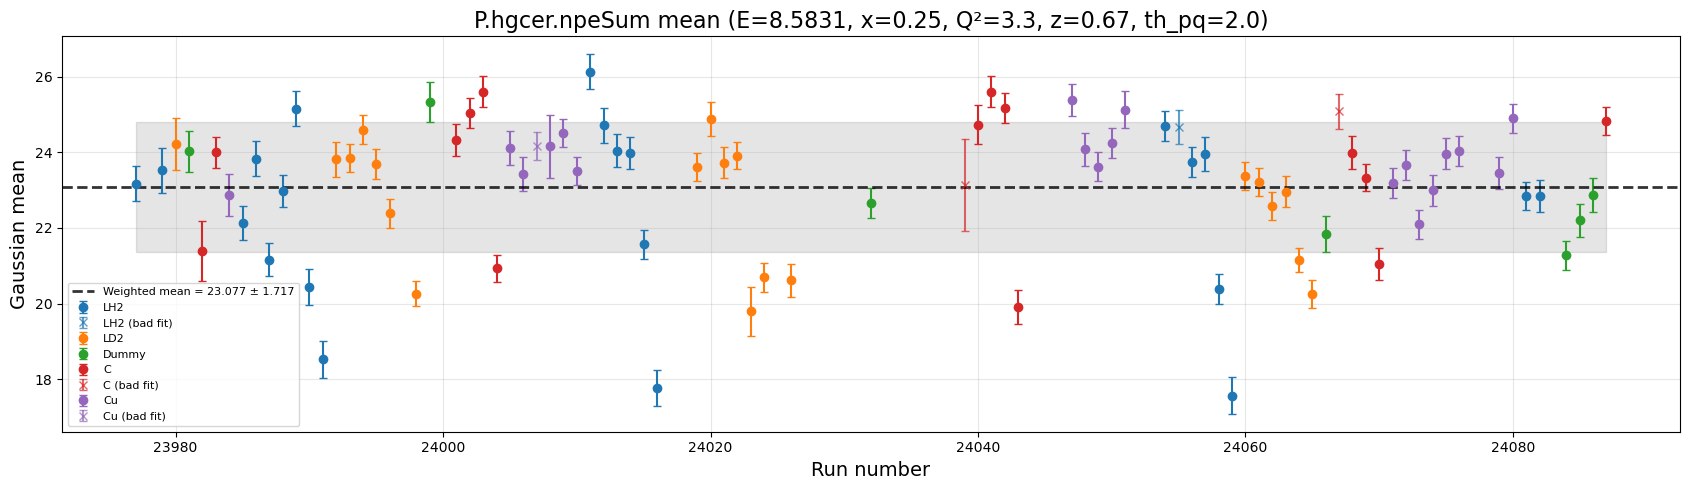

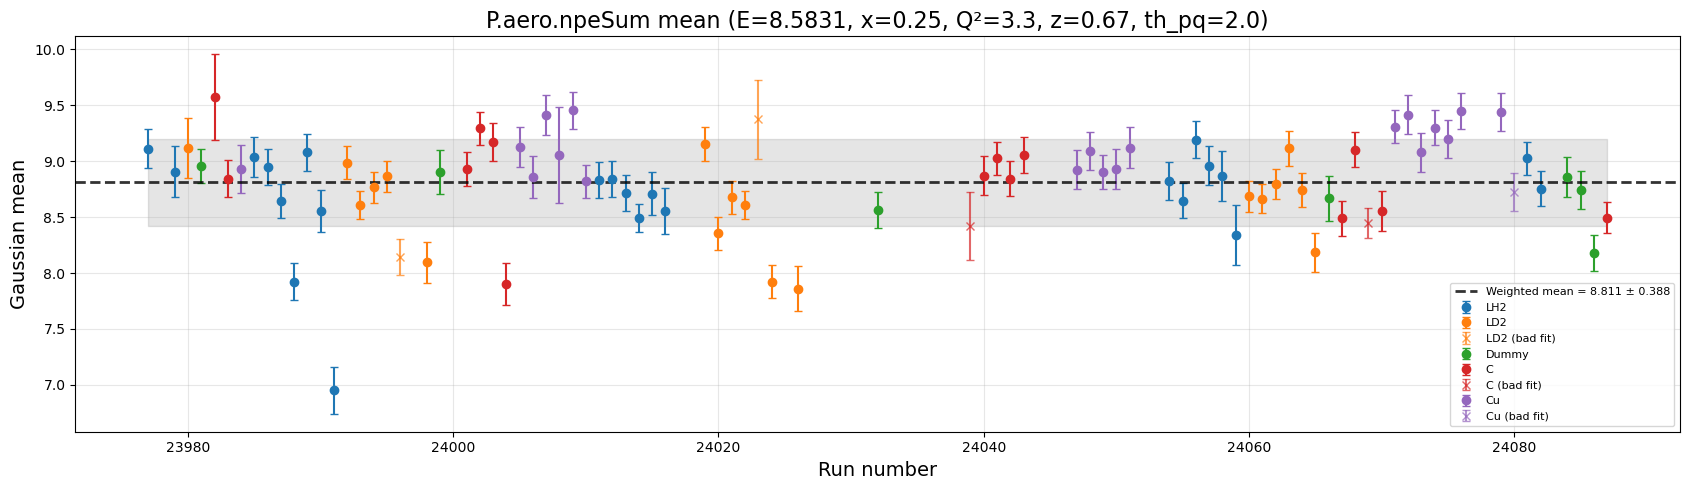

In [4]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.67
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 4:

H.cer Weighted Mean = 8.863 ± 0.239
P.hgcer Weighted Mean = 28.252 ± 1.737
P.aero Weighted Mean = 9.348 ± 0.302


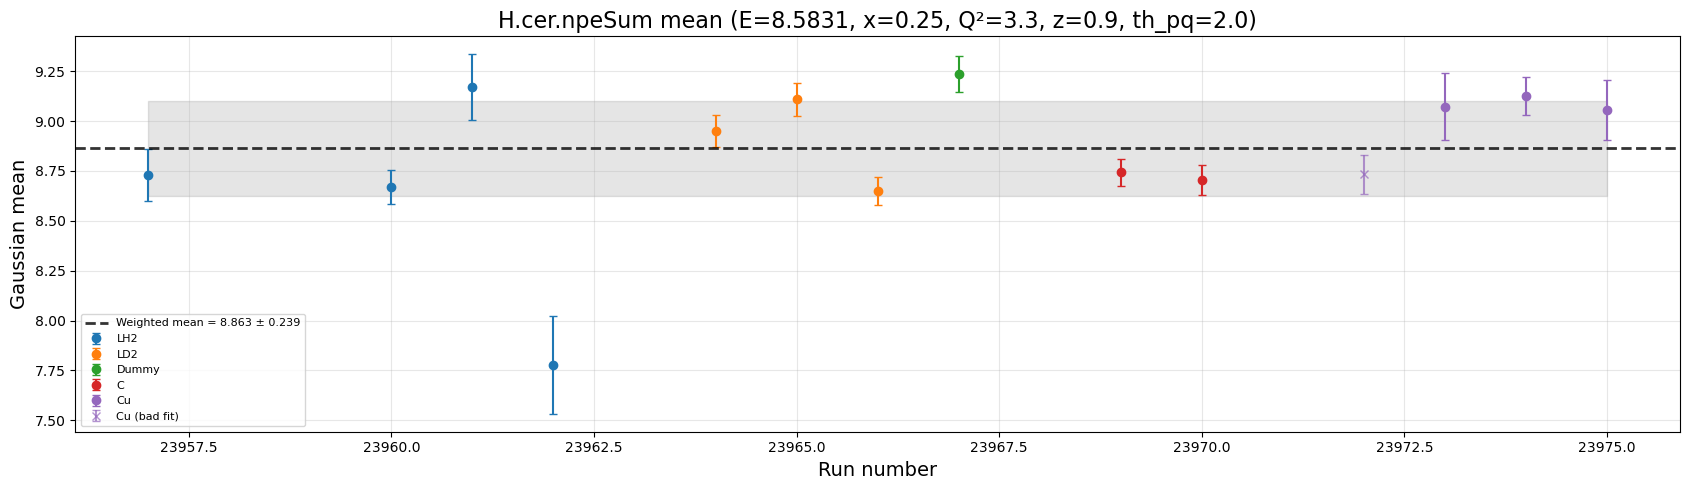

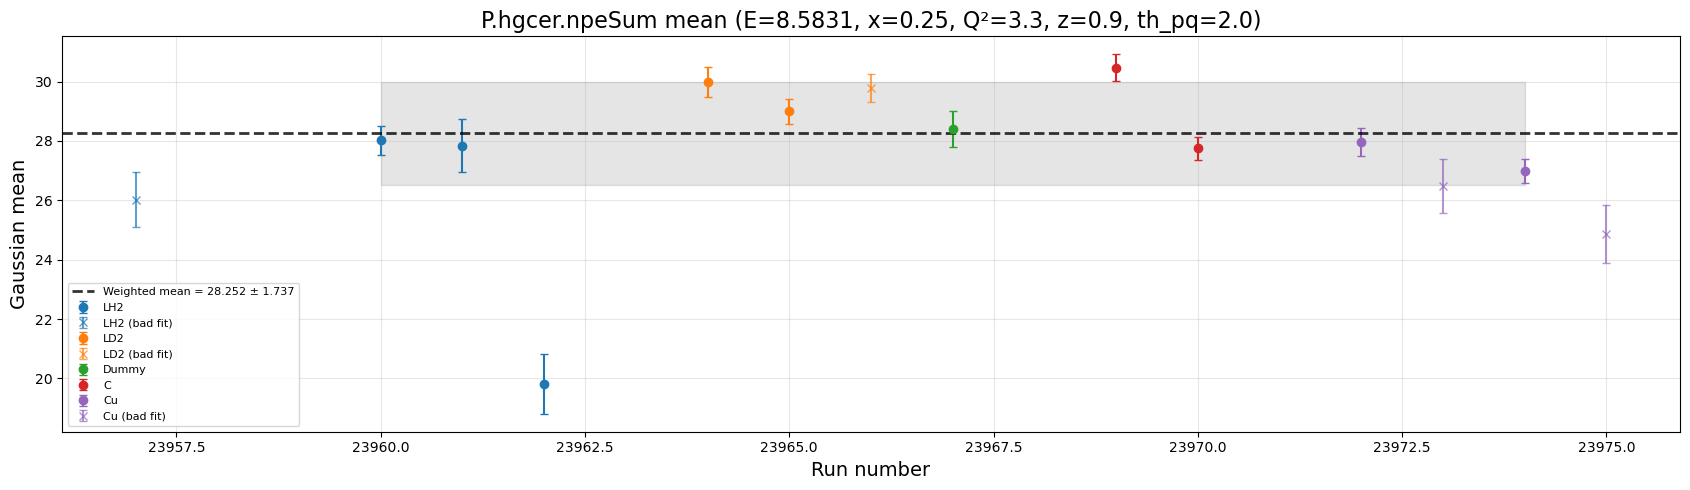

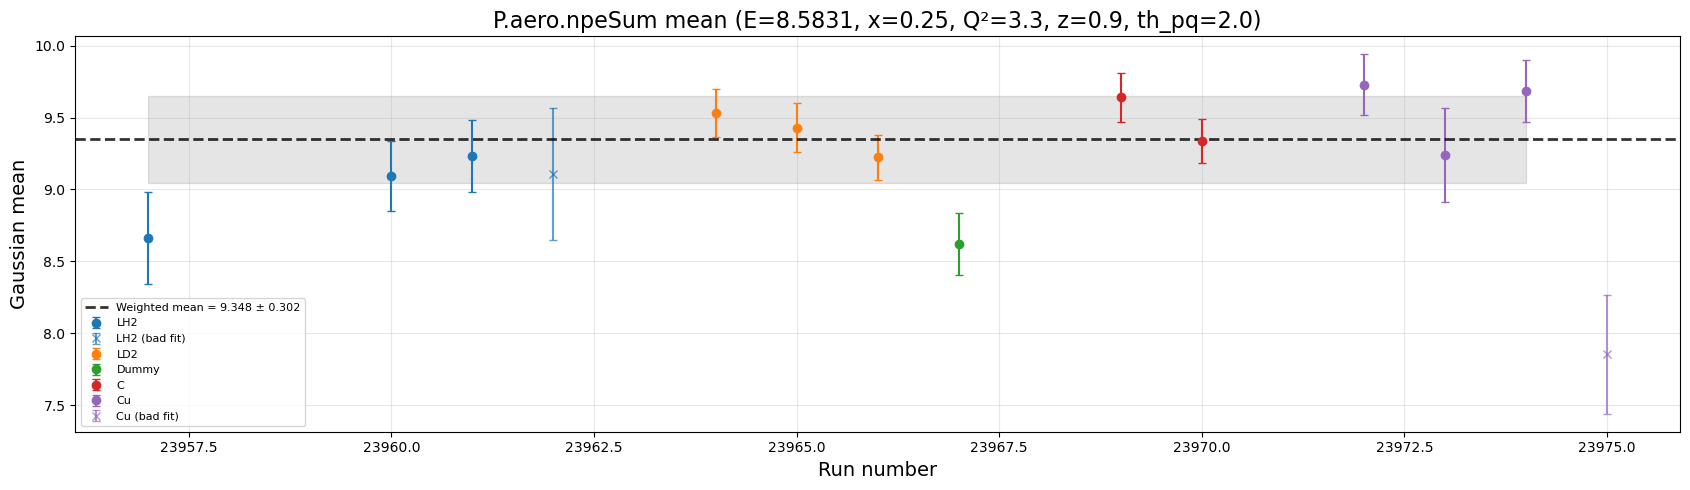

In [5]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.9
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 5:

H.cer Weighted Mean = 8.931 ± 0.145
P.hgcer Weighted Mean = 10.081 ± 0.537
P.aero Weighted Mean = 7.718 ± 0.291


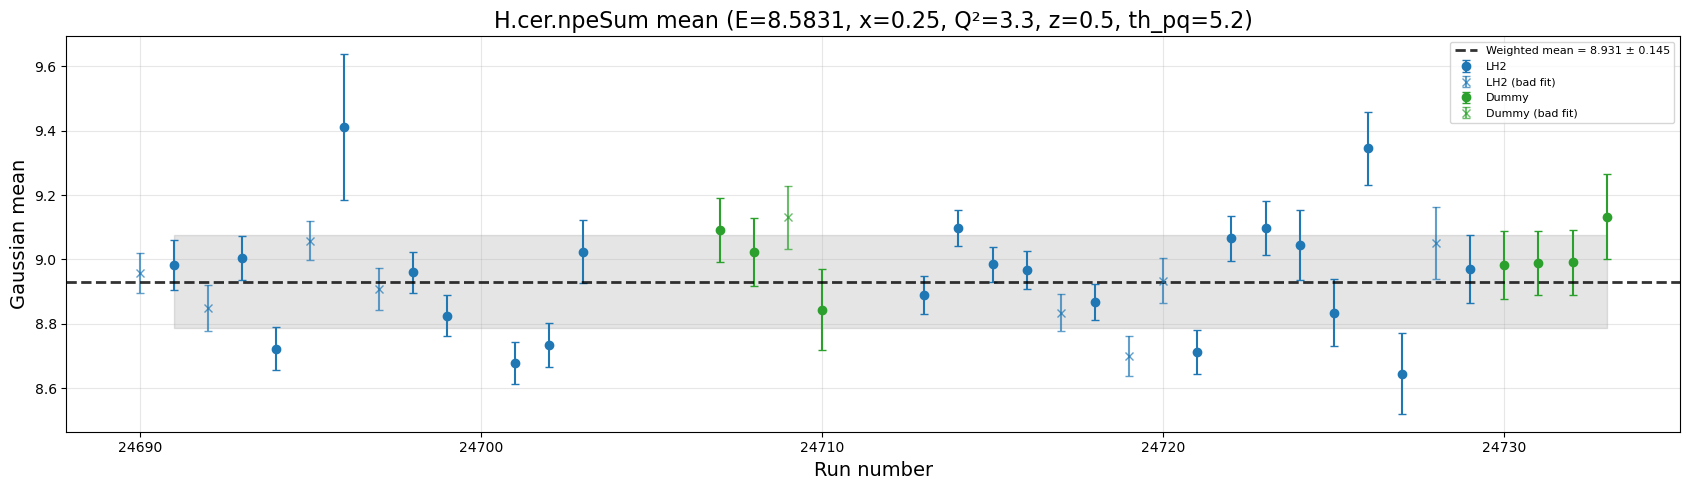

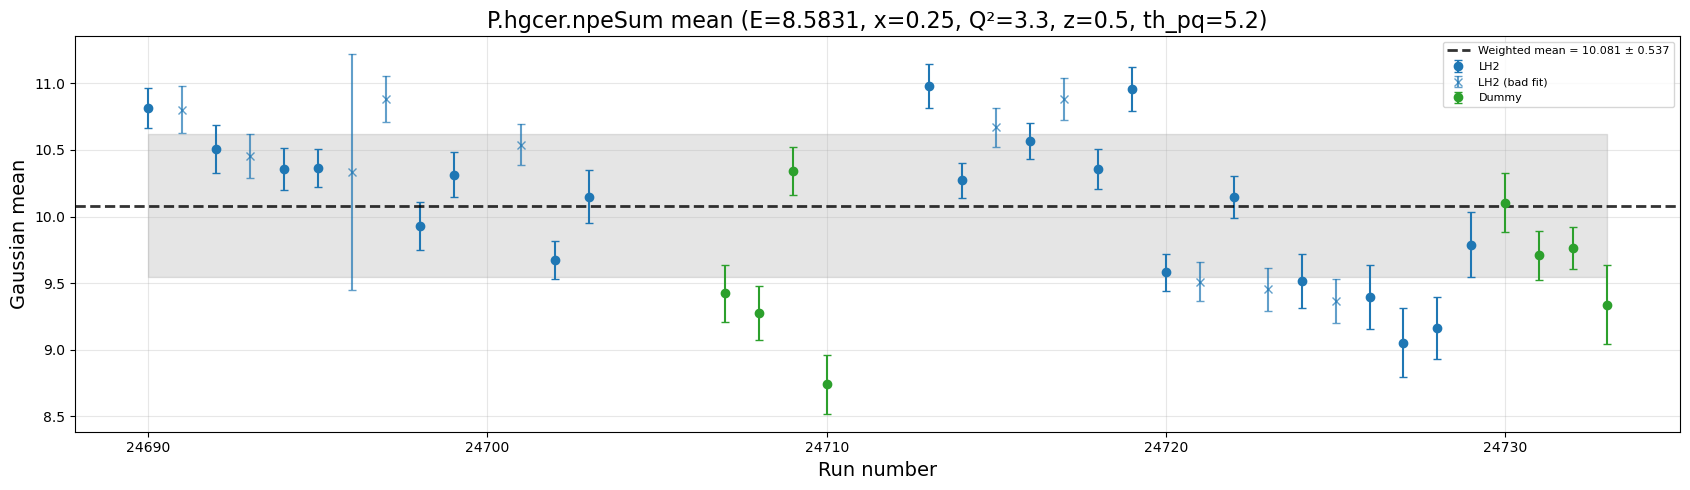

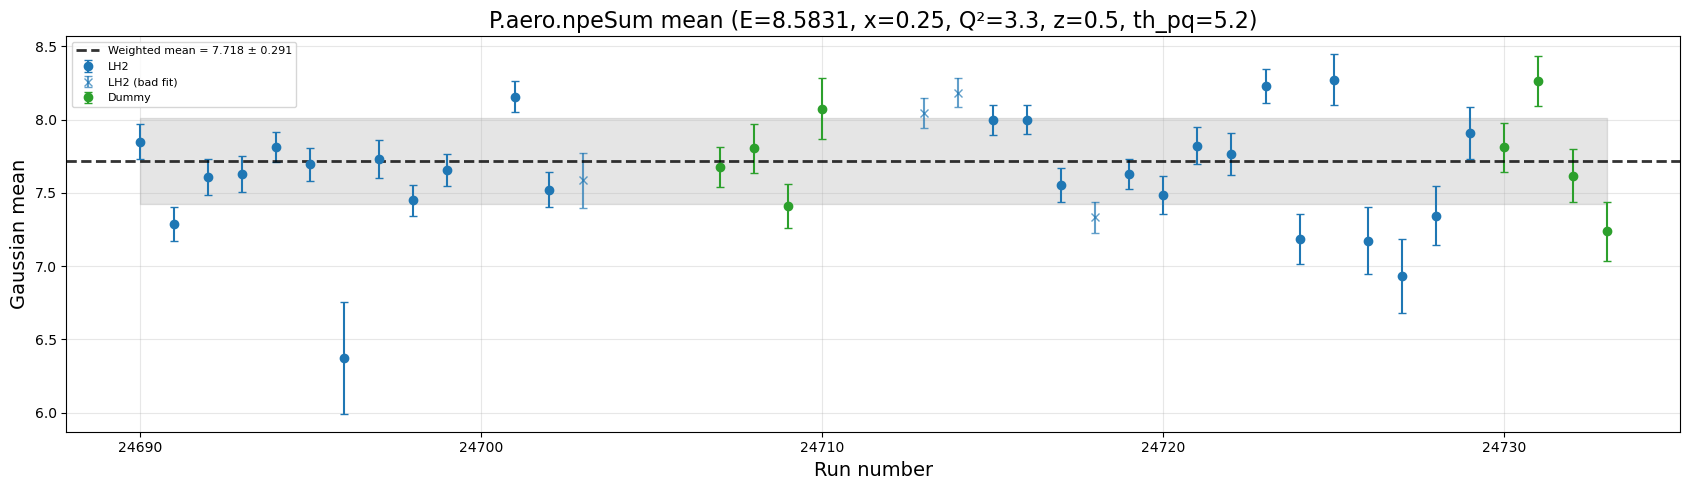

In [6]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 5.2
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["run"] > 23869)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 6

H.cer Weighted Mean = 8.973 ± 0.225
P.hgcer Weighted Mean = 9.509 ± 0.485
P.aero Weighted Mean = 7.524 ± 0.319


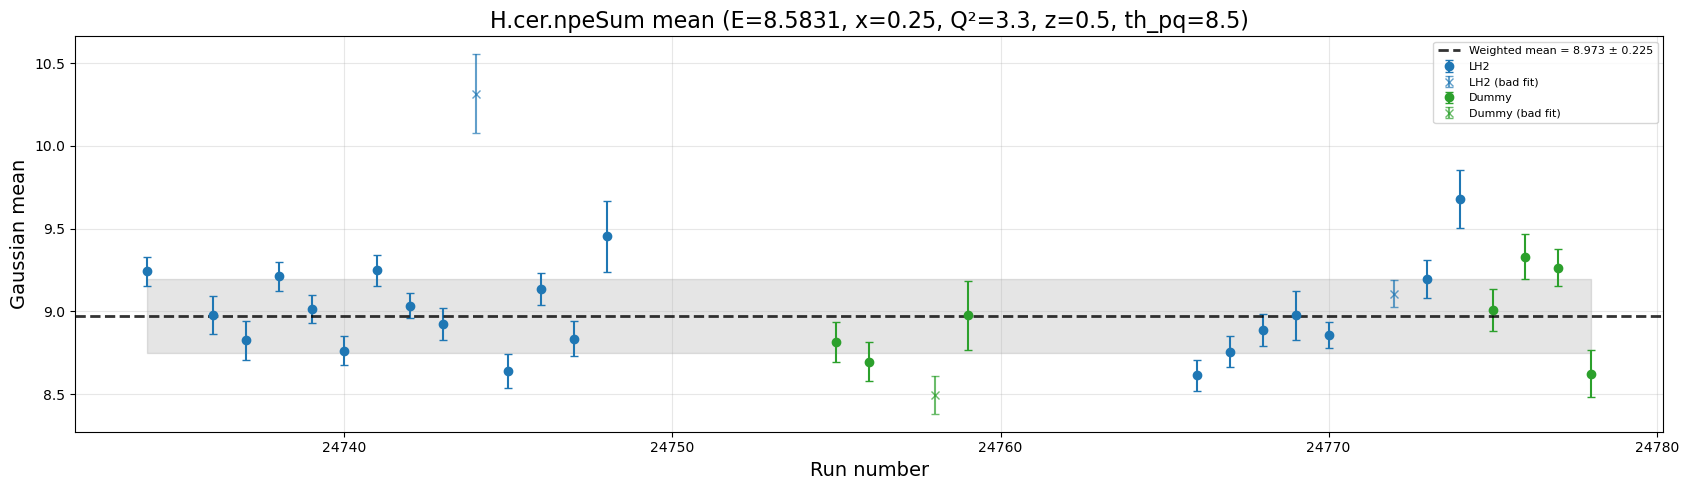

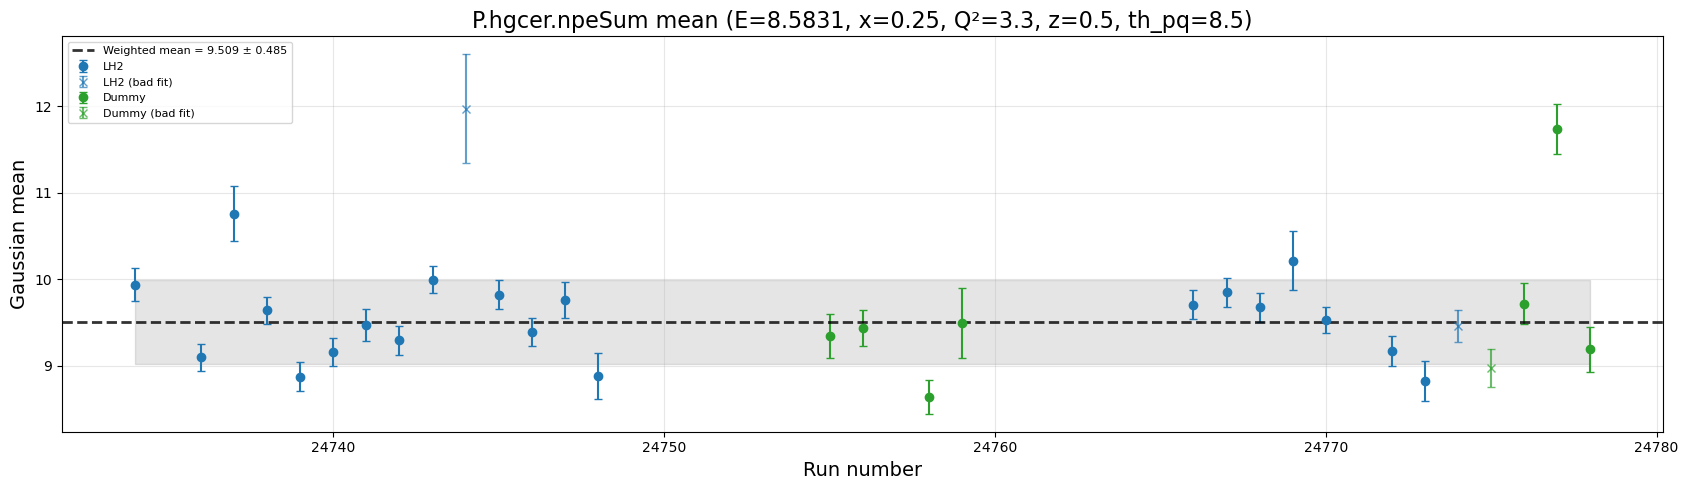

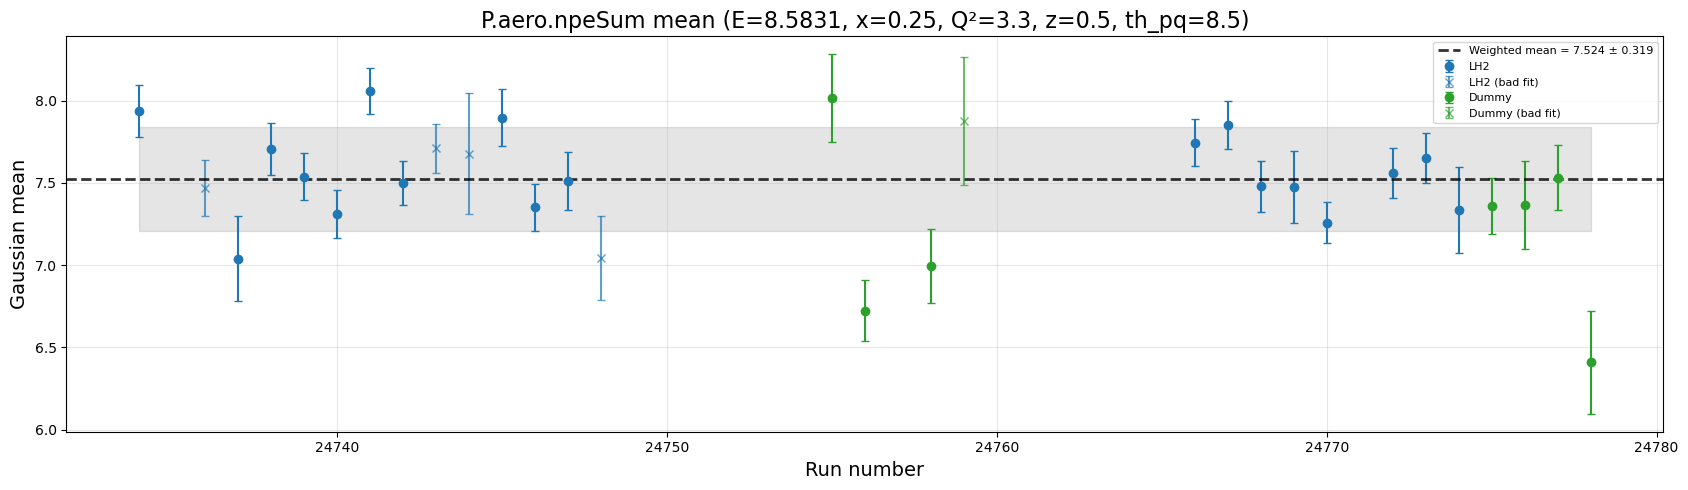

In [7]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 8.5
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### $\pi^+$ Setting 1:

H.cer Weighted Mean = 8.932 ± 0.413
P.hgcer Weighted Mean = 6.624 ± 0.635
P.aero Weighted Mean = 7.071 ± 0.877


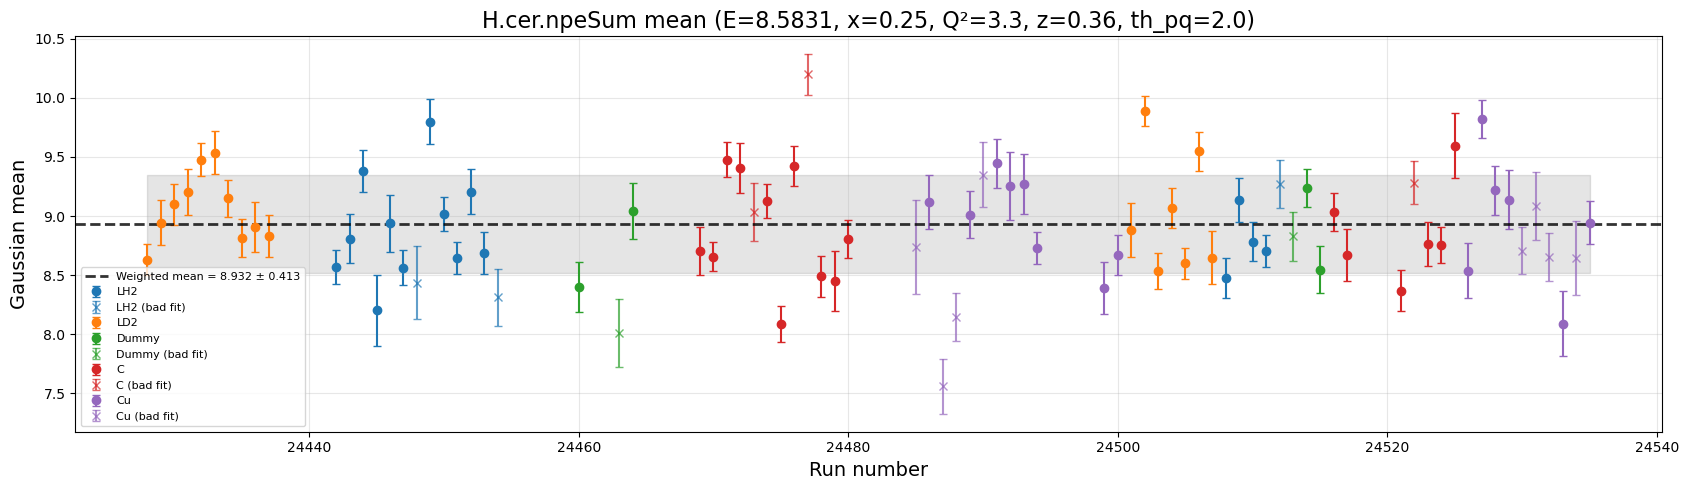

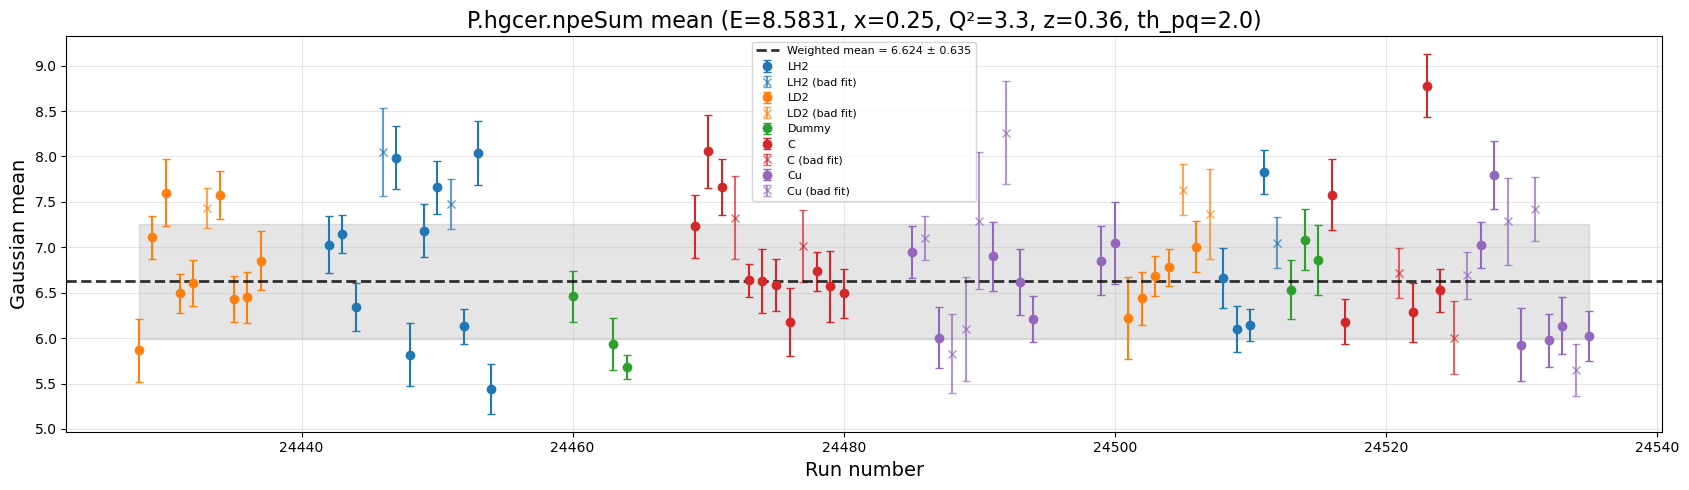

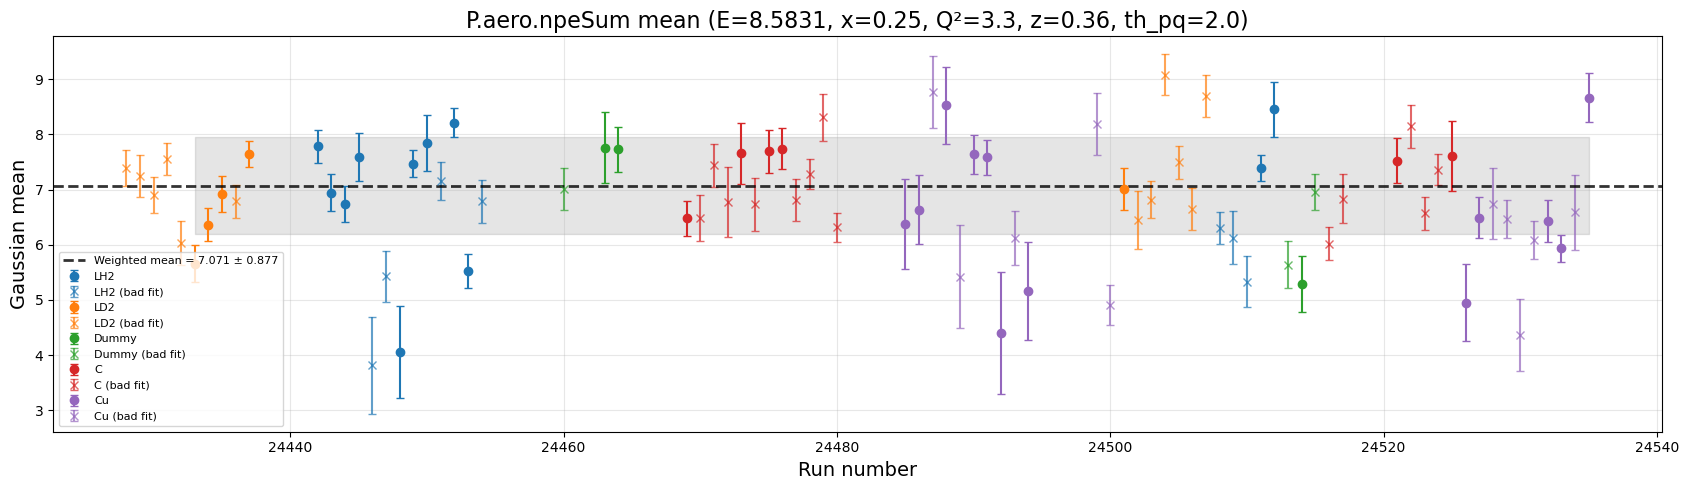

In [8]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.36
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 2:

H.cer Weighted Mean = 8.887 ± 0.170
P.hgcer Weighted Mean = 10.170 ± 0.368
P.aero Weighted Mean = 7.095 ± 0.276


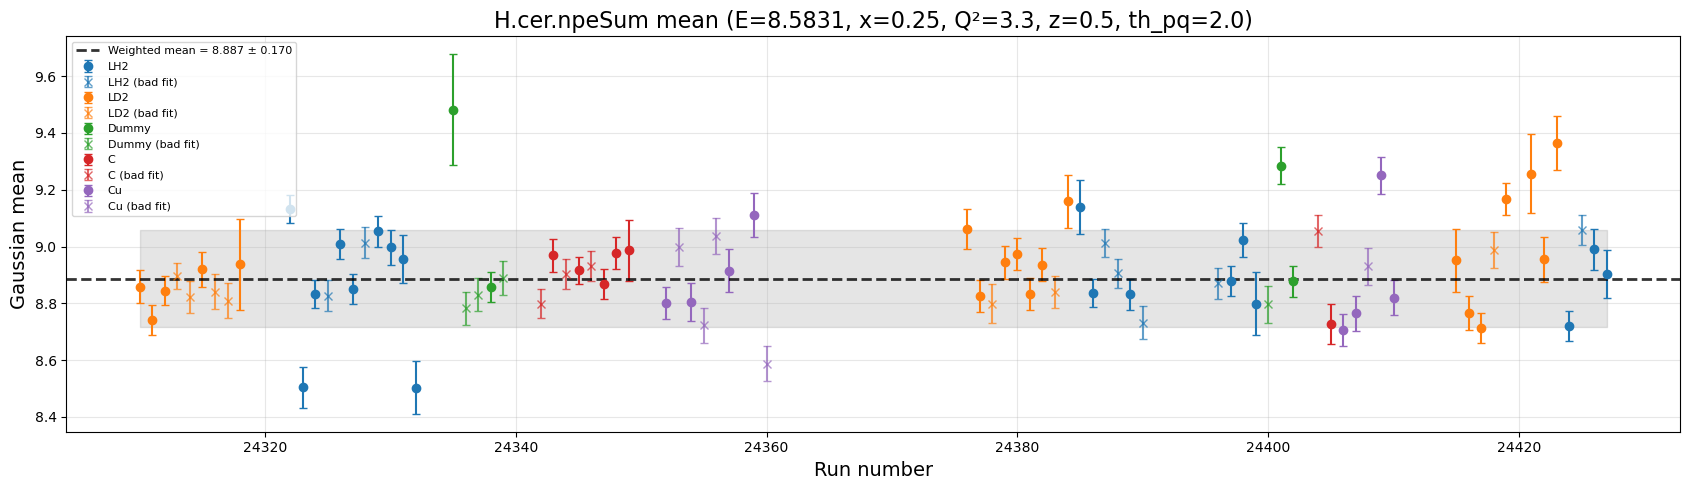

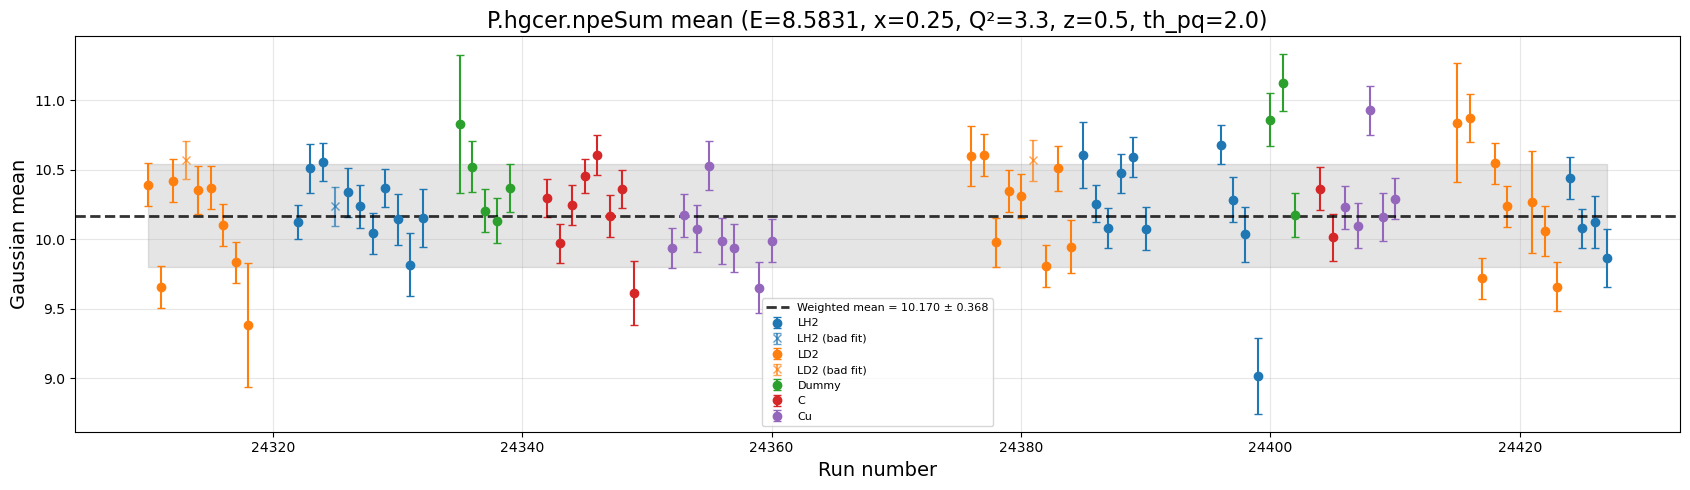

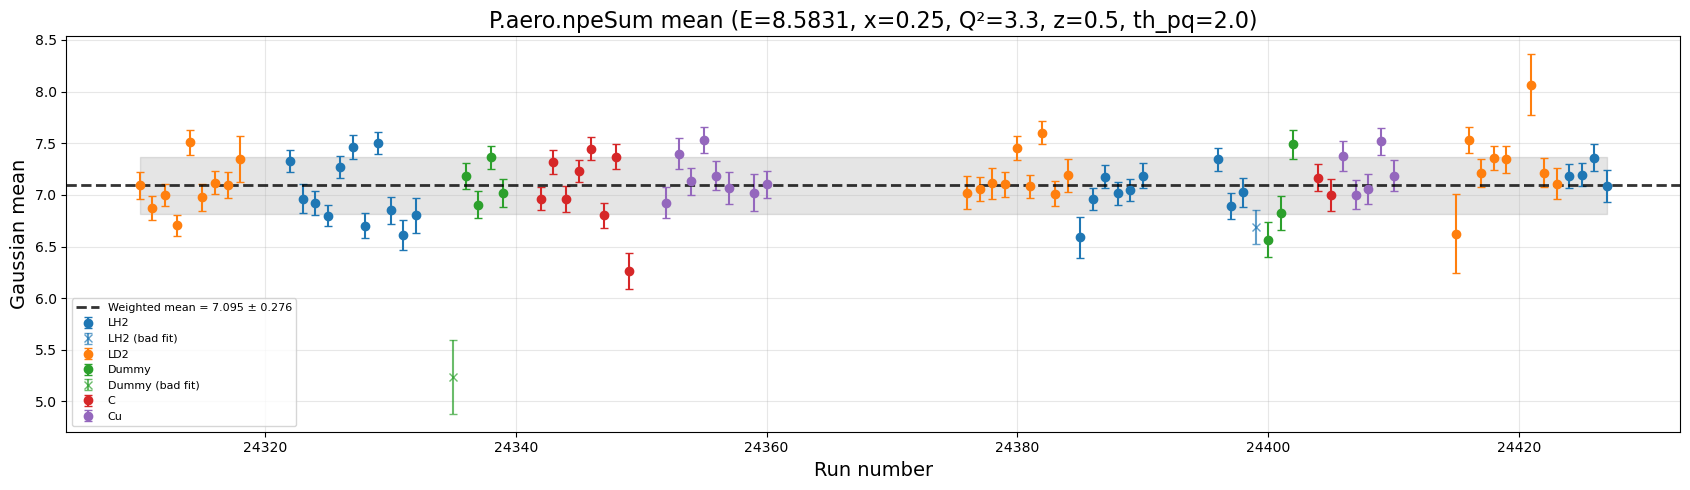

In [9]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 3:

H.cer Weighted Mean = 8.884 ± 0.119
P.hgcer Weighted Mean = 15.919 ± 0.540
P.aero Weighted Mean = 6.979 ± 0.408


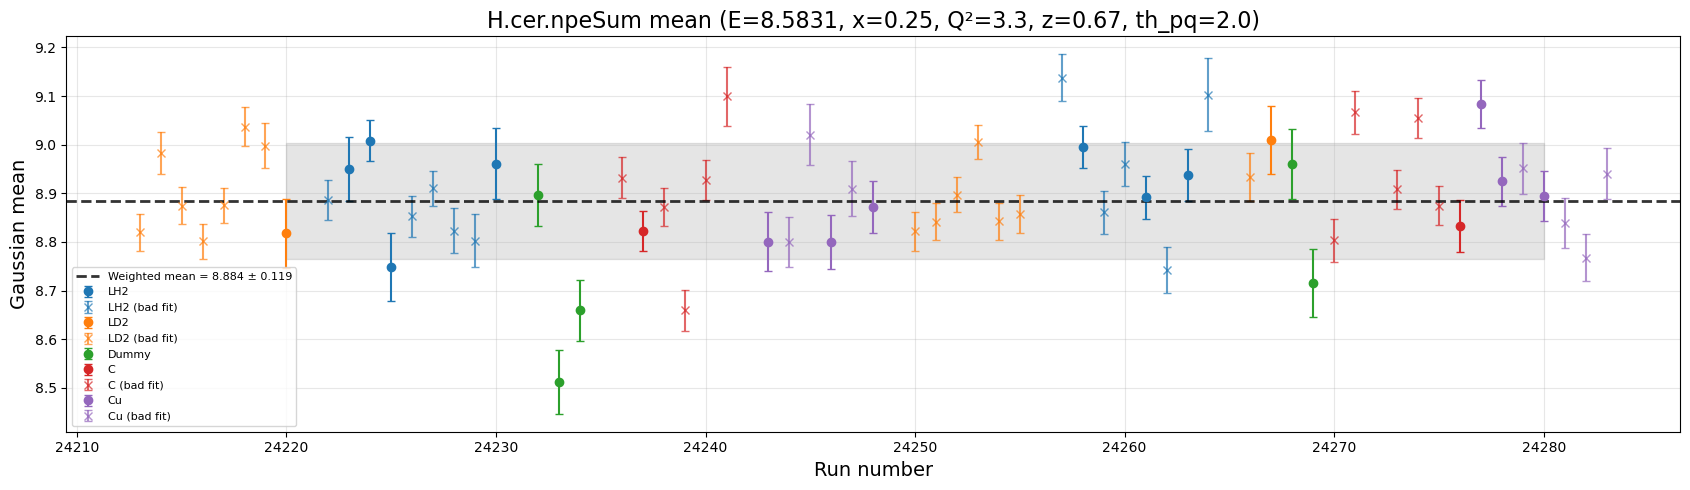

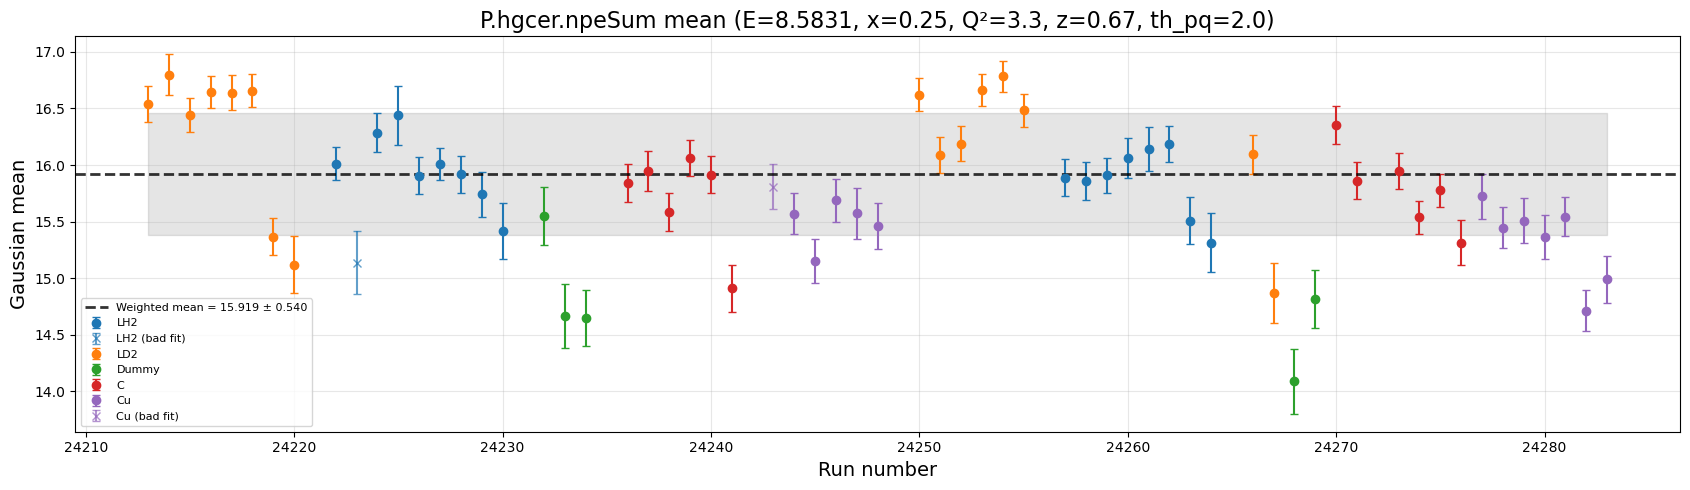

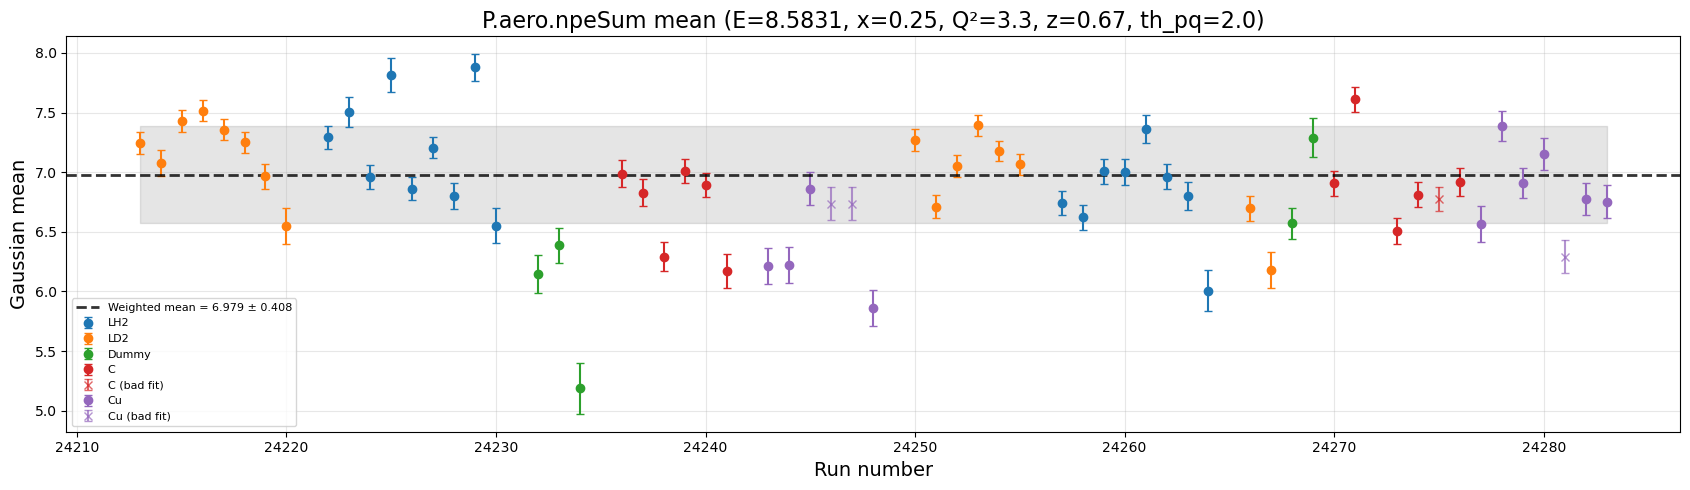

In [10]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.67
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 4:

H.cer Weighted Mean = 8.949 ± 0.173
P.hgcer Weighted Mean = 17.137 ± 0.424
P.aero Weighted Mean = 7.658 ± 0.321


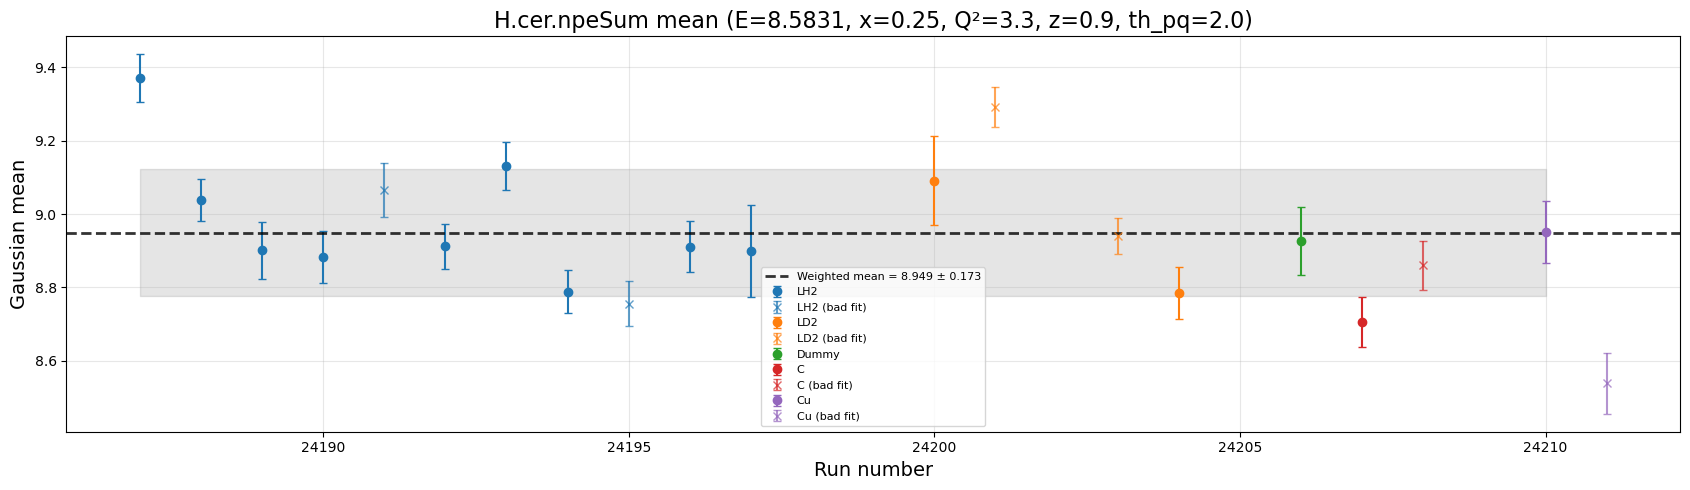

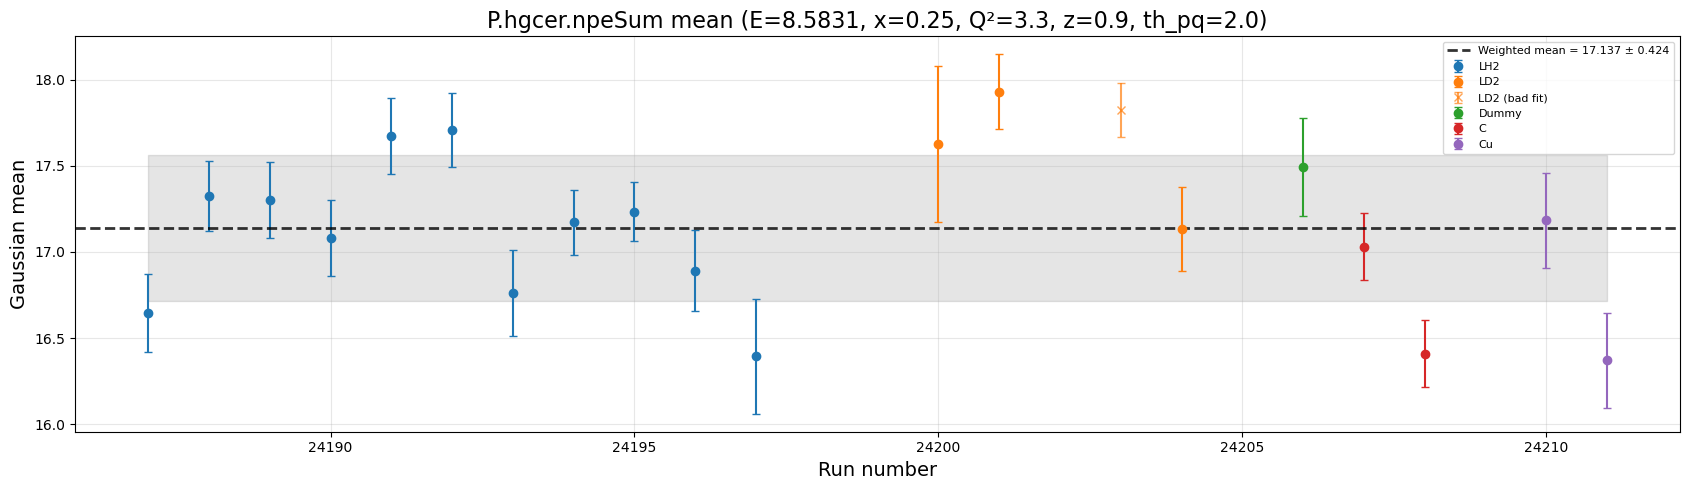

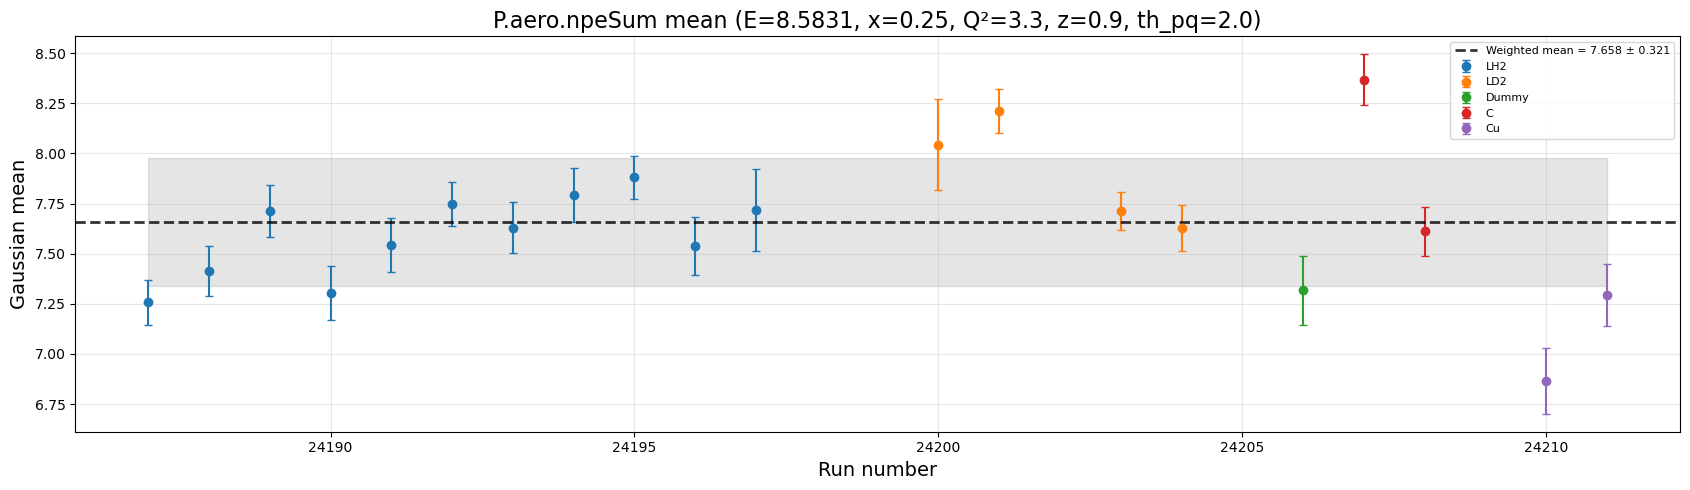

In [11]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.9
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 5:

H.cer Weighted Mean = 8.899 ± 0.171
P.hgcer Weighted Mean = 9.653 ± 0.269
P.aero Weighted Mean = 6.904 ± 0.278


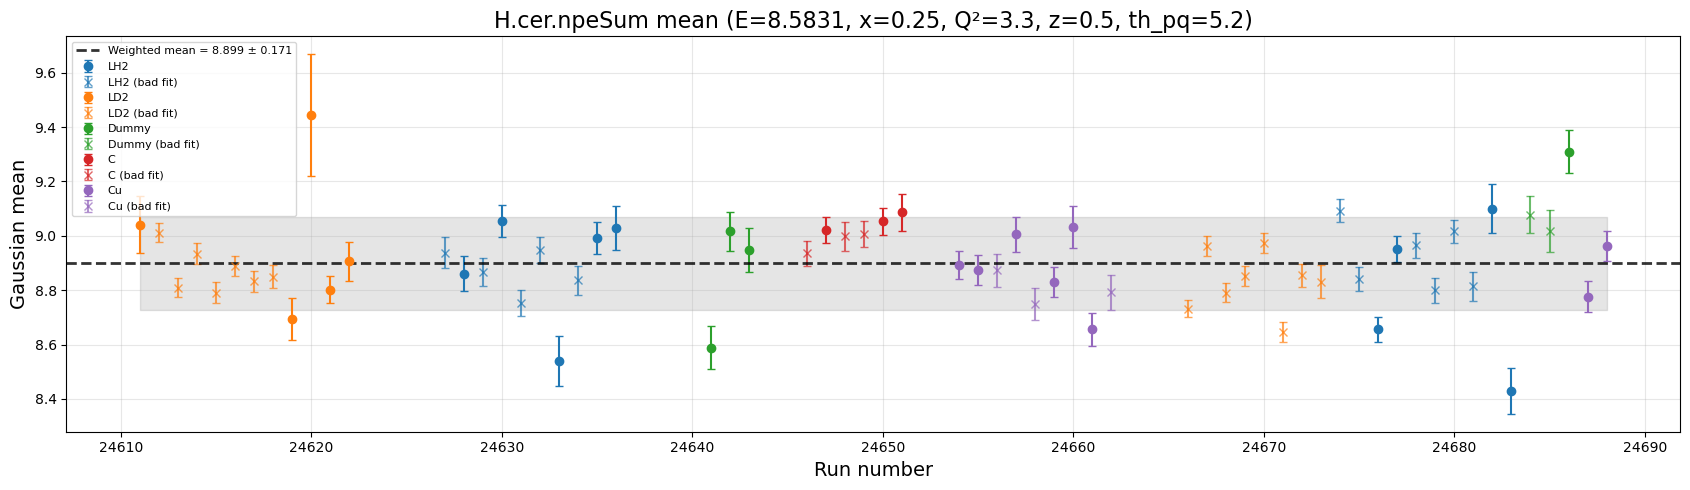

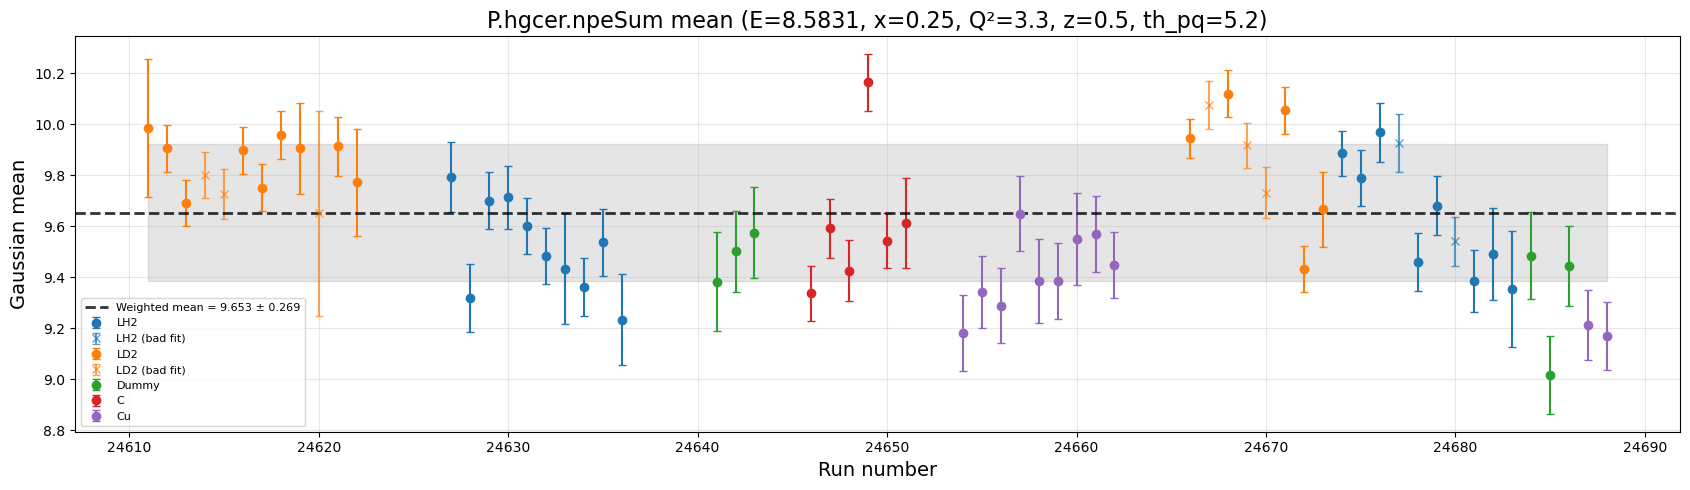

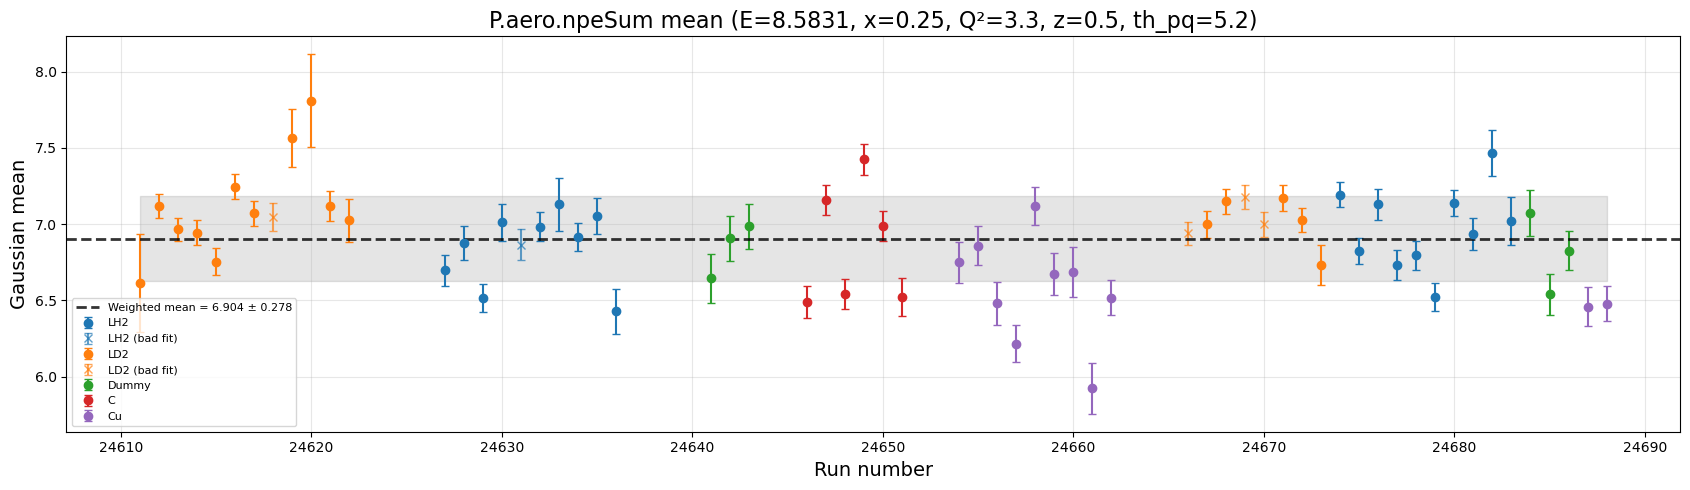

In [12]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 5.2
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 6:

H.cer Weighted Mean = 8.587 ± 0.683
P.hgcer Weighted Mean = 8.893 ± 0.349
P.aero Weighted Mean = 6.447 ± 0.287


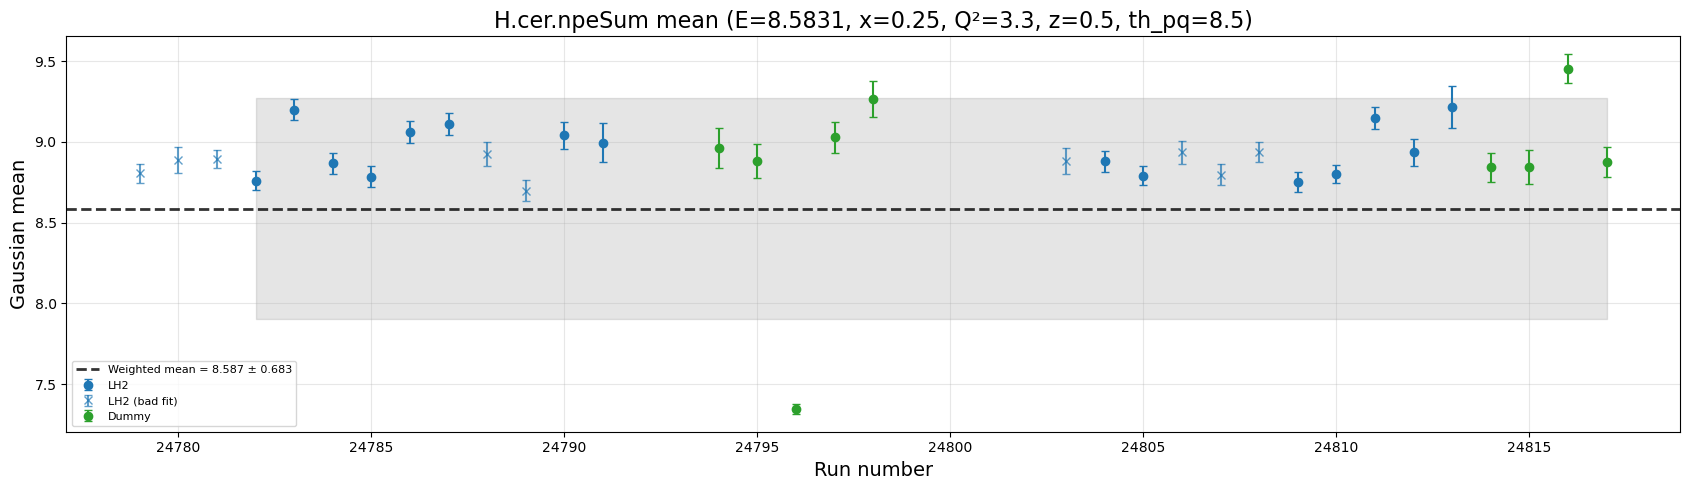

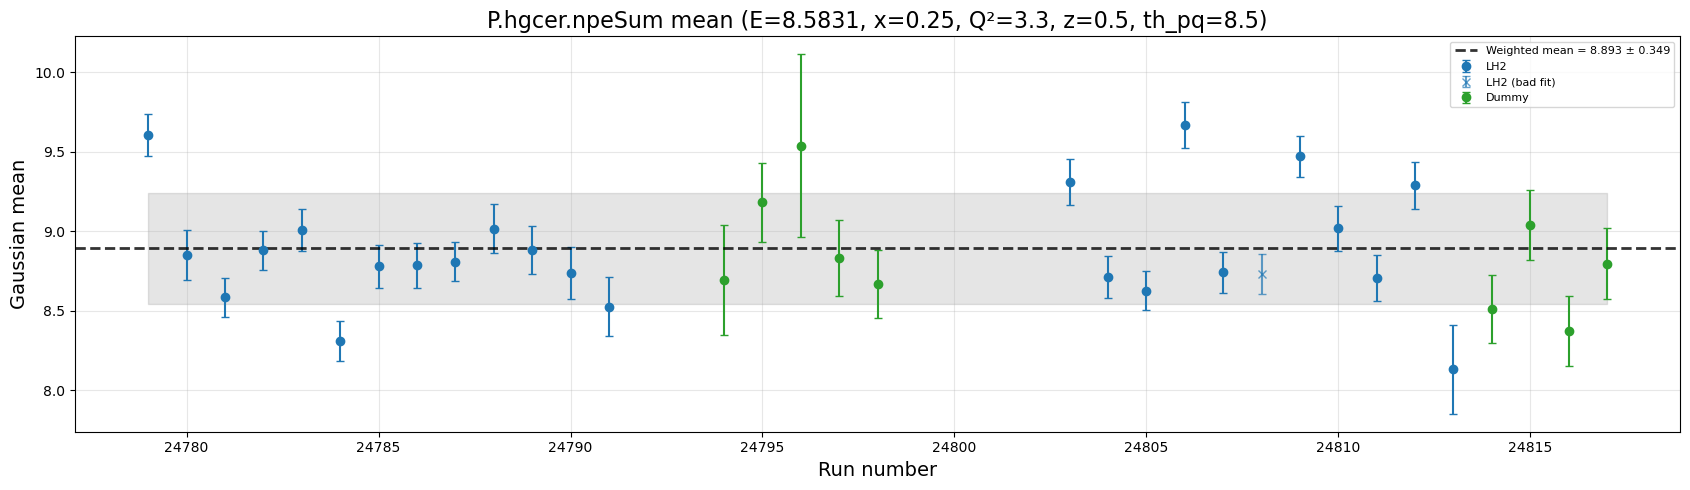

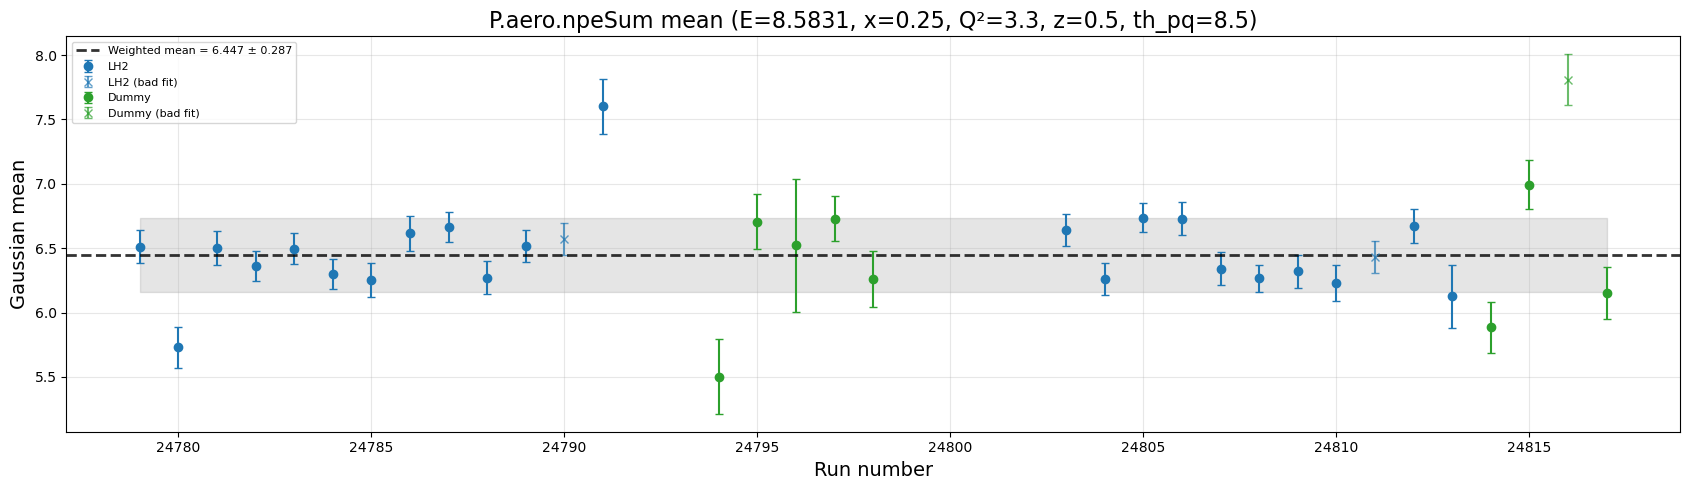

In [13]:
ebeam = 8.5831
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 8.5
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



## 5-pass:

### $\pi^-$: Setting 1

H.cer Weighted Mean = 9.115 ± 0.000
P.hgcer Weighted Mean = 10.044 ± 0.180
P.aero Weighted Mean = 7.509 ± 0.170


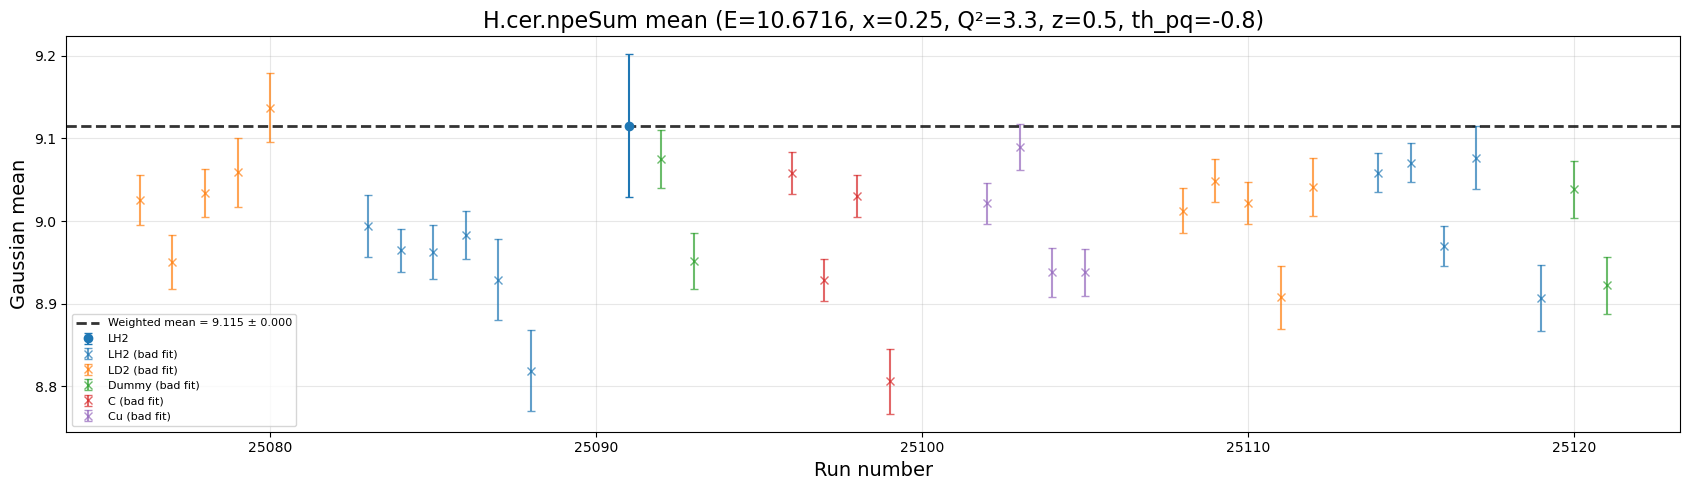

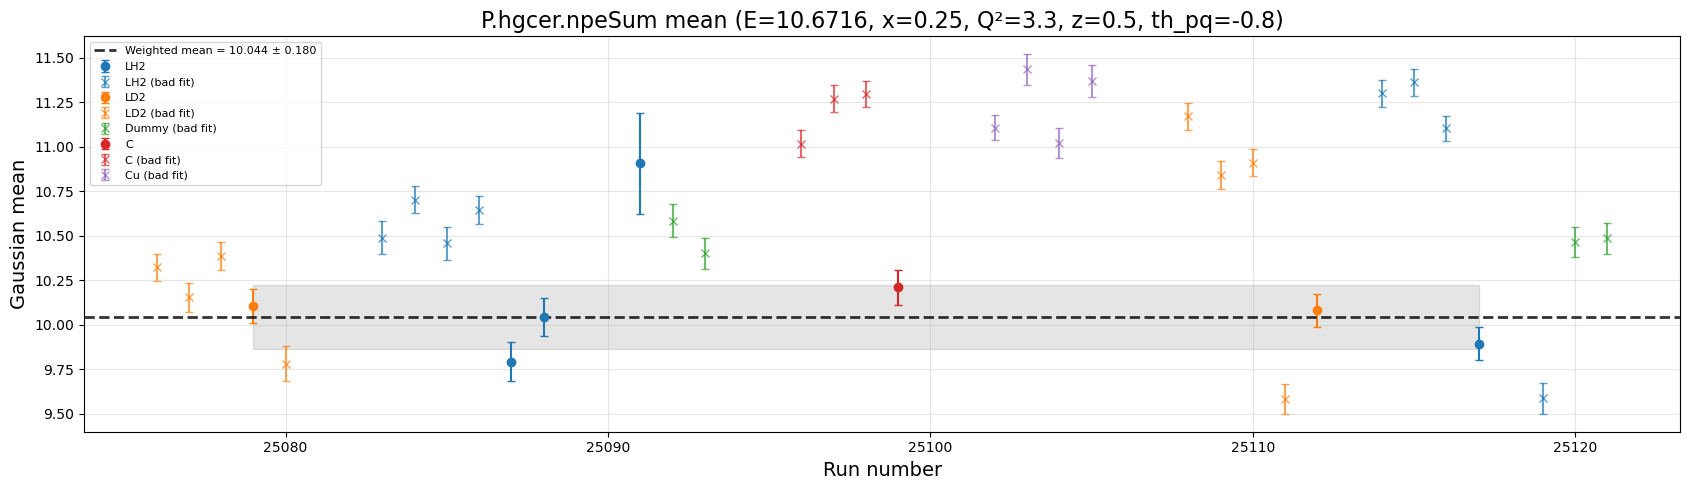

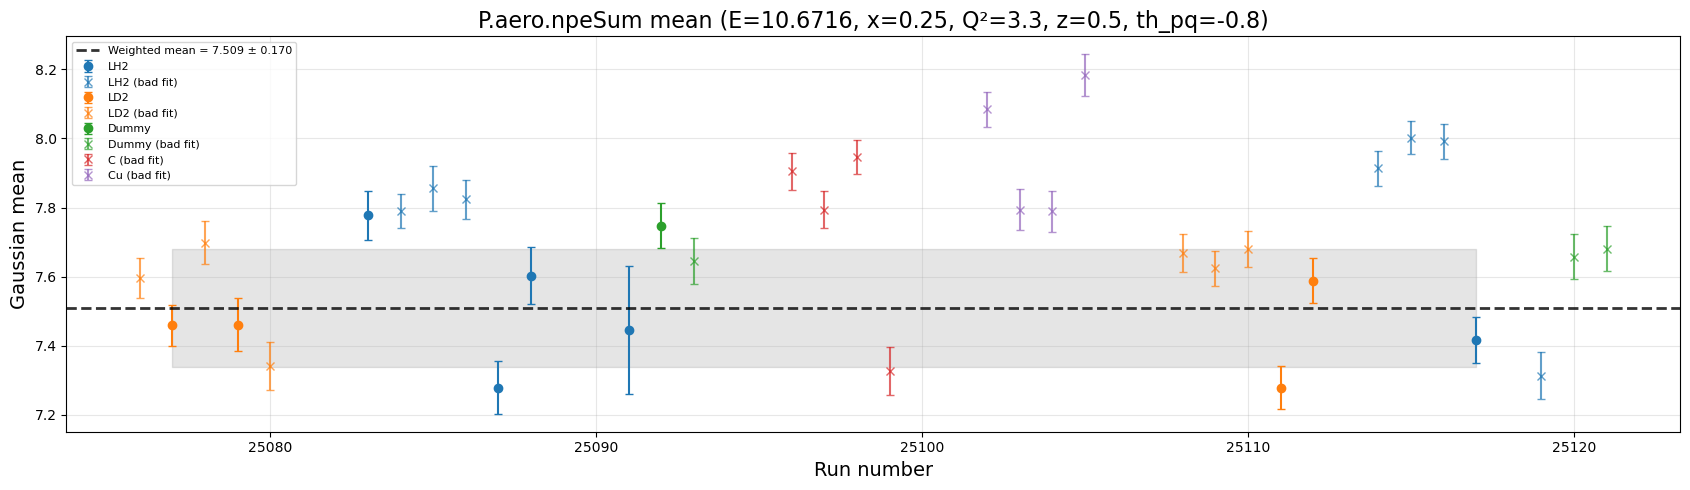

In [14]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = -0.8
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 2:

H.cer: No valid GOOD runs for weighted mean.
P.hgcer Weighted Mean = 16.877 ± 1.064
P.aero Weighted Mean = 7.985 ± 0.415


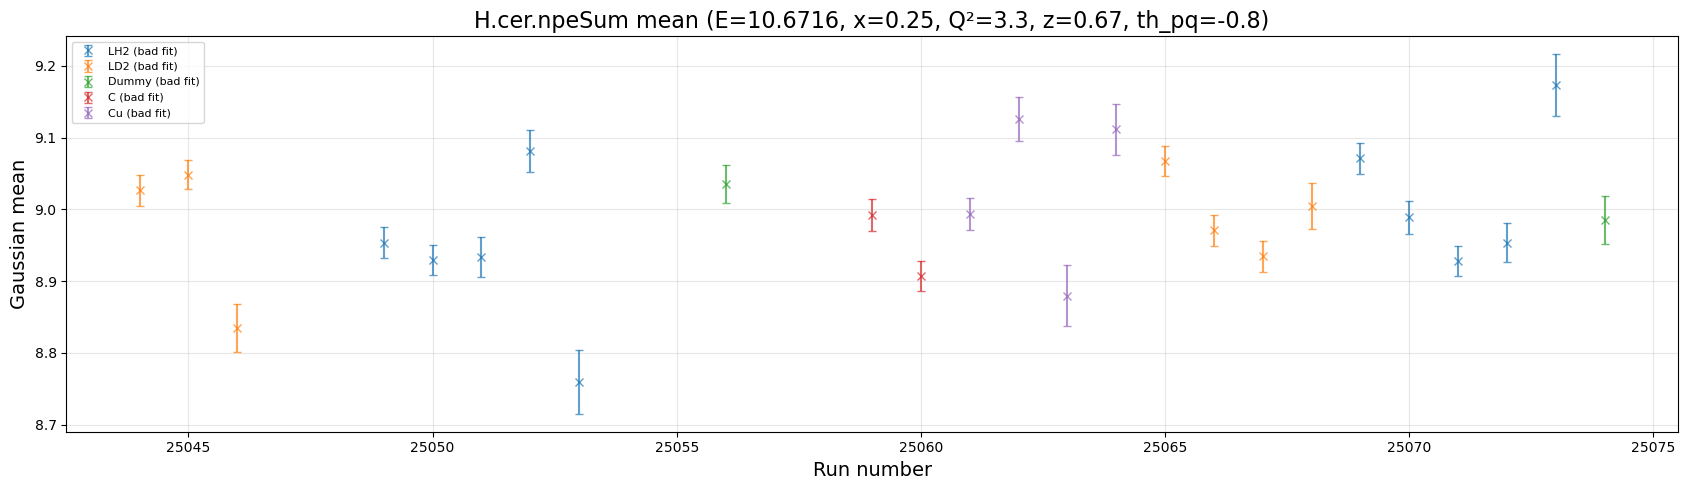

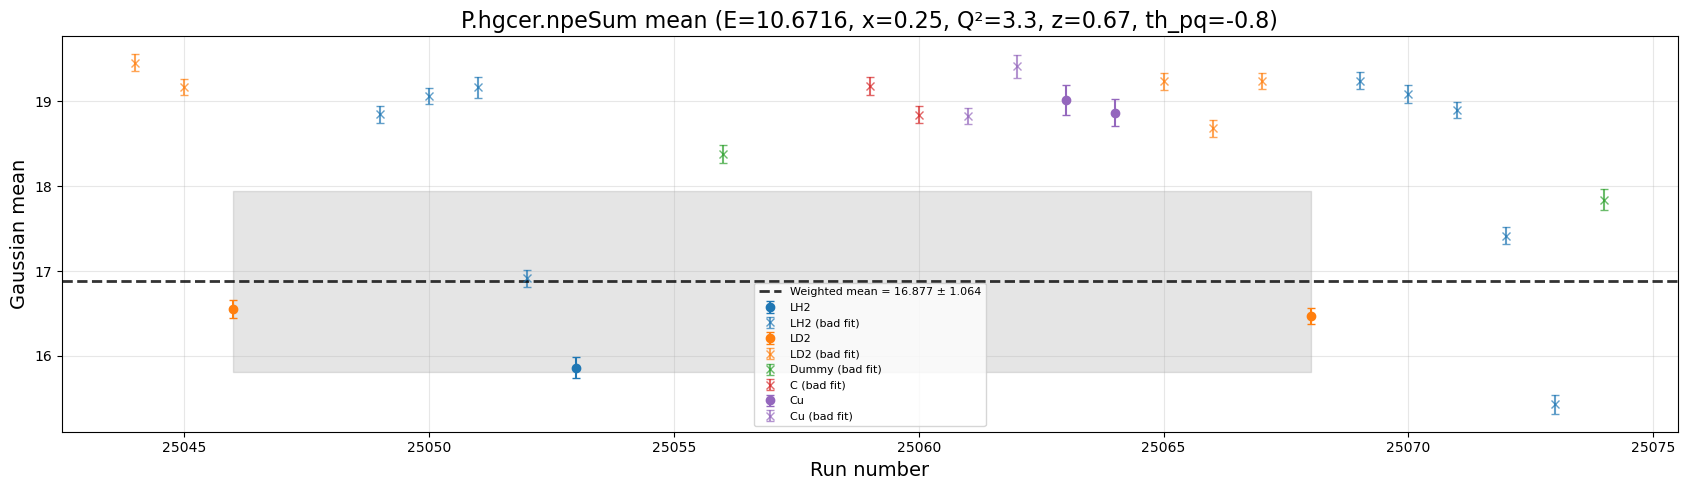

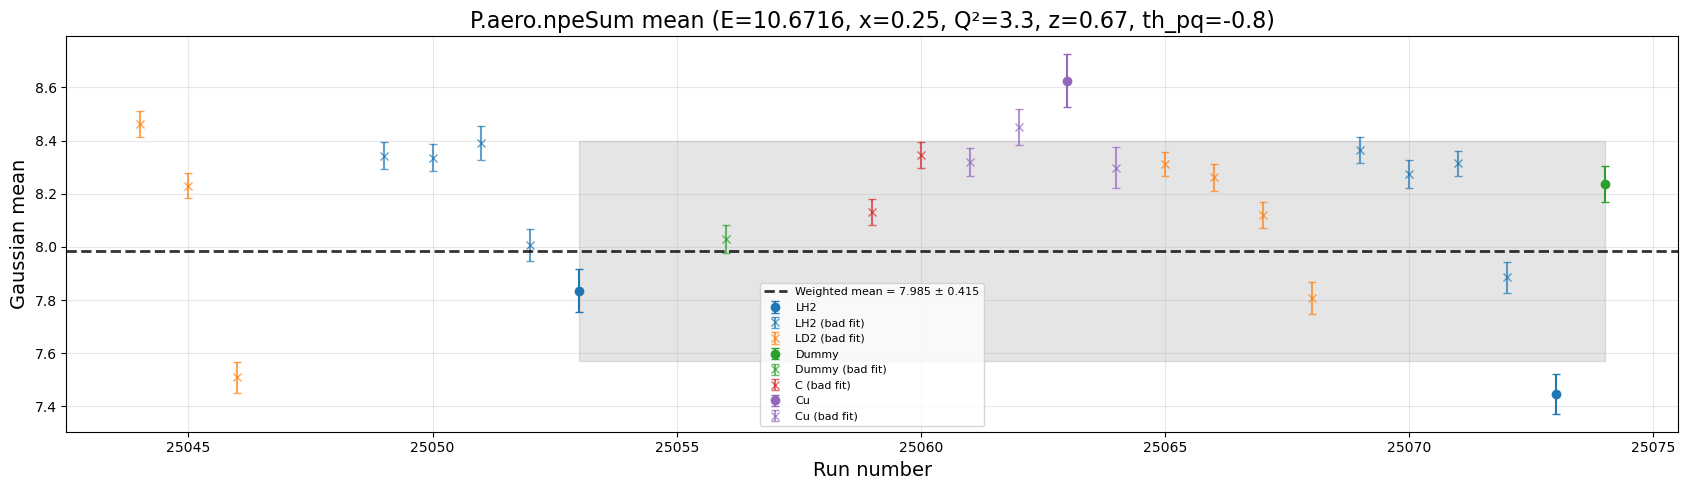

In [15]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.67
thpq = -0.8
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 3

H.cer: No valid GOOD runs for weighted mean.
P.hgcer Weighted Mean = 21.329 ± 1.680
P.aero Weighted Mean = 8.432 ± 0.315


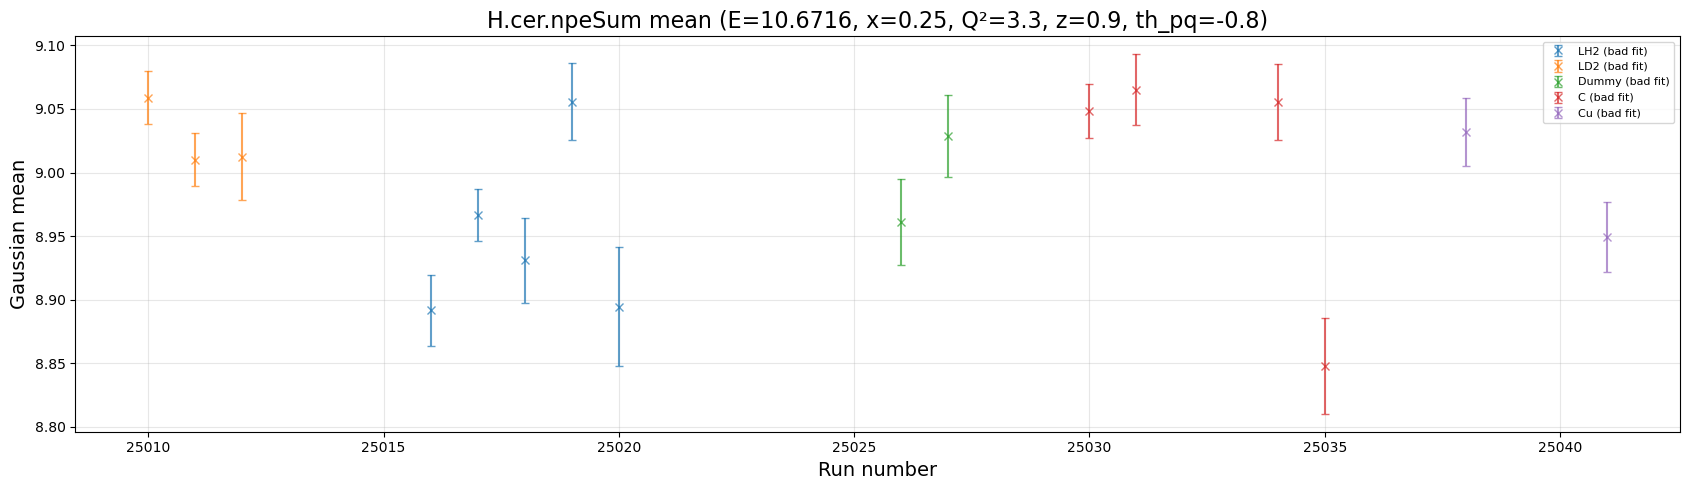

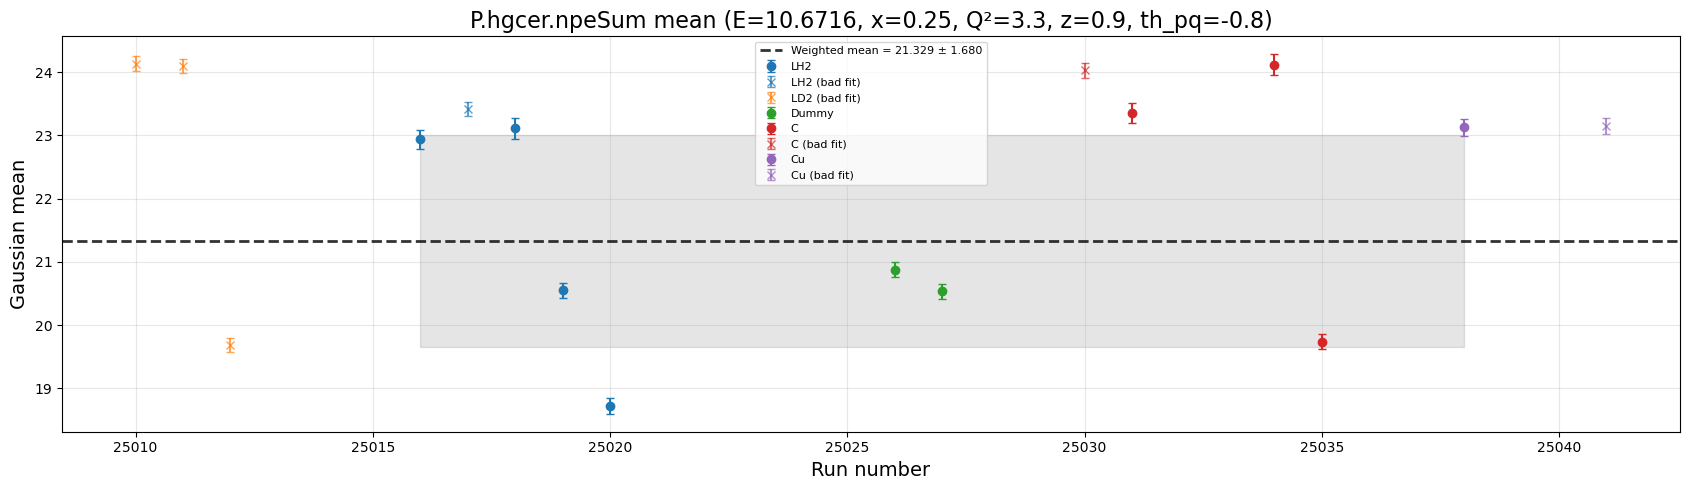

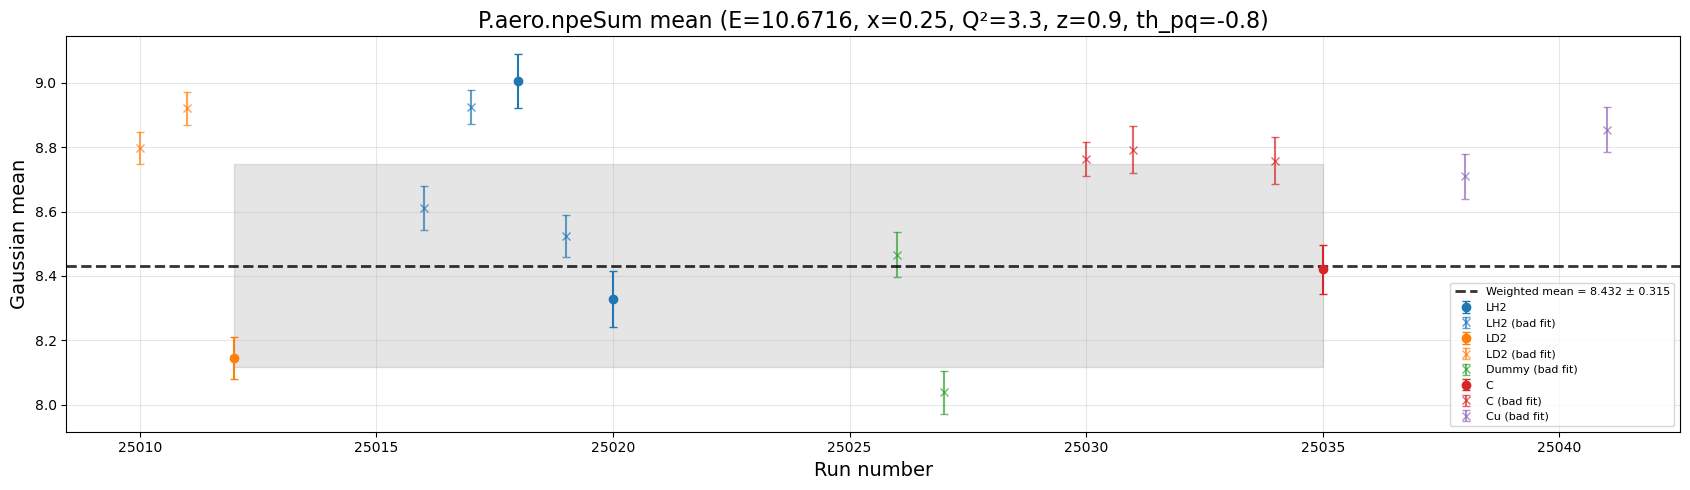

In [16]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.9
thpq = -0.8
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



### Setting 4

H.cer Weighted Mean = 8.982 ± 0.124
P.hgcer Weighted Mean = 6.548 ± 0.226
P.aero Weighted Mean = 7.413 ± 0.230


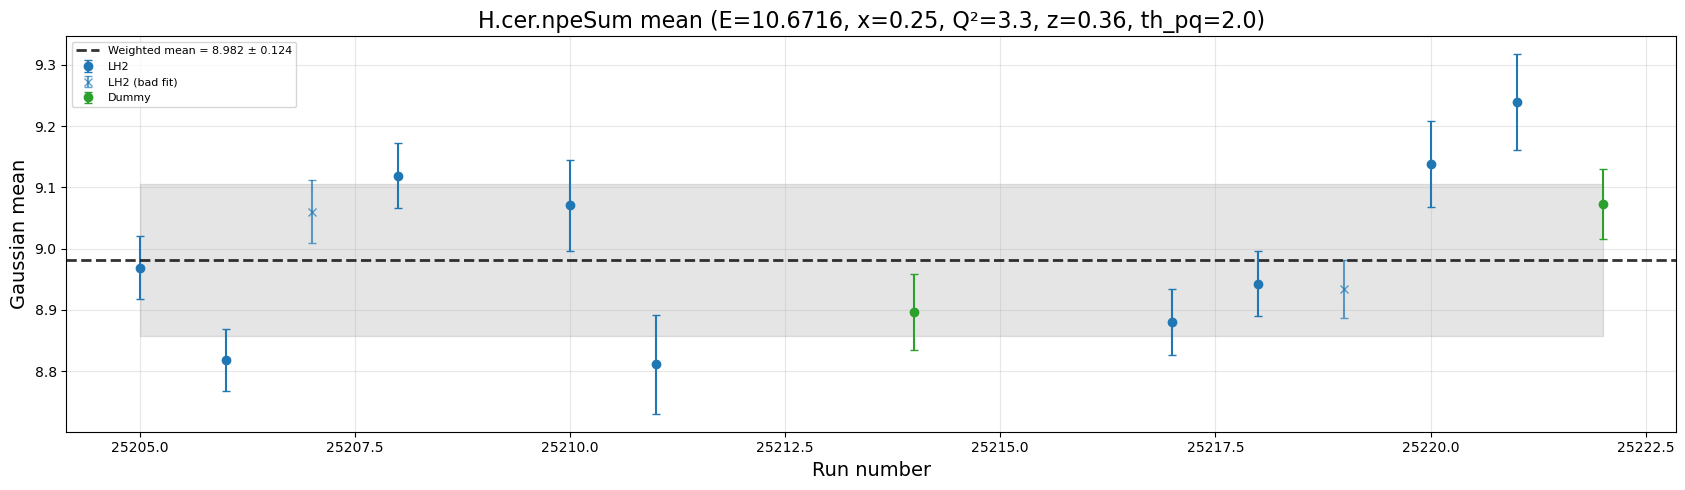

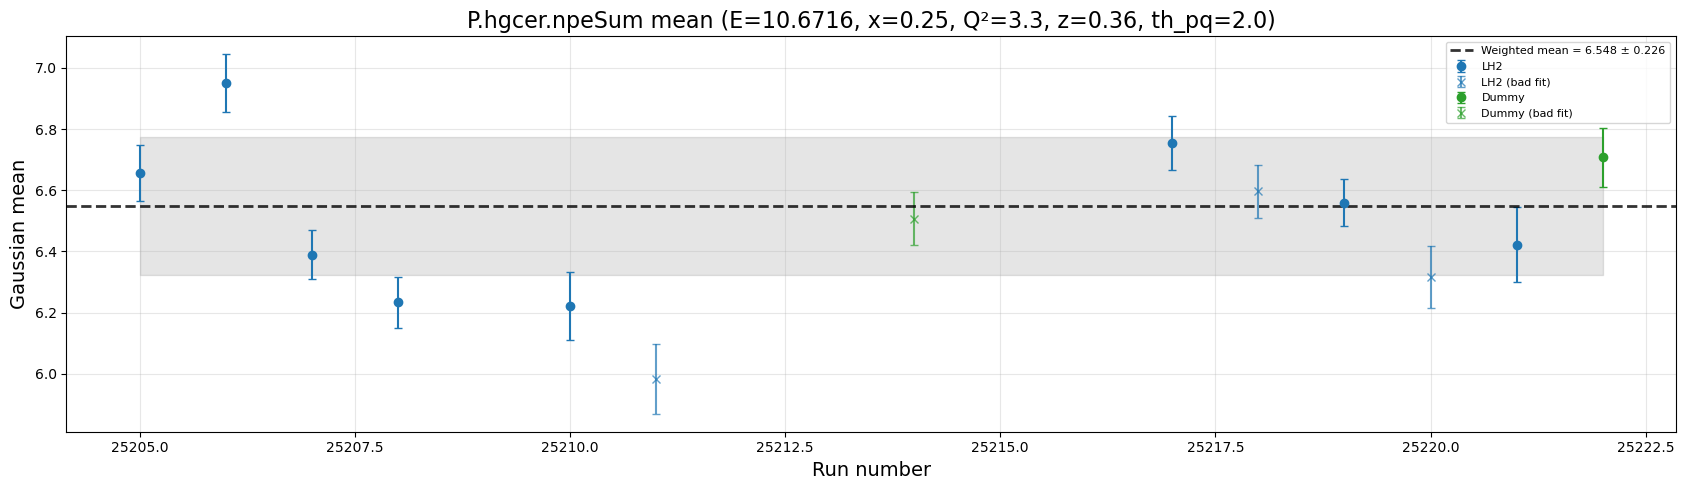

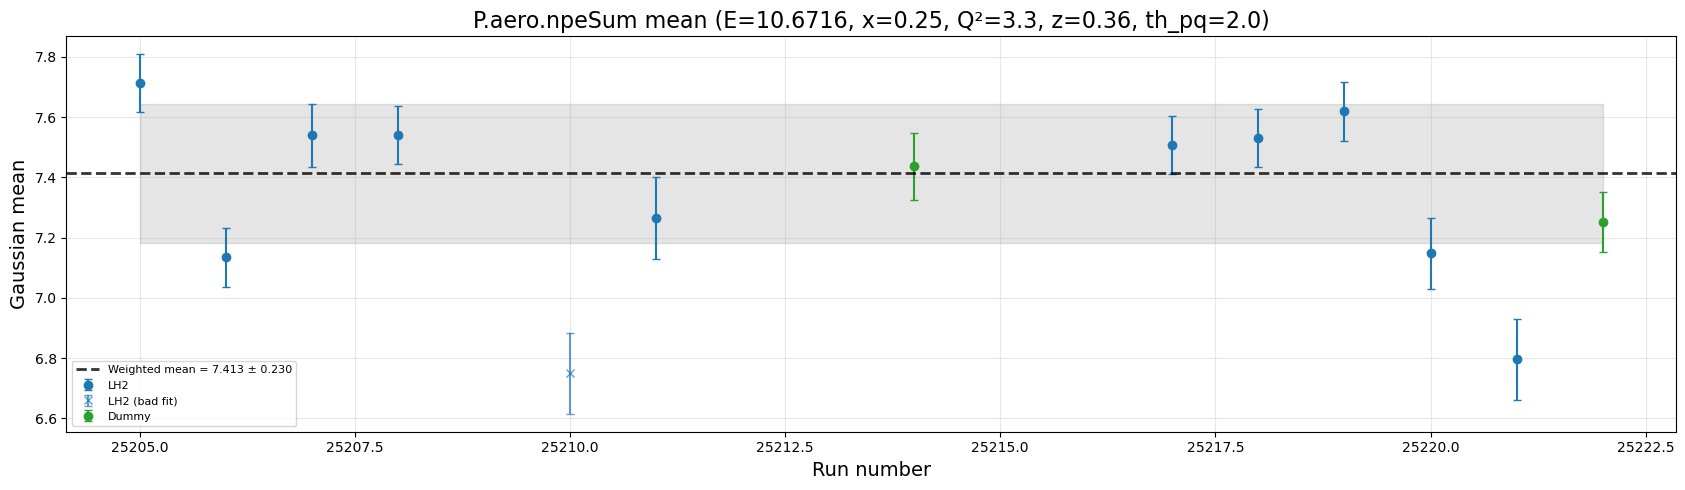

In [17]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.36
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 5

H.cer: No valid GOOD runs for weighted mean.
P.hgcer Weighted Mean = 9.589 ± 0.248
P.aero Weighted Mean = 7.490 ± 0.200


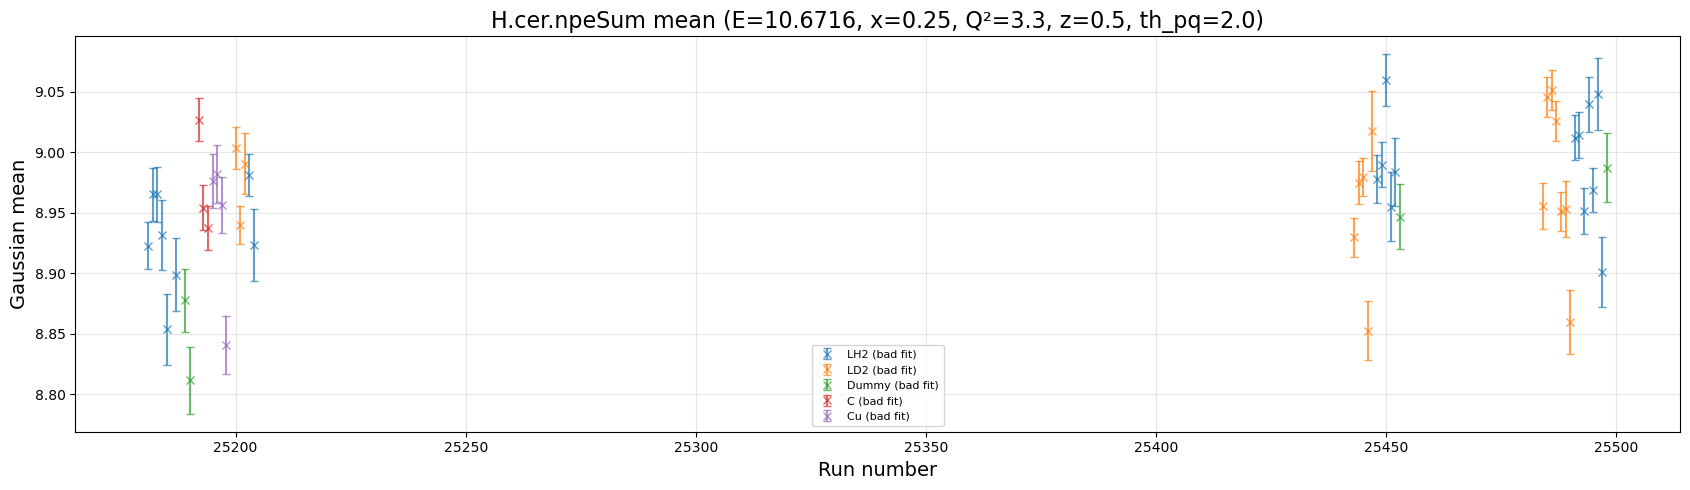

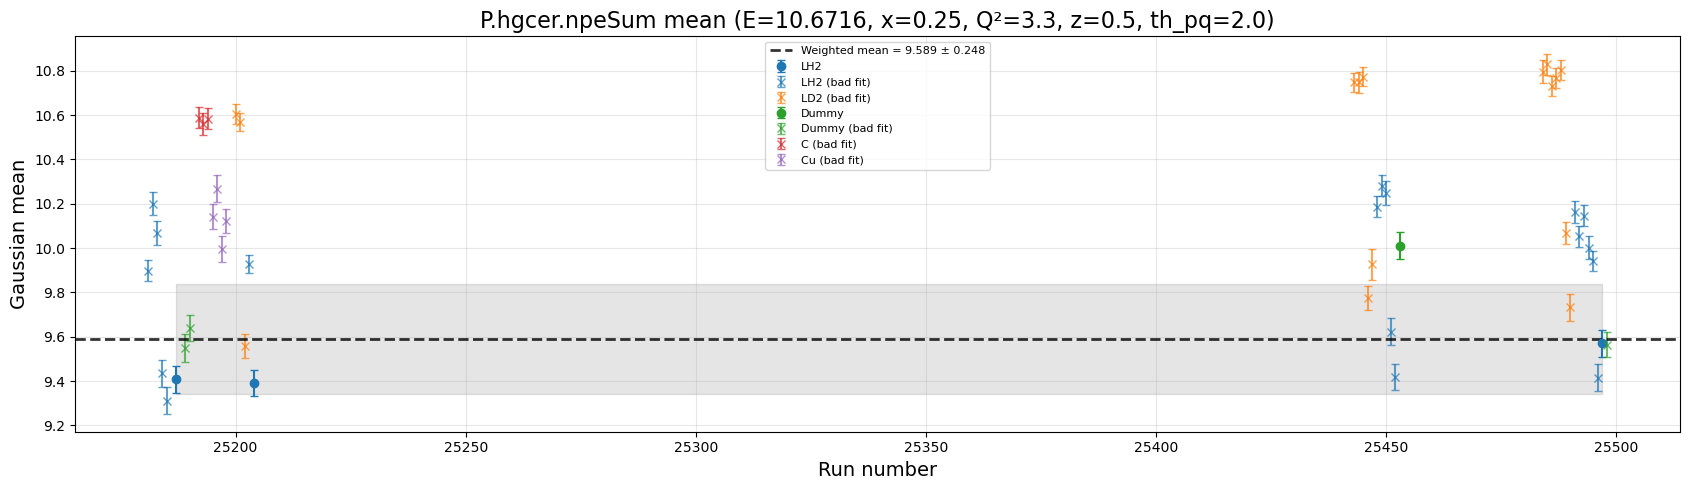

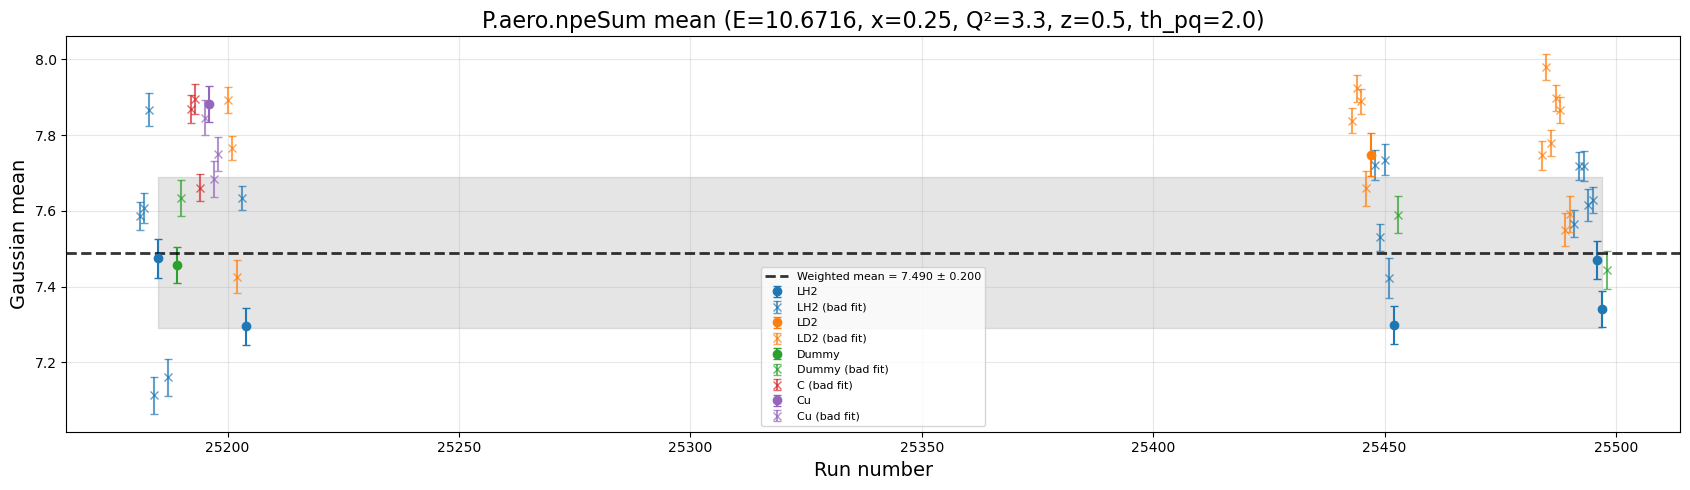

In [18]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 6:

H.cer Weighted Mean = 9.111 ± 0.000
P.hgcer Weighted Mean = 14.945 ± 0.433
P.aero Weighted Mean = 7.634 ± 0.211


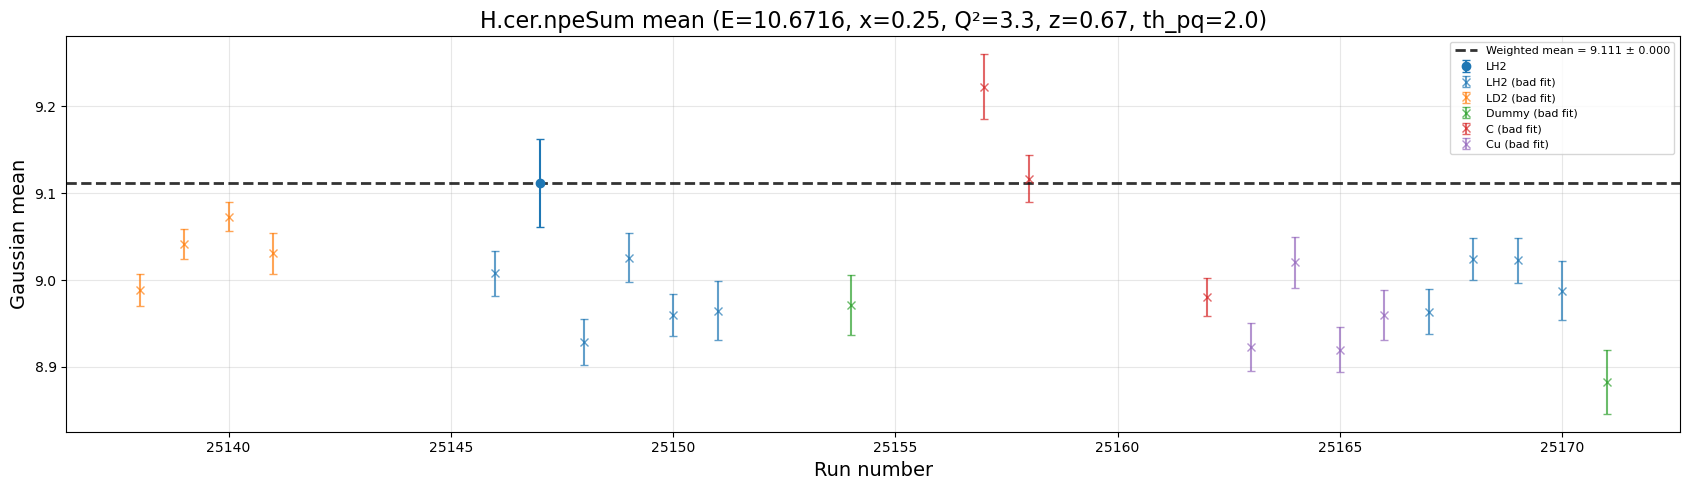

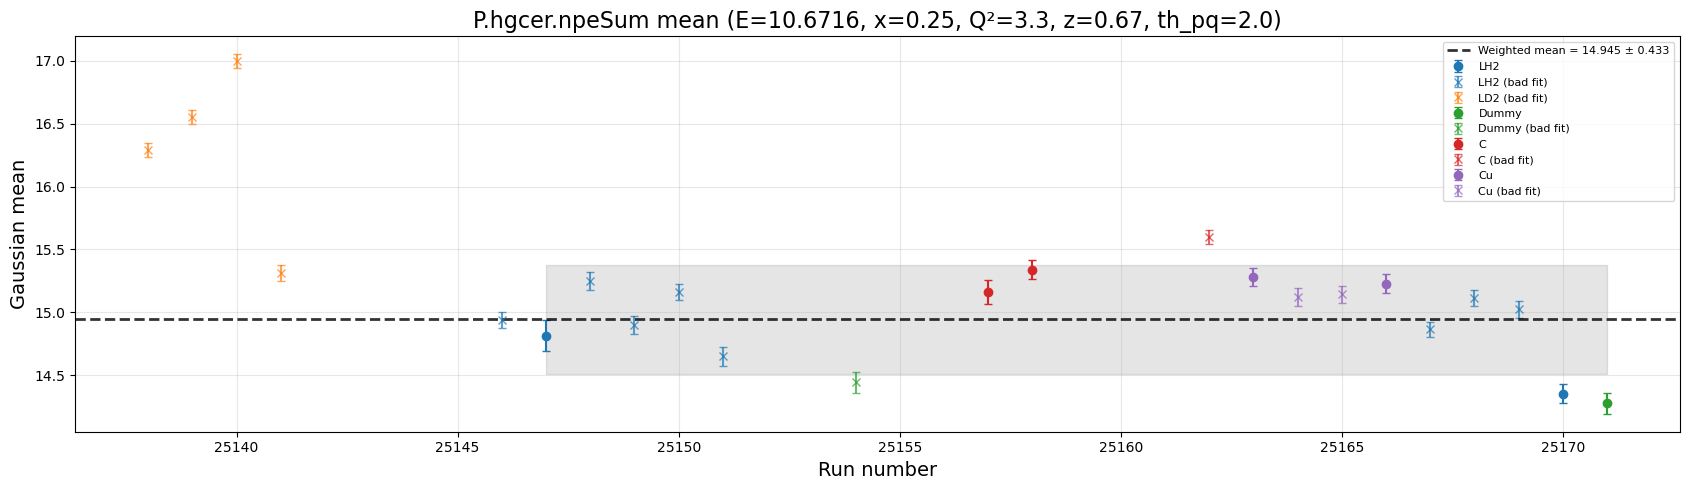

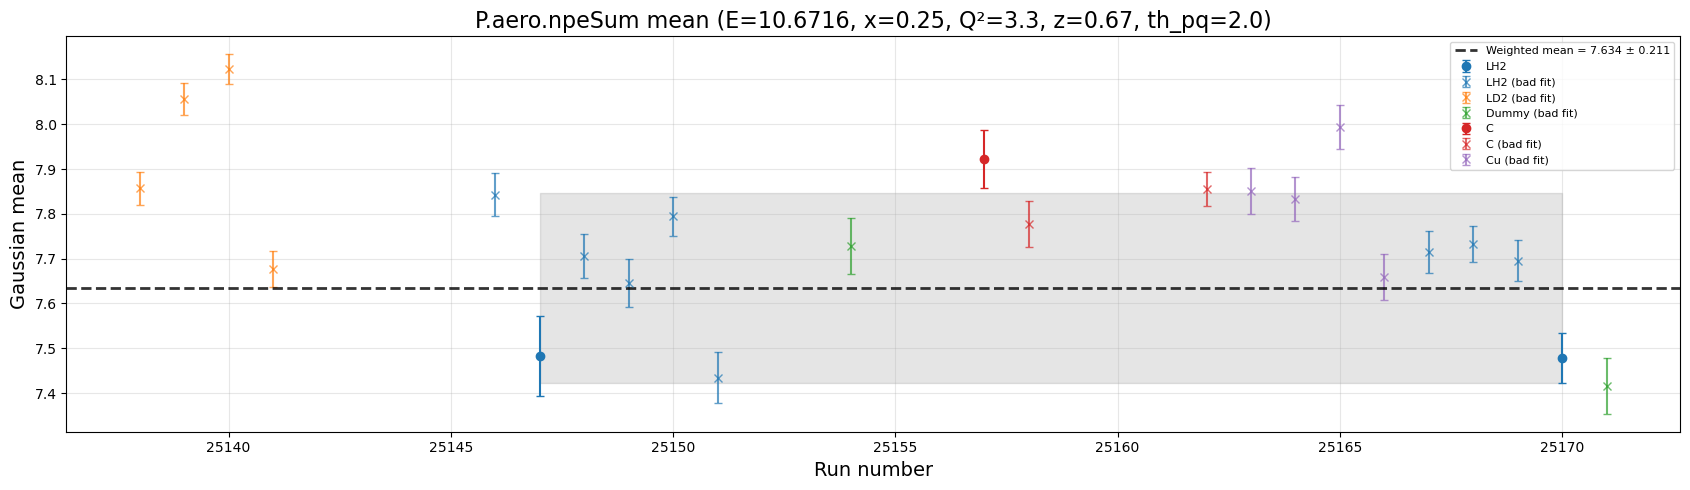

In [19]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.67
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 7:

H.cer Weighted Mean = 8.922 ± 0.326
P.hgcer Weighted Mean = 16.996 ± 0.422
P.aero Weighted Mean = 7.991 ± 0.164


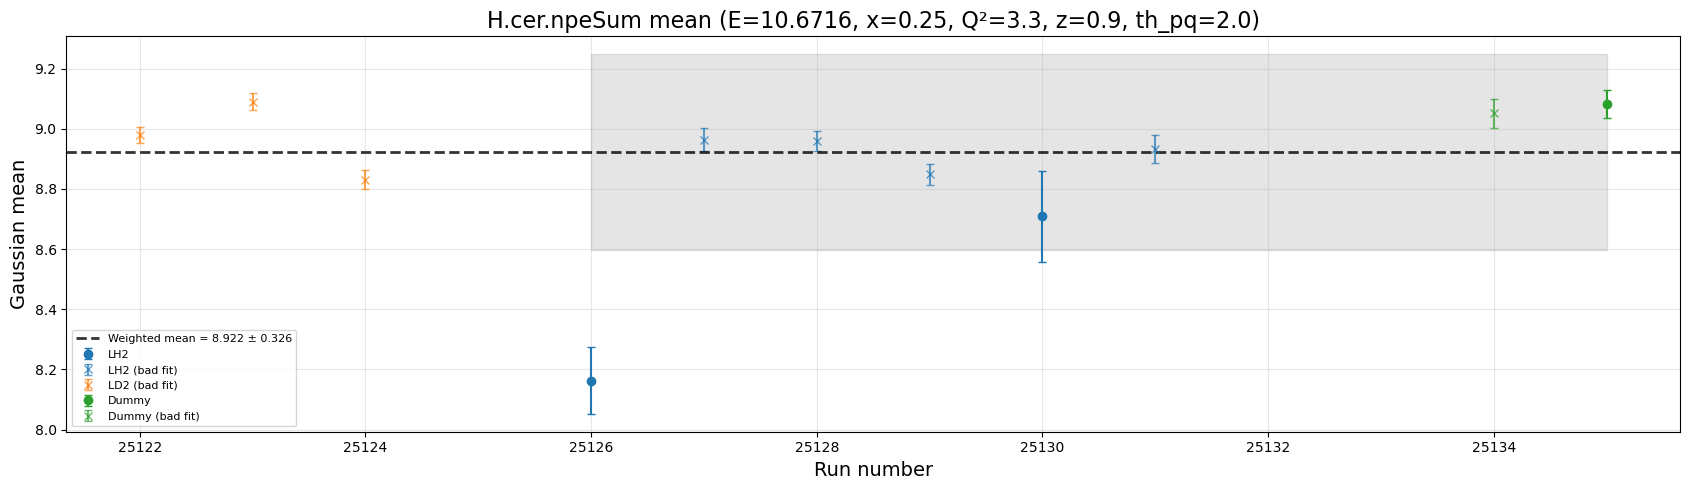

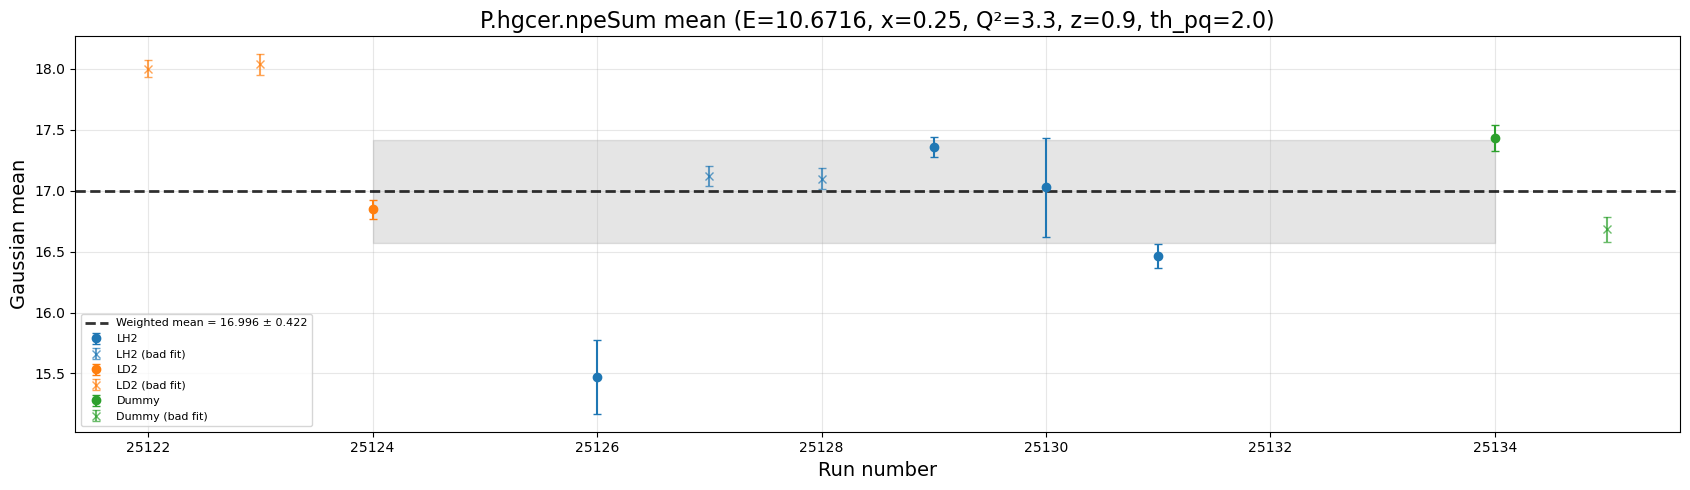

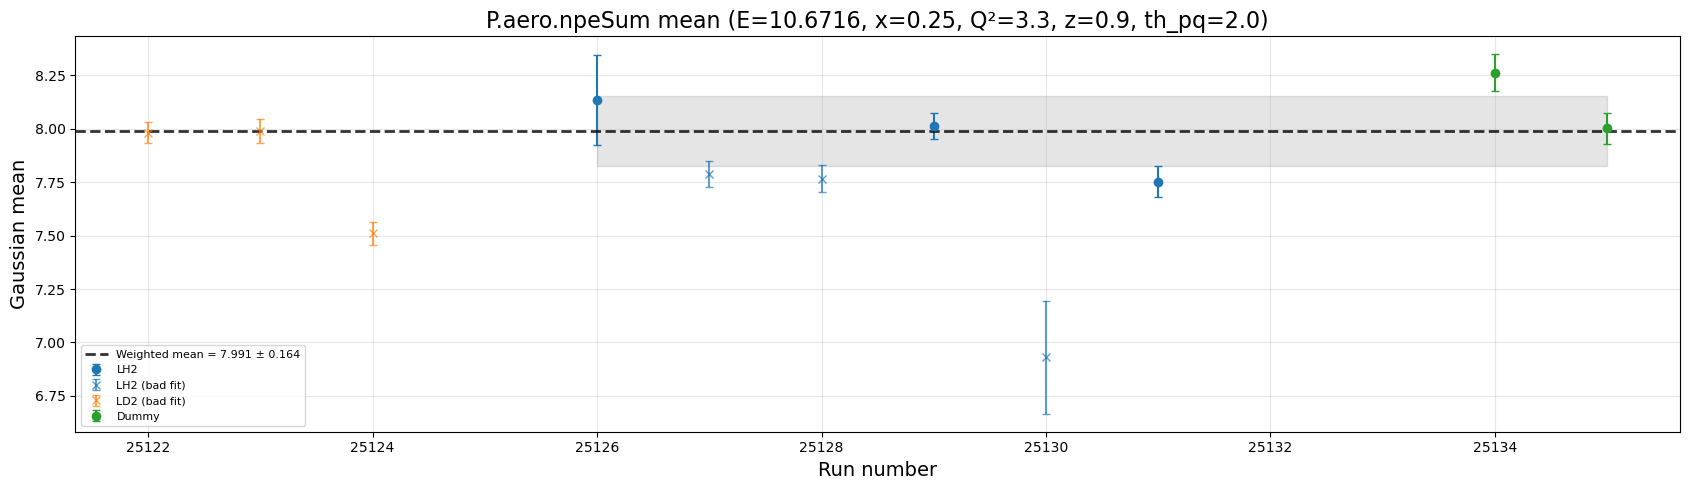

In [20]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.9
thpq = 2.0
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Settting 8

H.cer: No valid GOOD runs for weighted mean.
P.hgcer Weighted Mean = 9.107 ± 0.129
P.aero Weighted Mean = 7.564 ± 0.000


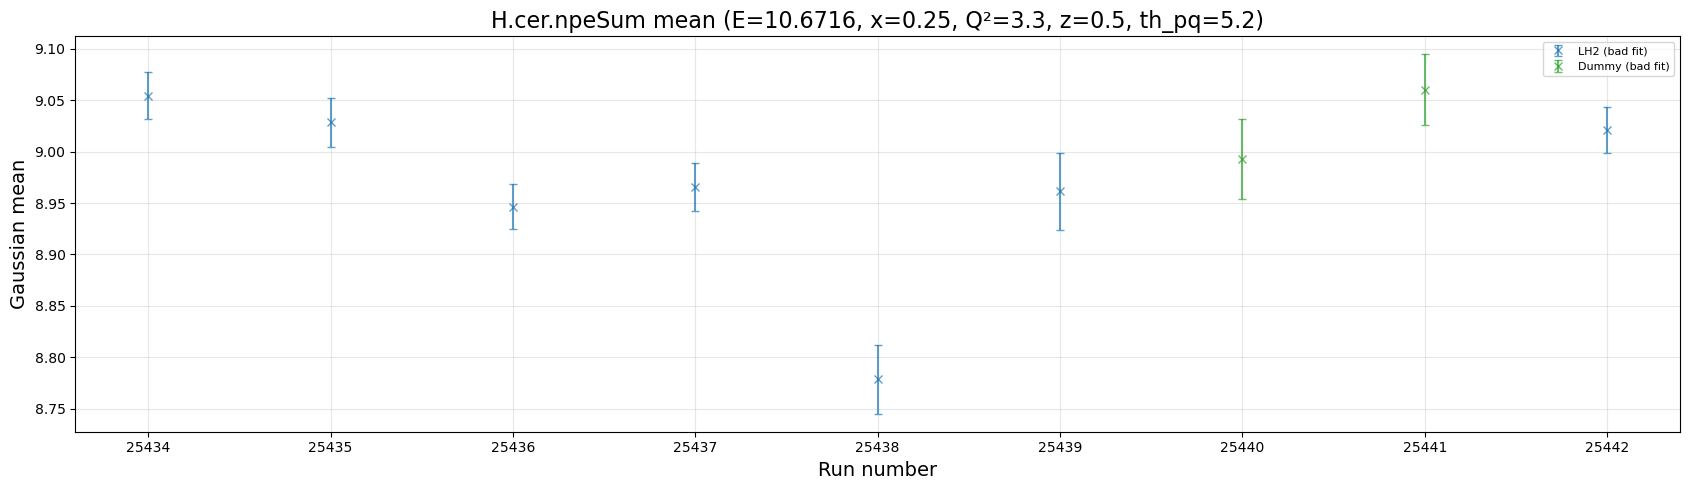

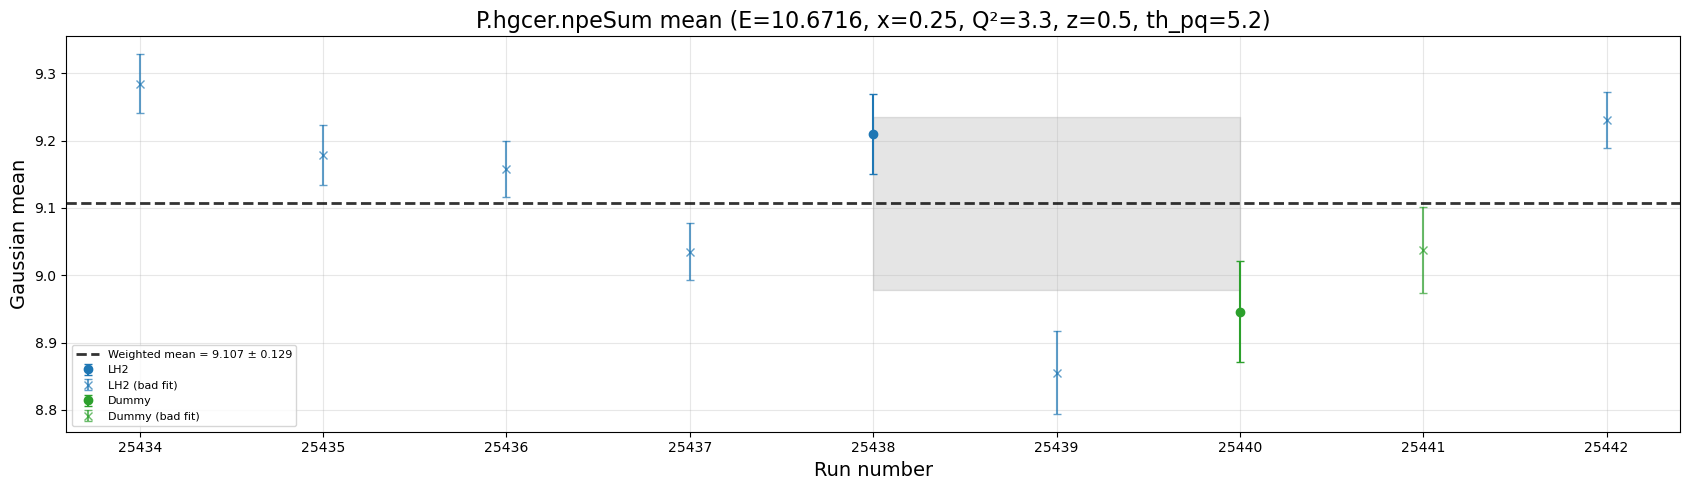

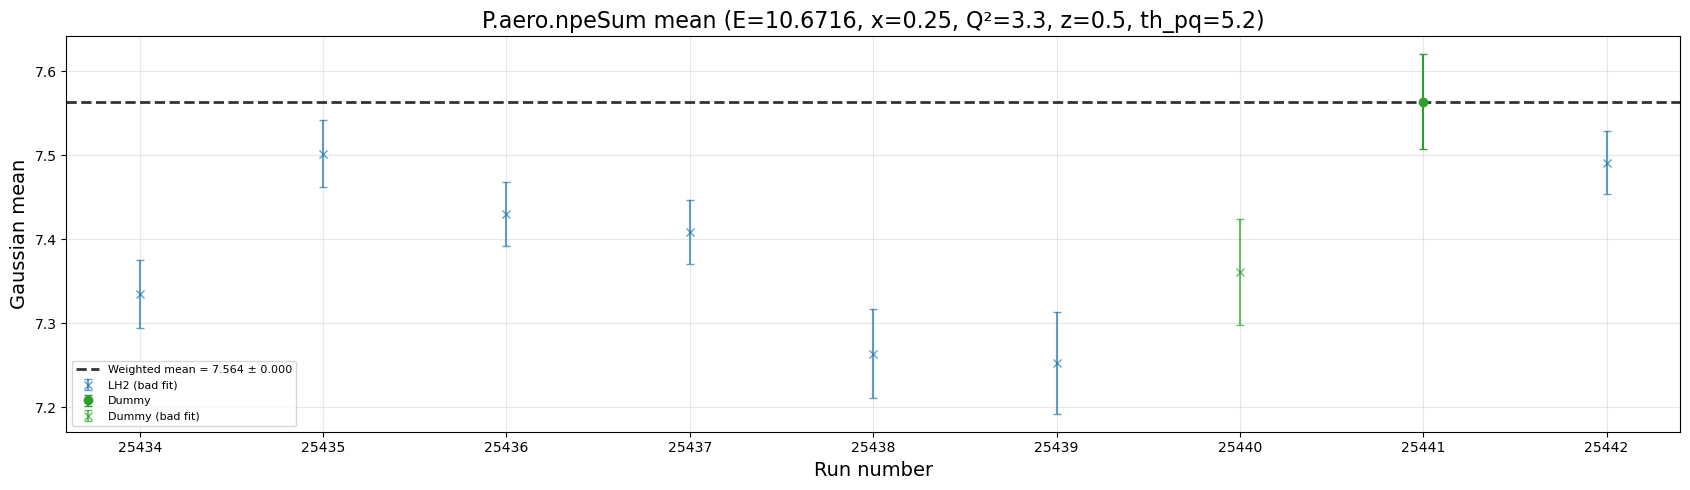

In [21]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 5.2
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 9:

H.cer Weighted Mean = 8.919 ± 0.035
P.hgcer Weighted Mean = 8.598 ± 0.000
P.aero Weighted Mean = 7.297 ± 0.061


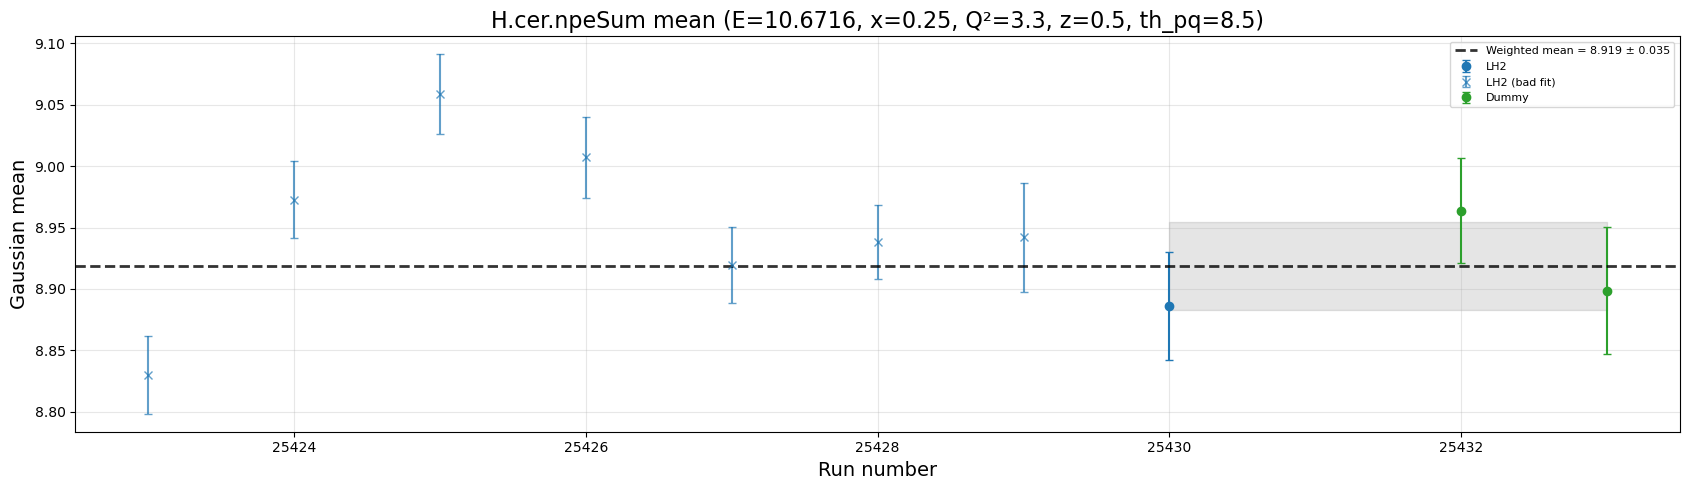

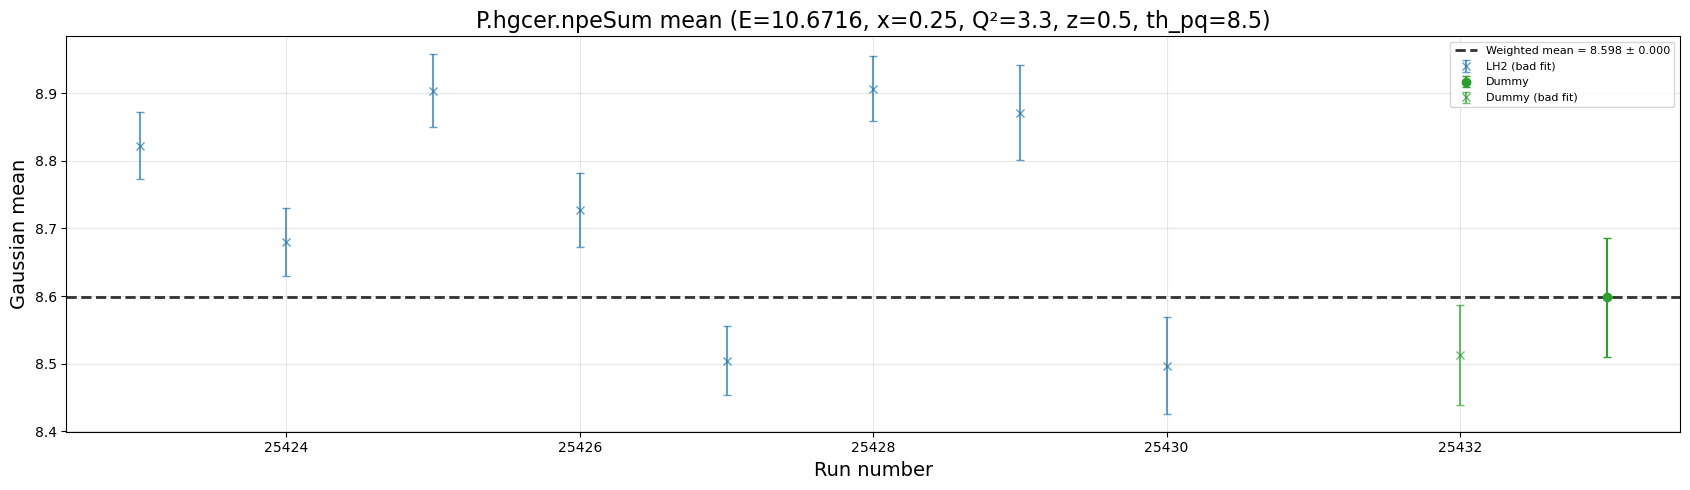

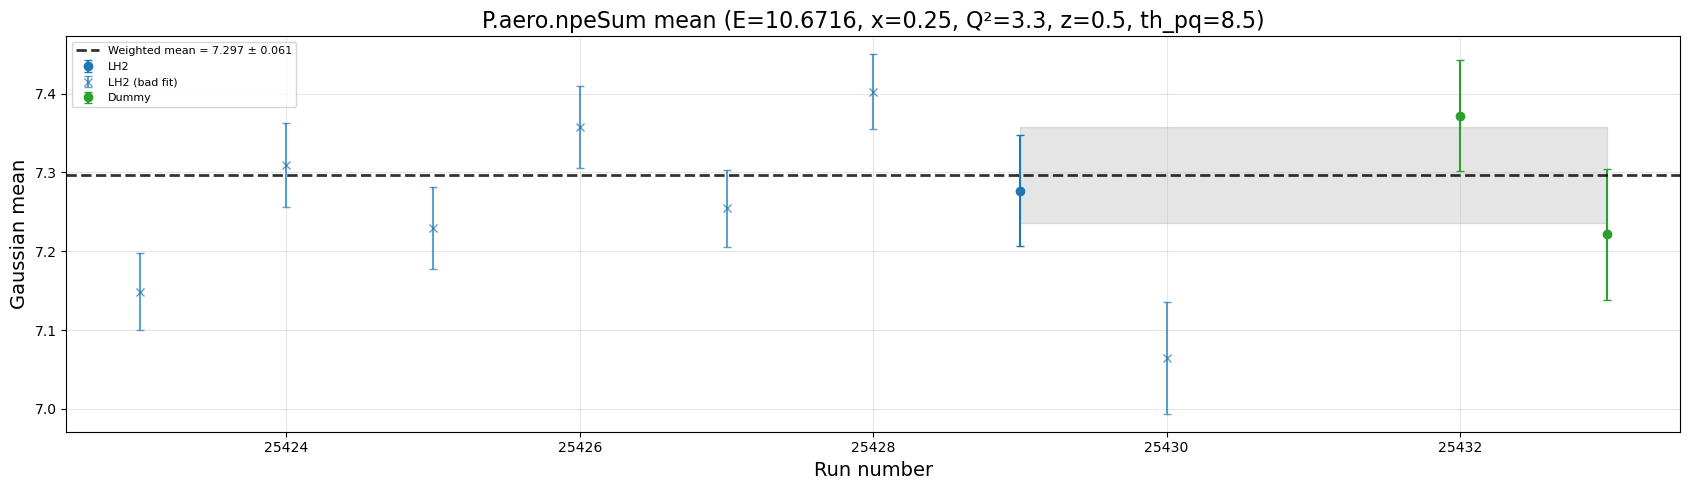

In [22]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 8.5
run_type = "PI-SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf < 2.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### $\pi^+$: Setting 1:

H.cer Weighted Mean = 8.978 ± 0.203
P.hgcer Weighted Mean = 6.380 ± 0.194
P.aero Weighted Mean = 6.608 ± 0.220


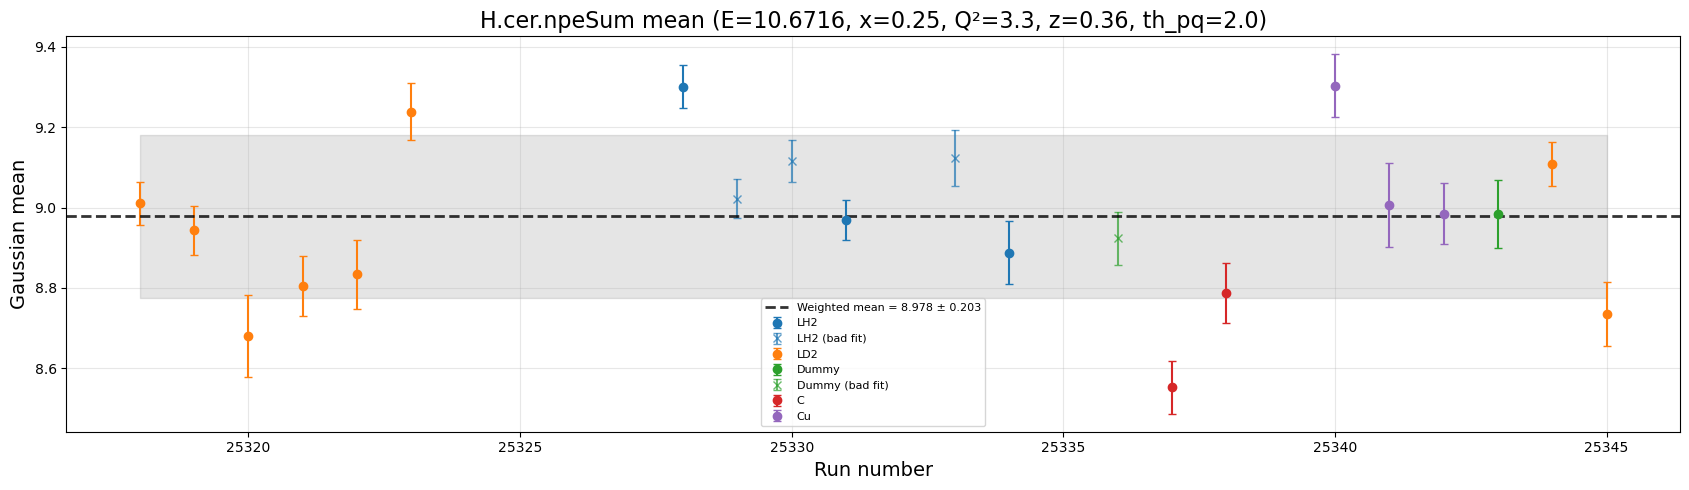

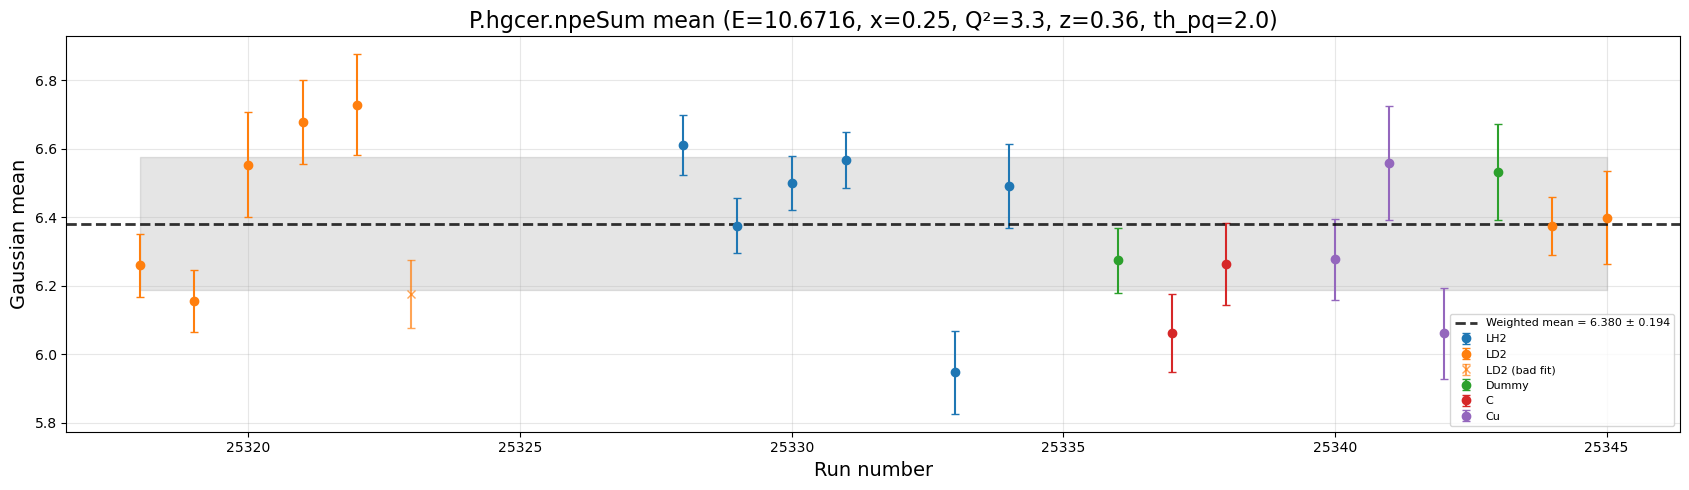

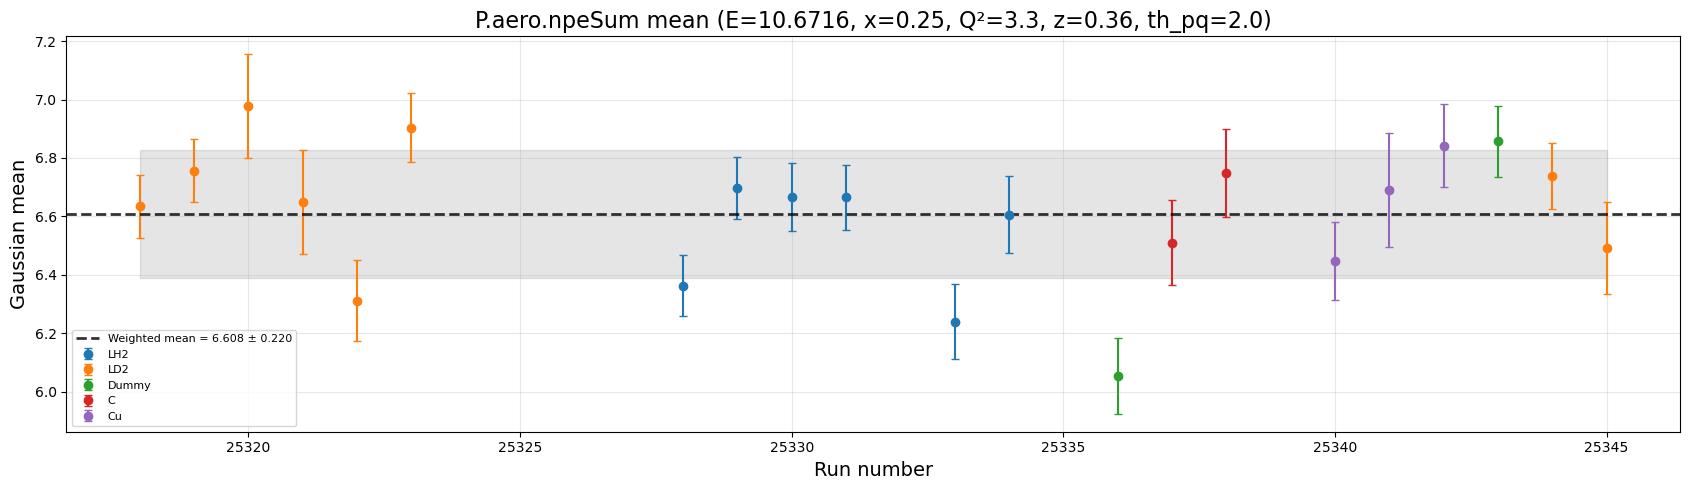

In [23]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.36
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 2:

H.cer: No valid GOOD runs for weighted mean.
P.hgcer Weighted Mean = 9.303 ± 0.239
P.aero Weighted Mean = 6.712 ± 0.217


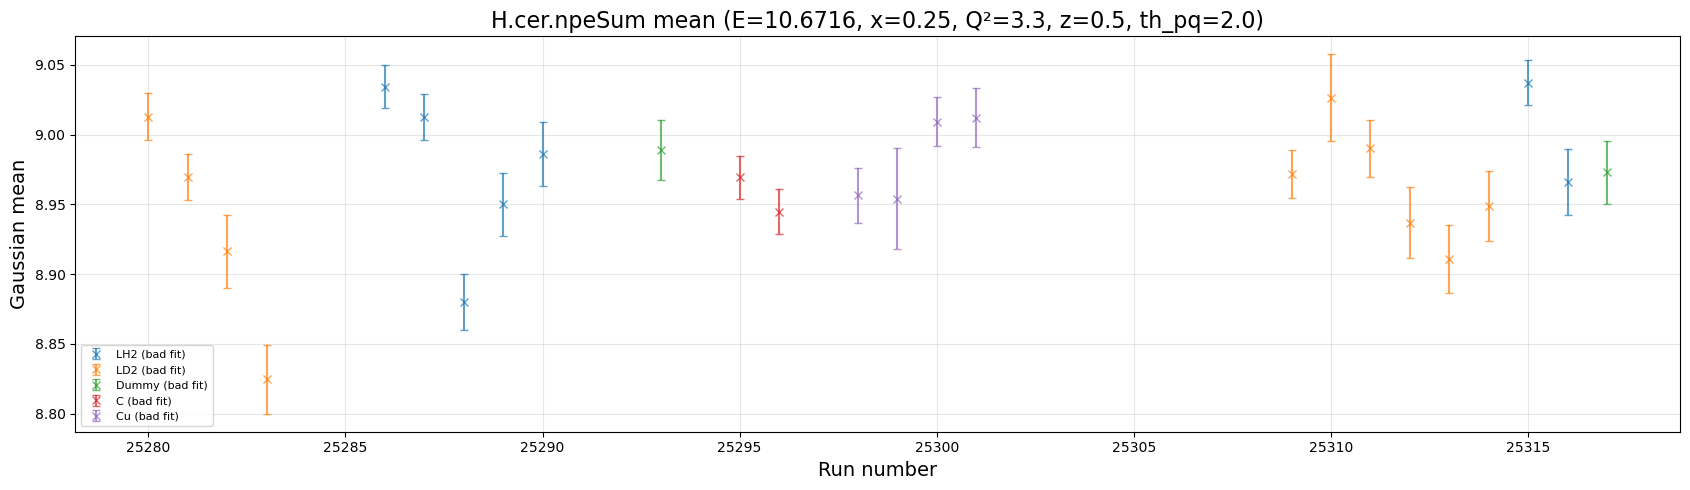

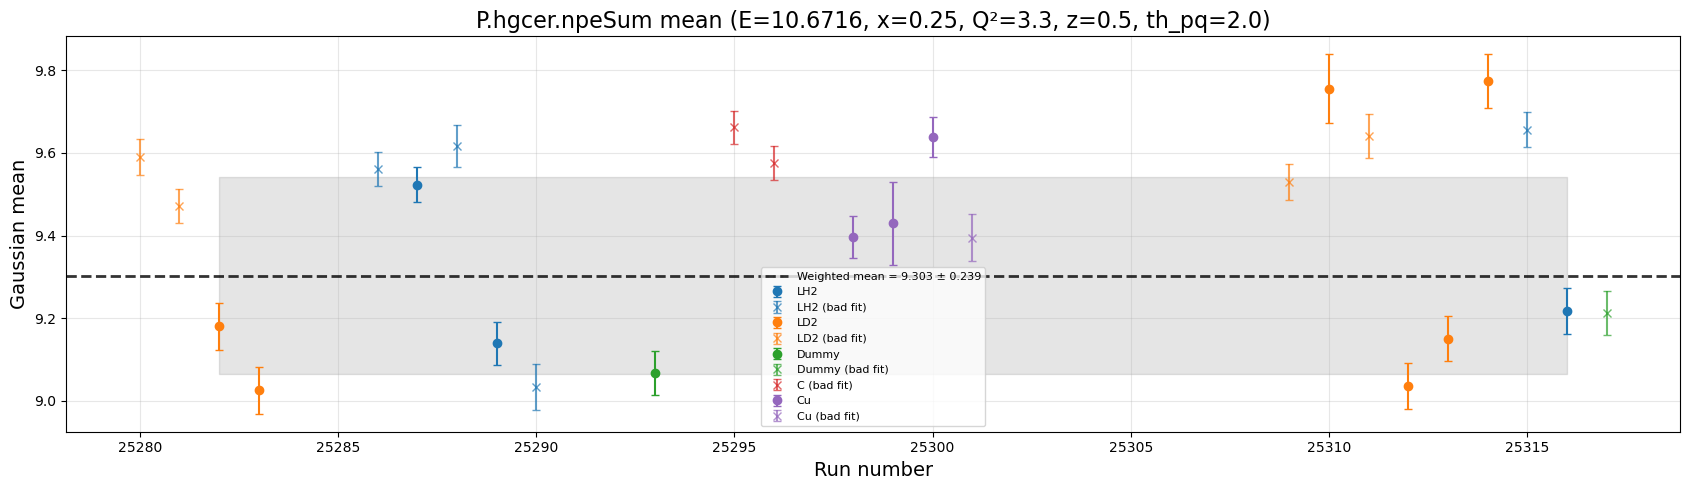

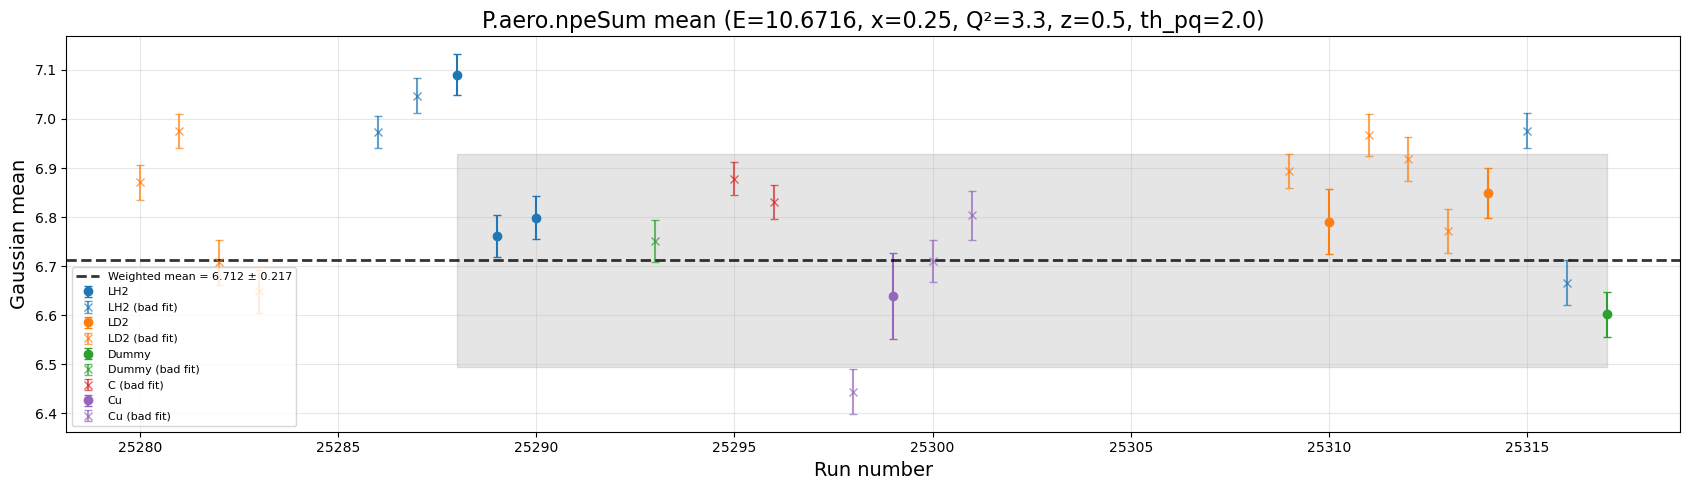

In [24]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 3:

H.cer Weighted Mean = 8.985 ± 0.054
P.hgcer Weighted Mean = 14.331 ± 0.352
P.aero Weighted Mean = 6.781 ± 0.150


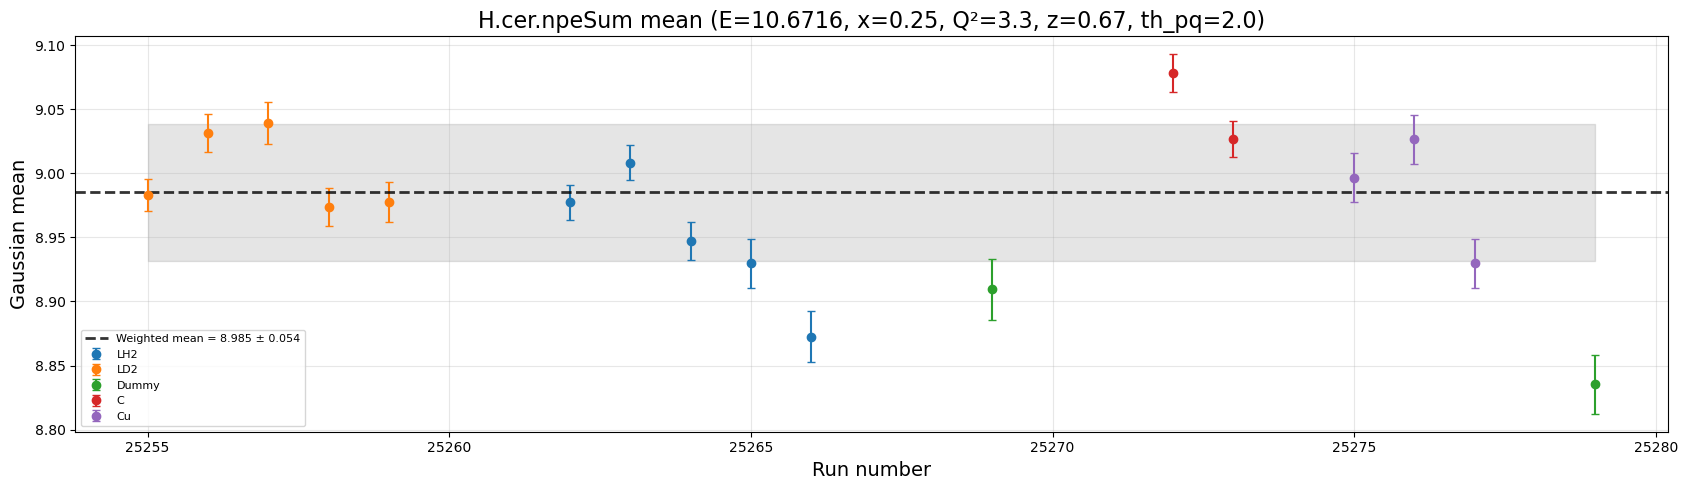

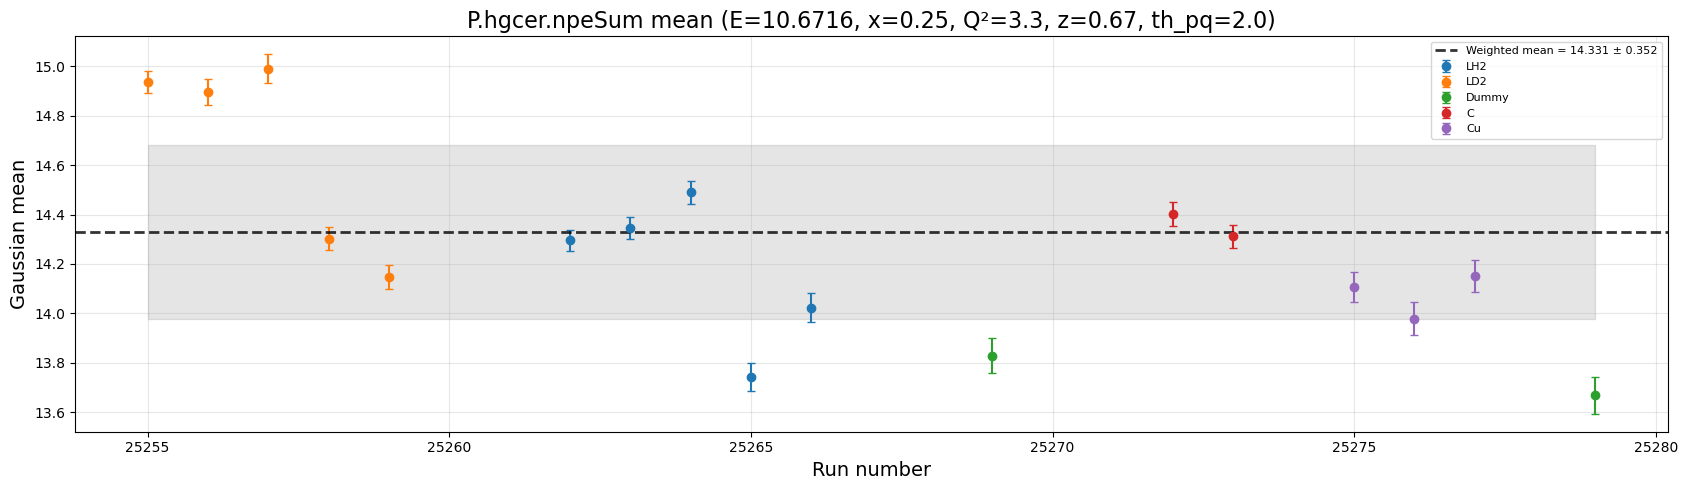

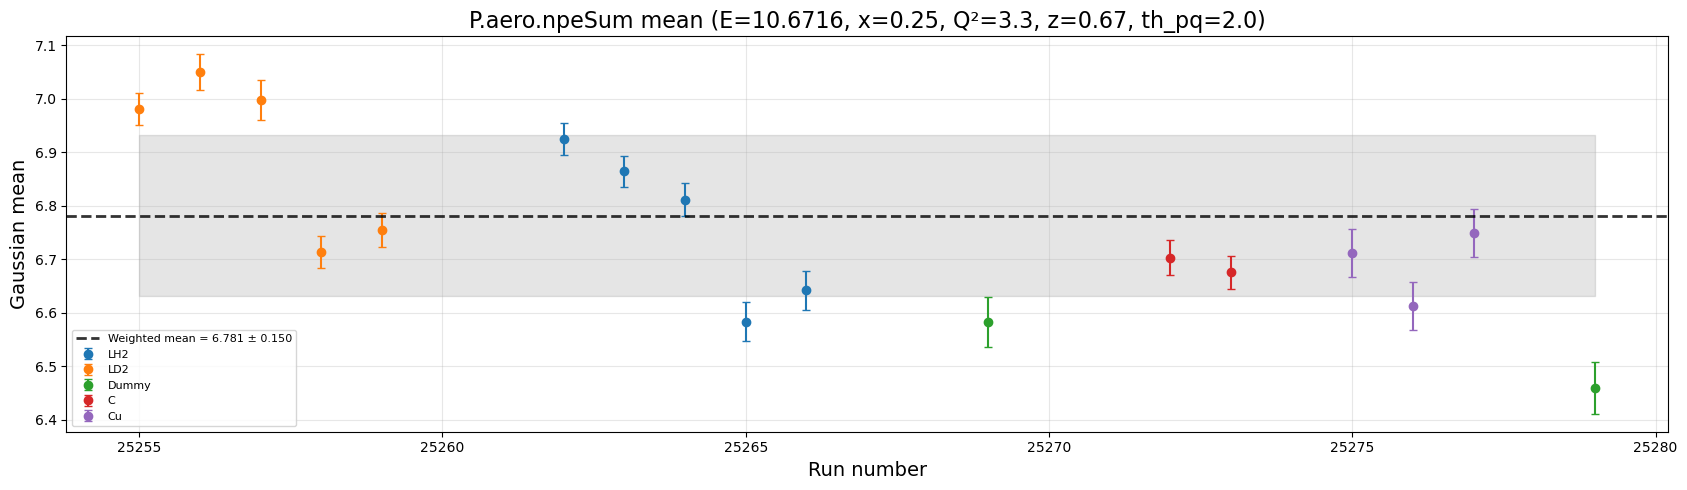

In [25]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.67
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.5 < chi2ndf:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 4:

H.cer: No valid GOOD runs for weighted mean.
P.hgcer Weighted Mean = 15.464 ± 0.146
P.aero Weighted Mean = 7.145 ± 0.088


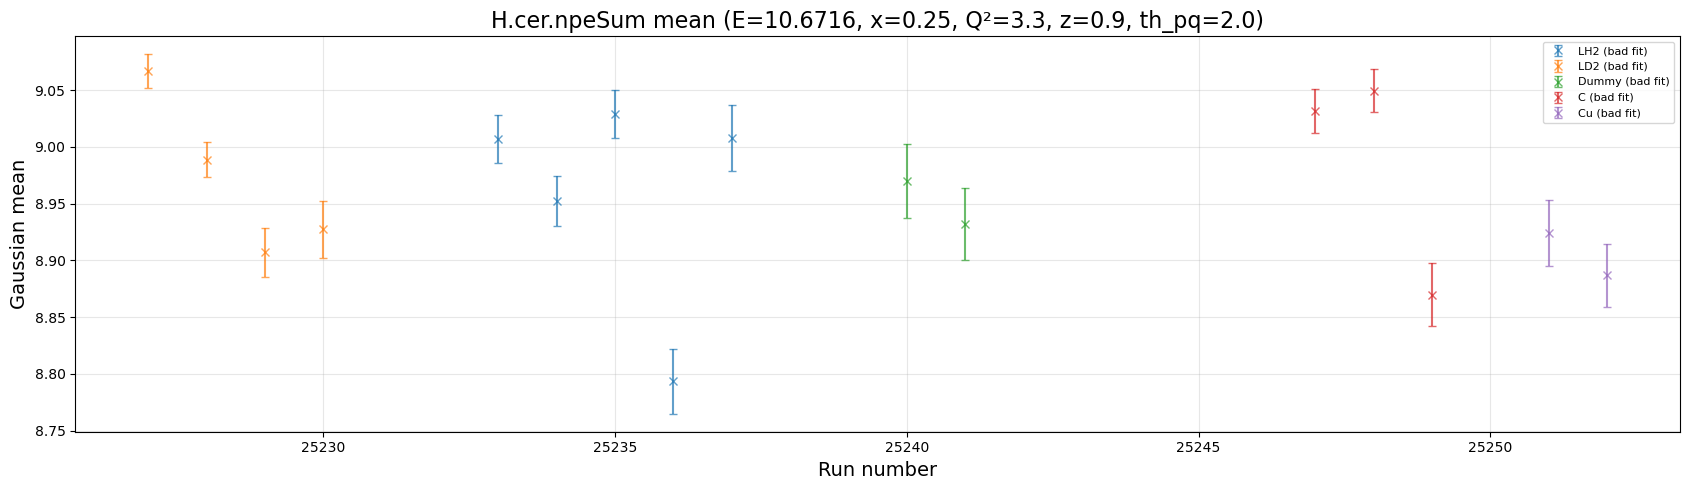

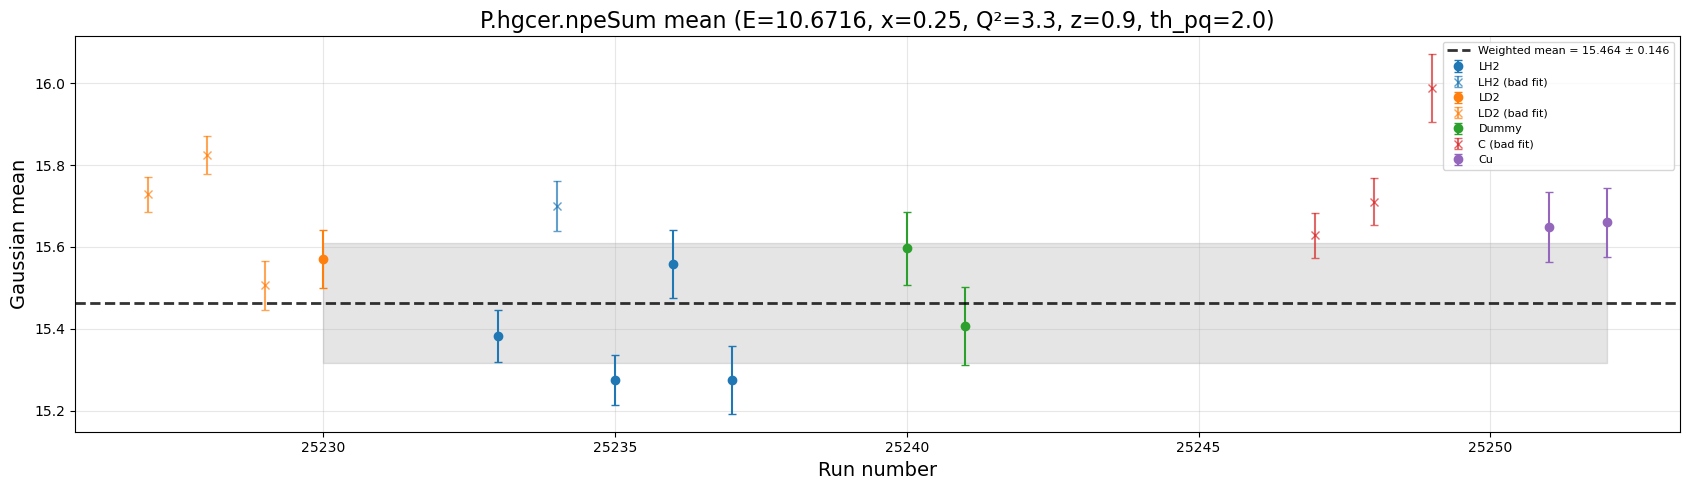

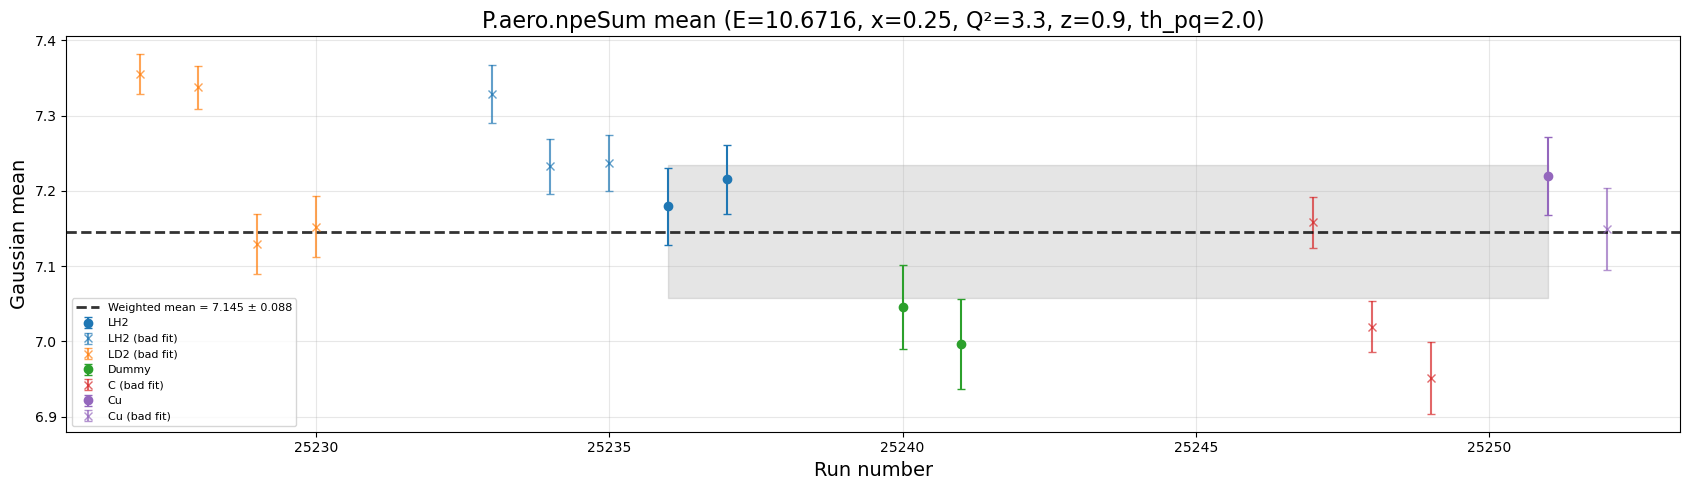

In [26]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.9
thpq = 2.0
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

### Setting 5:

H.cer Weighted Mean = 8.850 ± 0.000
P.hgcer Weighted Mean = 8.911 ± 0.092
P.aero Weighted Mean = 6.712 ± 0.130


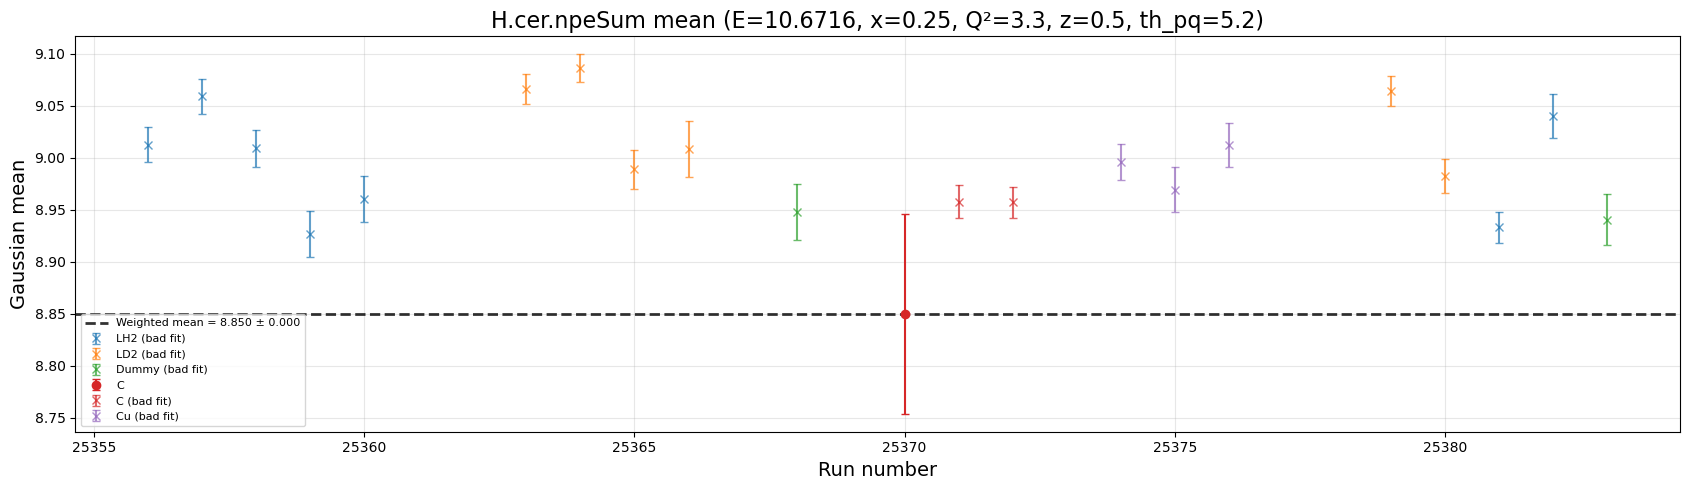

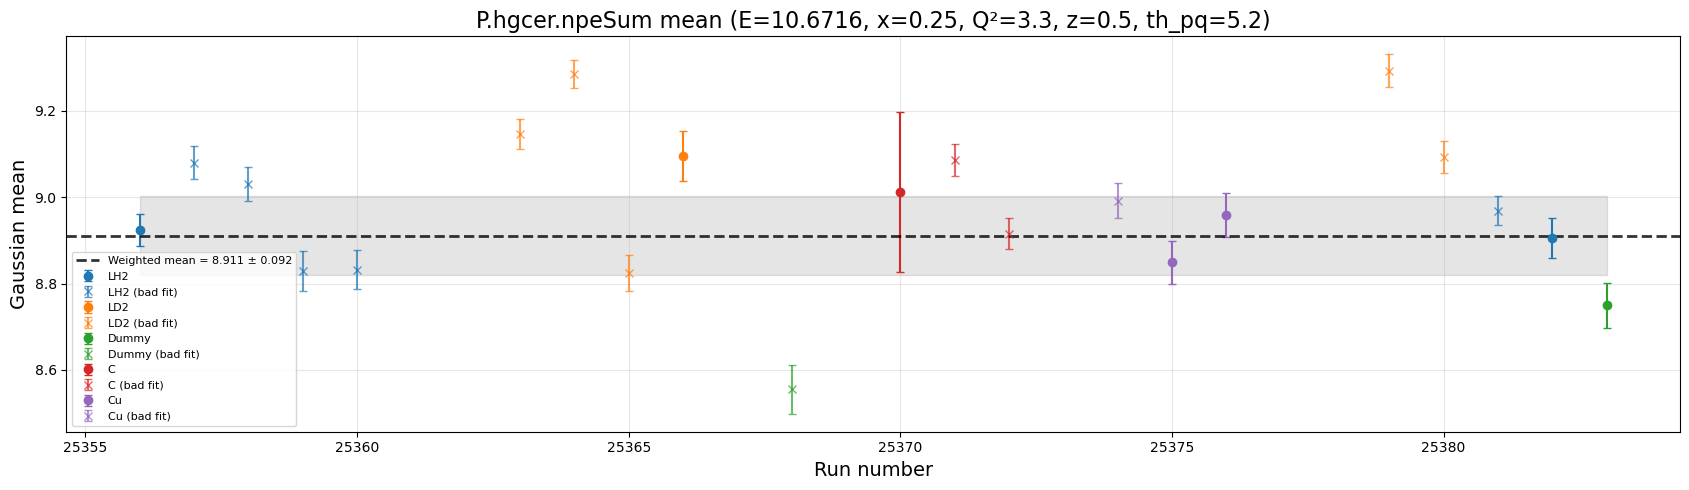

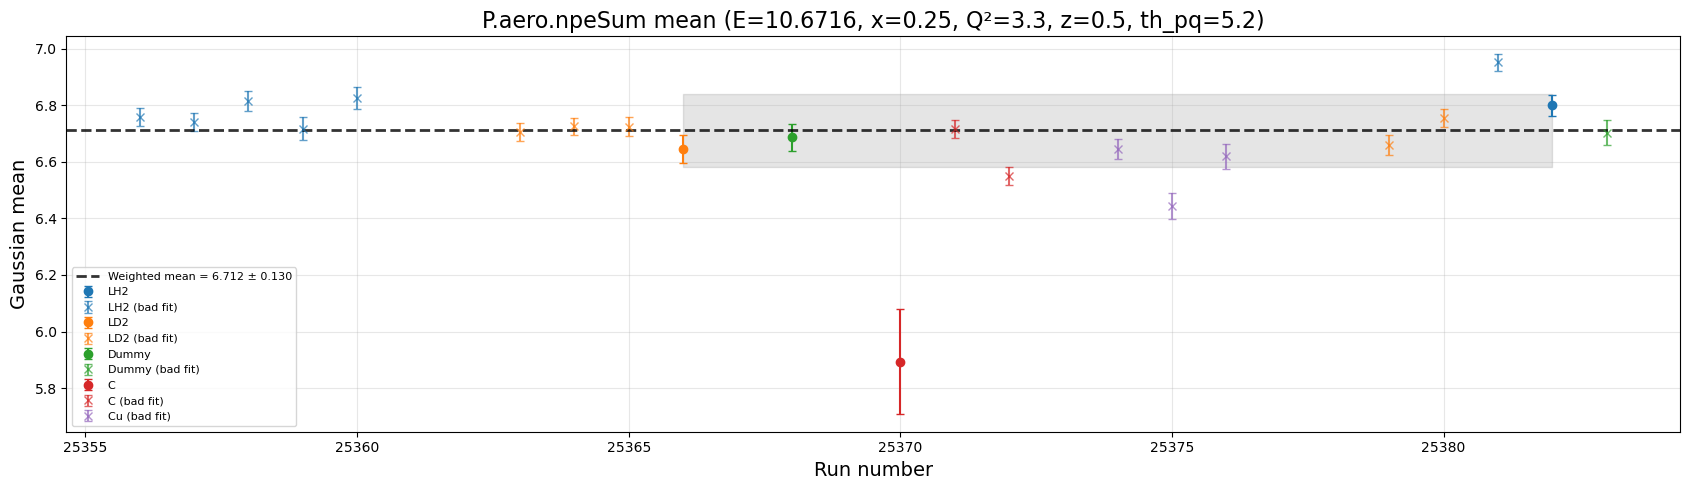

In [27]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 5.2
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

H.cer: No valid GOOD runs for weighted mean.
P.hgcer Weighted Mean = 8.300 ± 0.108
P.aero Weighted Mean = 6.666 ± 0.146


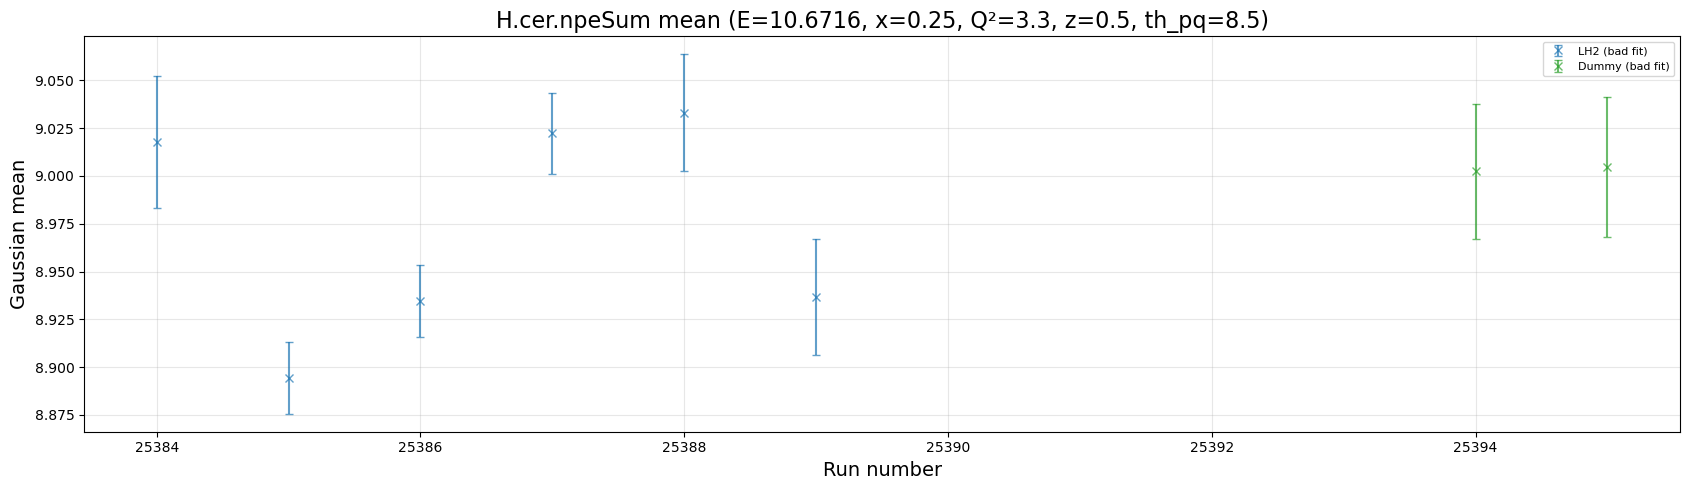

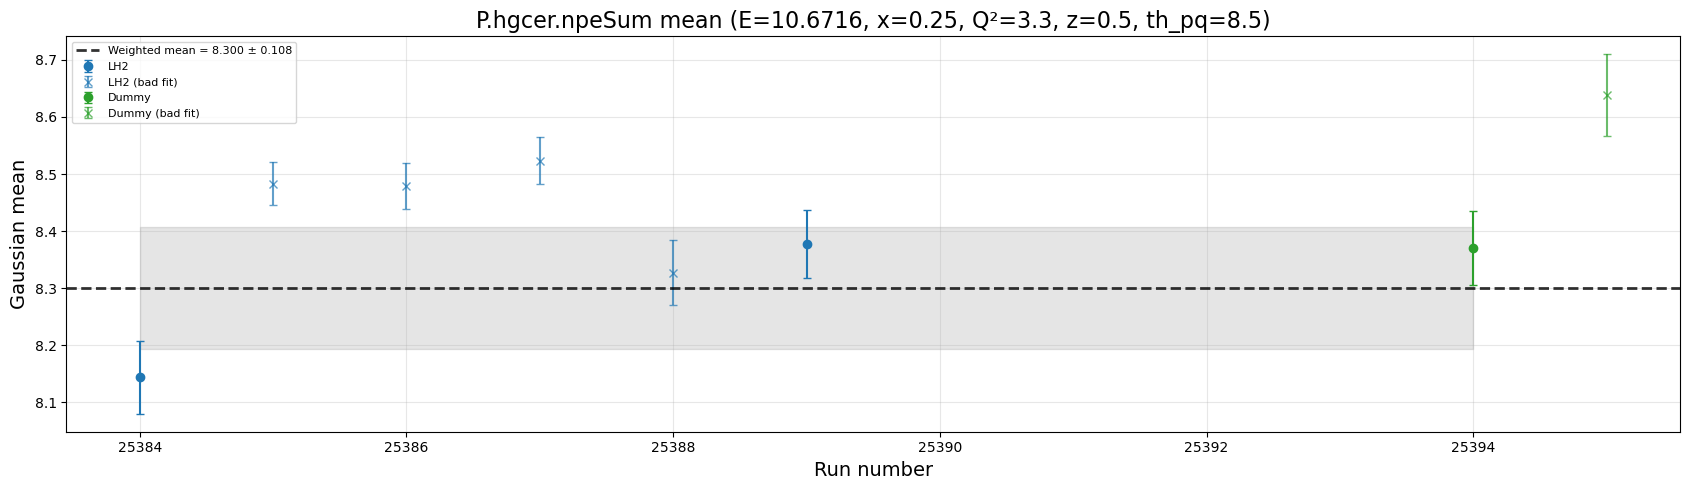

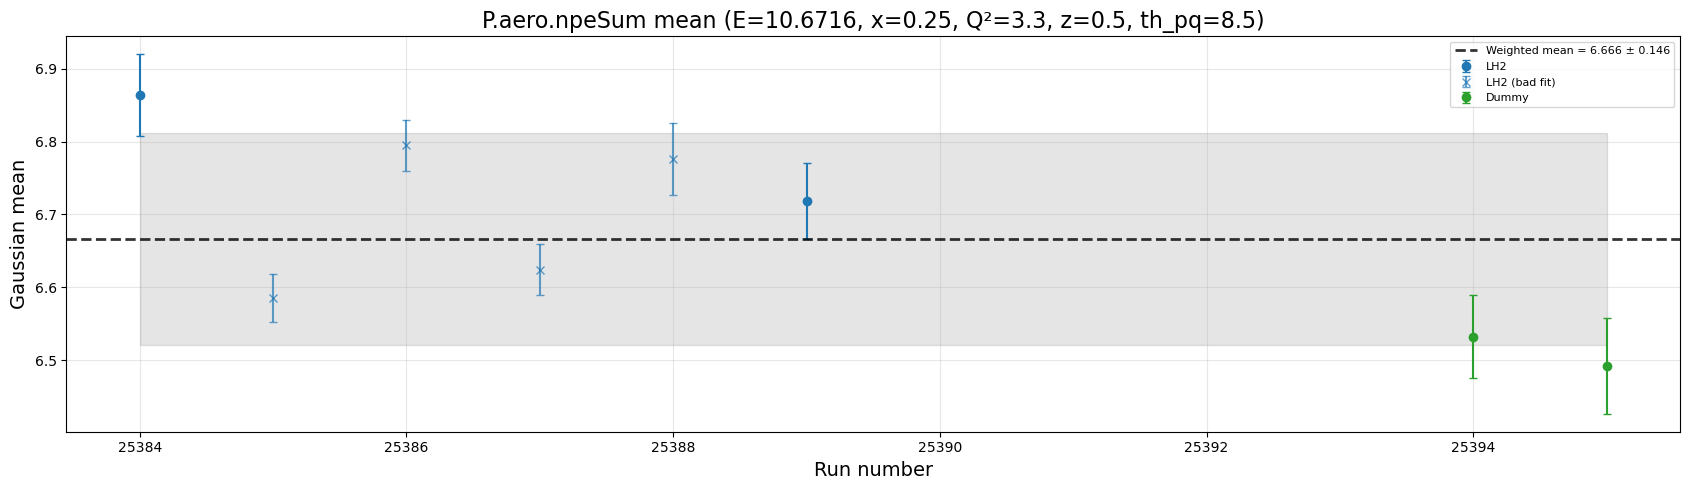

In [28]:
ebeam = 10.6716
x = 0.25
Q2 = 3.3
z = 0.5
thpq = 8.5
run_type = "PI+SIDIS"

mask = (
    (bigtable["run_type"] == run_type)
    & (bigtable["ebeam"] == ebeam)
    & (bigtable["hms_p"] < 0)
    & (bigtable["x"] == x)
    & (bigtable["Q2"] == Q2)
    & (bigtable["z"] == z)
    & (bigtable["thpq"] == thpq)
)
filtered_bigtable = bigtable[mask]

for det_name, df in fit_data.items():

    merged = pd.merge(
        filtered_bigtable, df, on="run", how="inner", suffixes=("", "_fit")
    )

    # basic sanity cut
    subset = merged[(merged["mean"] > 0) & (merged["std_dev"] / merged["mean"] < 10)].copy()
    if subset.empty:
        print(f"No data for {det_name} at this setting.")
        continue

    def classify_fit(row):
        chi2ndf = row.get("chi2_ndf", np.inf)
        if 0.3 < chi2ndf < 3.0:     # recommended robust range
            return "good"
        else:
            return "bad"

    subset["fit_quality"] = subset.apply(classify_fit, axis=1)

    plt.figure(figsize=(17, 5))

    for target, color in target_colors.items():
        tsub = subset[subset["target"] == target]
        if tsub.empty:
            continue

        # Good fits
        good = tsub[tsub["fit_quality"] == "good"]
        if not good.empty:
            plt.errorbar(
                good["run"],
                good["mean"],
                yerr=good["mean_err"],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{target}"
            )

        # Bad fits
        bad = tsub[tsub["fit_quality"] == "bad"]
        if not bad.empty:
            plt.errorbar(
                bad["run"],
                bad["mean"],
                yerr=bad["mean_err"],
                fmt="x",
                capsize=3,
                color=color,
                alpha=0.7,
                label=f"{target} (bad fit)"
            )

    valid = subset[subset["fit_quality"] == "good"]
    valid = valid[valid["mean_err"] > 0]

    if not valid.empty:
        weights = 1 / valid["mean_err"] ** 2
        weighted_mean = np.sum(valid["mean"] * weights) / np.sum(weights)
        weighted_std = np.sqrt(np.sum(weights * (valid["mean"] - weighted_mean) ** 2) / np.sum(weights))

        plt.axhline(
            weighted_mean,
            color="black",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Weighted mean = {weighted_mean:.3f} ± {weighted_std:.3f}"
        )
        plt.fill_between(
            [valid["run"].min(), valid["run"].max()],
            weighted_mean - weighted_std,
            weighted_mean + weighted_std,
            color="black",
            alpha=0.1
        )

        print(f"{det_name} Weighted Mean = {weighted_mean:.3f} ± {weighted_std:.3f}")
    else:
        print(f"{det_name}: No valid GOOD runs for weighted mean.")


    plt.title(f"{det_name}.npeSum mean (E={ebeam}, x={x}, Q²={Q2}, z={z}, th_pq={thpq})", fontsize=16)
    plt.xlabel("Run number", fontsize=14)
    plt.ylabel("Gaussian mean", fontsize=14)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()